## Roughness scaling: analysis

_Loads the pre-computed slimmed summary produced by `roughness_scale-load-compute`. All heavy simulation arrays (hc, vc, veg …) have been dropped._

TODO See if we do better with smaller roughness contrast. larger range of storm parameters.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/blob_code")


In [10]:
# ── Figure registry helper ─────────────────────────────────────────────────────
import os as _os, re as _re
from datetime import datetime as _datetime

def _fig_dirs():
    """Derive figure paths from the global `out_dir` (set in the data-load cell).
    Returns (fig_dir, scratch_dir, registry_path).
    """
    batch = _os.path.basename(out_dir.rstrip("/"))
    fig_dir      = _os.path.join("..", "figures", batch)
    scratch_dir  = _os.path.join("..", "figures", batch, "scratch")
    registry     = _os.path.join(fig_dir, "figure_registry.txt")
    _os.makedirs(fig_dir,     exist_ok=True)
    _os.makedirs(scratch_dir, exist_ok=True)
    return fig_dir, scratch_dir, registry


def _sort_key(fig_id: str):
    """Sort key: main figures (fig1, fig2, …) first by number, then SI figures."""
    lo = fig_id.lower()
    is_si = lo.startswith("si") or lo.startswith("figsi") or lo.startswith("fig_si")
    # extract the leading number from the id  (fig4 → 4, SI3 → 3)
    m = _re.search(r'(\d+)', fig_id)
    num = int(m.group(1)) if m else 999
    return (1 if is_si else 0, num, fig_id)


# Source notebook (auto-detected)
_NOTEBOOK_NAME = 'roughness_scale-analysis.ipynb'

def _rewrite_registry(entries: dict, registry_path: str):
    """Rewrite figure_registry.txt with entries sorted fig1→figN, then SI.

    `entries` maps fig_id → dict(filename, updated, description, concise,
                                  notebook, save_dir).
    Also writes figure_registry_concise.txt alongside the main file.
    """
    divider = "─" * 72
    sorted_ids = sorted(entries, key=_sort_key)
    fig_dir, _, _ = _fig_dirs()

    # ── full registry ──────────────────────────────────────────────────────
    lines = []
    lines.append(f"Figure registry  •  created {_datetime.now().strftime('%Y-%m-%d %H:%M')}")
    lines.append(f"Source notebook  :  notebooks/{_NOTEBOOK_NAME}")
    lines.append(f"Figures saved in :  {_os.path.abspath(fig_dir)}")
    lines.append(divider)
    lines.append("")
    for fid in sorted_ids:
        e = entries[fid]
        lines.append(f"### {fid} ###")
        lines.append(f"File     : {e['filename']}")
        lines.append(f"Updated  : {e['updated']}")
        lines.append(f"Notebook : notebooks/{e.get('notebook', _NOTEBOOK_NAME)}")
        lines.append(f"Saved in : {e.get('save_dir', fig_dir)}")
        lines.append(divider)
        lines.append(e['description'].strip())
        lines.append(f"### end {fid} ###")
        lines.append("")
    with open(registry_path, "w") as f:
        f.write("\n".join(lines))

    # ── concise registry ───────────────────────────────────────────────────
    concise_path = registry_path.replace("figure_registry.txt",
                                         "figure_registry_concise.txt")
    clines = []
    clines.append(f"Figure Registry (concise)  •  {_datetime.now().strftime('%Y-%m-%d %H:%M')}")
    clines.append(f"Source: notebooks/{_NOTEBOOK_NAME}  |  Figures: {_os.path.abspath(fig_dir)}")
    clines.append("=" * 72)
    clines.append("")
    for fid in sorted_ids:
        e = entries[fid]
        tag = fid.upper().replace("FIG", "Fig ")
        short = e.get('concise', e['description'].split('\n')[0])
        clines.append(f"{tag} — {e['filename']}")
        clines.append(f"  {short}")
        clines.append("")
    with open(concise_path, "w") as f:
        f.write("\n".join(clines))


def _parse_registry(registry_path: str) -> dict:
    """Read existing registry entries. Returns dict of fig_id → entry dict."""
    entries = {}
    if not _os.path.exists(registry_path):
        return entries
    with open(registry_path) as f:
        text = f.read()
    for m in _re.finditer(
        r"^### (\S+) ###\n"
        r"File     : (.+)\n"
        r"Updated  : (.+)\n"
        r"Notebook : (.+)\n"
        r"Saved in : (.+)\n"
        r"─+\n"
        r"(.*?)"
        r"^### end \1 ###",
        text, _re.DOTALL | _re.MULTILINE,
    ):
        fid = m.group(1)
        entries[fid] = dict(
            filename=m.group(2).strip(),
            updated=m.group(3).strip(),
            notebook=m.group(4).strip().replace('notebooks/', ''),
            save_dir=m.group(5).strip(),
            description=m.group(6).strip(),
            concise="",
        )
    # Fallback: also try the old 2-field header format so existing registries parse
    if not entries:
        for m in _re.finditer(
            r"^### (\S+) ###\n"
            r"File    : (.+)\n"
            r"Updated : (.+)\n"
            r"─+\n"
            r"(.*?)"
            r"^### end \1 ###",
            text, _re.DOTALL | _re.MULTILINE,
        ):
            fid = m.group(1)
            entries[fid] = dict(
                filename=m.group(2).strip(),
                updated=m.group(3).strip(),
                description=m.group(4).strip(),
                concise="",
            )
    return entries


def update_figure_registry(fig_id: str, filename: str,
                           description: str, concise: str = ""):
    """Write or replace the section for `fig_id` in both registries.

    Parameters
    ----------
    fig_id : str
        Identifier like 'fig1', 'fig4', 'SI1', etc.
    filename : str
        Name of the saved PNG/PDF file.
    description : str
        Full multi-line description (for the main registry).
    concise : str, optional
        One-line human-readable summary (for the concise registry).
        Falls back to the first line of `description`.

    Entries are automatically re-sorted: fig1 → figN, then SI figures.
    Scratch figures should NOT be registered.
    """
    _, _, registry_path = _fig_dirs()
    now = _datetime.now().strftime("%Y-%m-%d %H:%M")
    entries = _parse_registry(registry_path)
    entries[fig_id] = dict(
        filename=filename,
        updated=now,
        description=description.strip(),
        concise=concise.strip() if concise else description.strip().split('\n')[0],
    )
    _rewrite_registry(entries, registry_path)
    print(f"Registry updated → {registry_path}  [{fig_id}]")

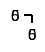

In [11]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *


In [12]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [13]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))


Loaded summary_slim: shape = (1440, 330)
Columns: ['$p t_r$', '<Sf>', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_T0', '<Sf>_T0_hyb', '<Sf>_T1', '<Sf>_T2', '<Sf>_Ubar2_np2', '<Sf>_cross_nU', '<Sf>_direct', '<Sf>_direct_minus_exp2', '<Sf>_direct_wet', '<Sf>_exp2', '<Sf>_hyb_Up2', '<Sf>_hyb_base', '<Sf>_hyb_cross', '<Sf>_hyb_np2', '<Sf>_hyb_num_sum', '<Sf>_hybrid_quad', '<Sf>_nbar2_Ubar2', '<Sf>_nbar2_Up2', '<Sf>_nd_T0', '<Sf>_nd_T1', '<Sf>_nd_T2', '<Sf>_nd_sumK2', '<Sf>_series2', '<U dU/dx>', '<U>', '<U>/<h>', '<U><dU/dx>', '<U>^2/<Up^2>', '<U>_CF', '<Ua>', '<Uh>', '<Up dUp/dx>', '<Up hp>', '<Up2>', '<dU/dx>', '<dh/dx>', '<dhp/dx>', '<eta ups>', '<eta2>', '<h>', '<h>_CF', '<h^2/3>', '<ha>', '<hp2>', '<n2>', '<n2><h>^-4/3', '<n>', '<n>2', '<n><U>', '<nU>', '<na>', '<np Up>', '<np hp>', '<np2>', '<q>_direct', '<q>_hform', '<q>_uform', '<r eta>', '<r ups>', '<r2>', '<ups2>', 'B_bc_NF', 'B_bc_init', 'Bbound', 'C', 'CPU_time', 'Cd', 'Cd_misc', 'Choice_dt_specific_points', 'Choice_points', 'F

In [14]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


##  Spatial pattern 
_Scatter plots and summaries of how vegetation pattern (σ, fV, aniso) drives the spatial heterogeneity and the effect ratio. Run **after** slimming the dataframe._

In [15]:
_band_mask = summary['veg_type'].str.contains('band')
summary.loc[_band_mask, 'aniso'] = 1
summary.loc[_band_mask, 'stripe_count'] = summary.loc[_band_mask, 'l'] / summary.loc[_band_mask, 'sigma']
summary['effect_ratio_exp3'] = summary['n_exp3'] / summary['<n>']

_blob_mask = summary['veg_type'] == 'blob'
summary.loc[_blob_mask, 'stripe_count'] = summary.loc[_blob_mask, 'aniso']


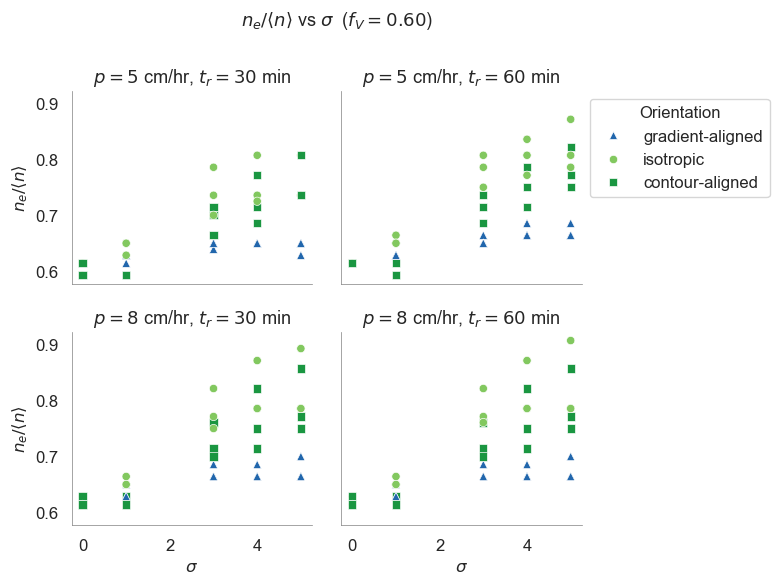

In [16]:
fV = 0.6          # centre of fV window
fV_half = 0.05    # half-width → selects fV in [fV - fV_half, fV + fV_half]
hue_var = None    # None = auto: 'aniso' if only blobs, else 'veg_type'

# ── filter: fV window ─────────────────────────────────────────────────────────
_df = summary[(summary['fV'] >= fV - fV_half) & (summary['fV'] <= fV + fV_half)].copy()

if _df.empty:
    print(f"No data in fV window [{fV - fV_half}, {fV + fV_half}]. "
          f"Available fV: {sorted(summary['fV'].unique())}")
else:
    _is_band = _df['veg_type'].str.contains('band').any()

    # ── auto-select hue variable ───────────────────────────────────────────────
    _veg_types = _df['veg_type'].unique()
    if hue_var is None:
        hue_var = 'aniso' if set(_veg_types) == {'blob'} else 'veg_type'

    # ── build palette ─────────────────────────────────────────────────────────
    import matplotlib.cm as _cm
    import matplotlib.colors as _mcolors

    _plot_hue = hue_var   # column actually passed to seaborn (may differ for aniso)

    if hue_var == 'veg_type':
        _palette = {k: v for k, v in VEG_COLORS.items() if k in _veg_types}
        _fallback = iter(_cm.tab10.colors)
        for _vt in _veg_types:
            if _vt not in _palette:
                _palette[_vt] = next(_fallback)
        _hue_label = 'veg type'
    elif hue_var == 'aniso':
        # map numeric aniso → descriptive label
        _aniso_name = {v: ('gradient-aligned' if v < 0 else
                           'isotropic'        if v == 1 else
                           'contour-aligned') for v in sorted(_df['aniso'].unique())}
        _df['_aniso_label'] = _df['aniso'].map(_aniso_name)
        _plot_hue = '_aniso_label'

        # order: gradient-aligned first, then isotropic, then contour-aligned
        _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                        if l in _df['_aniso_label'].unique()]

        # blue (gradient-aligned) → green (contour-aligned) colormap
        _aniso_vals_sorted = sorted(_aniso_name.keys())
        _bg_cmap = _mcolors.LinearSegmentedColormap.from_list(
            'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641']
        )
        _norm = _mcolors.Normalize(vmin=min(_aniso_vals_sorted), vmax=max(_aniso_vals_sorted))
        _palette = {_aniso_name[v]: _bg_cmap(_norm(v)) for v in _aniso_vals_sorted}
        _hue_label = 'Orientation'
    else:
        _palette = 'viridis'
        _label_order = None
        _hue_label = hue_var

    # ── build marker dict (shape varies with hue) ─────────────────────────────
    _marker_pool = ['^', 'o', 's', 'D', 'P', 'X', 'v', '<', '>']
    _hue_vals = list(_palette.keys()) if isinstance(_palette, dict) else sorted(_df[_plot_hue].unique())
    _markers = {v: _marker_pool[i % len(_marker_pool)] for i, v in enumerate(_hue_vals)}

    p_vals  = sorted(_df['p'].unique())
    tr_vals = sorted(_df['tr'].unique())
    ncols = len(tr_vals)
    nrows = len(p_vals)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    def _dedup_legend(handles, labels):
        """Return handles/labels with duplicate labels removed (keep first)."""
        seen, out_h, out_l = set(), [], []
        for h, l in zip(handles, labels):
            if l not in seen:
                seen.add(l); out_h.append(h); out_l.append(l)
        return out_h, out_l

    for ri, p in enumerate(p_vals):
        for ci, tr in enumerate(tr_vals):
            ax = axes[ri, ci]
            sub = _df[(_df['p'] == p) & (_df['tr'] == tr)]
            if sub.empty:
                ax.set_visible(False)
                continue
            _show_legend = (ri == 0 and ci == ncols - 1)
            sns.scatterplot(data=sub, x='sigma', y='effect_ratio', hue=_plot_hue,
                            style=_plot_hue, markers=_markers,
                            palette=_palette, ax=ax, legend=_show_legend)
            ax.set_title(f"$p={p}$ cm/hr, $t_r={tr}$ min", fontsize=FS_TITLE)
            _xl = ("band count" if _is_band else r"$\sigma$") if ri == nrows - 1 else ""
            ax.set_xlabel(_xl, fontsize=FS_LABEL)
            ax.set_ylabel(r"$n_e/\langle n \rangle$" if ci == 0 else "", fontsize=FS_LABEL)
            ax.tick_params(labelsize=FS_TICK)
            if _show_legend:
                leg = ax.get_legend()
                if leg:
                    leg.remove()
                    hs, ls = ax.get_legend_handles_labels()
                    if hue_var == 'veg_type':
                        ls = [VEG_LABELS.get(l, l) for l in ls]
                    hs, ls = _dedup_legend(hs, ls)
                    ax.legend(hs, ls, loc='upper left', bbox_to_anchor=(1, 1),
                              title=_hue_label, frameon=True, fontsize=FS_LEG,
                              title_fontsize=FS_LEG, bbox_transform=ax.transAxes)

    fig.suptitle(
        fr"$n_e/\langle n \rangle$ vs $\sigma$  ($f_V = {fV:.2f}$)",
        fontsize=FS_TITLE,
    )
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)


In [17]:
summary.aniso.unique()


array([-2, 1, 2], dtype=object)

In [18]:
summary.groupby(['fV', 'veg_type'])[['effect_ratio']].median()


,,effect_ratio
fV,veg_type,
0.05,blob,0.904348
0.10,blob,0.830769
0.20,blob,0.737500
0.40,blob,0.652273
0.60,blob,0.664286
0.80,blob,0.764706
0.90,blob,0.843243
0.95,blob,0.914286


In [19]:
summary.veg_type.value_counts()


veg_type
blob    1440
Name: count, dtype: int64

## Correction factor

Two methods estimate spatially-averaged velocity $\langle U \rangle$ and depth $\langle h \rangle$ from the roughness field alone (no simulation output), letting us predict the effective Manning's $n_e = \langle h \rangle^{2/3} S_0^{1/2} / \langle U \rangle$.

**Correction factor** (`<U>_CF`, `<h>_CF`) — applies the point-scale kinematic-wave solution at every cell using the *full* slope length $l$ as the upslope distance, then spatially averages. This isolates the cross-slope (lateral) roughness heterogeneity while ignoring each cell's actual position along the slope.

$$\langle U \rangle_\text{CF} = \tfrac{5}{7} \left\langle \left[ \tfrac{1}{n}(q_0 l)^{2/3} S_0^{1/2} \right]^{3/5} \right\rangle \qquad \langle h \rangle_\text{CF} = \tfrac{5}{8} \left\langle \left( q_0\, l\, n\, S_0^{-1/2} \right)^{3/5} \right\rangle$$

**Slope-integrated** (`<Ua>`, `<ha>`) — integrates the kinematic-wave formula along each slope column using the *correct* upslope distance $x$, accounting for flow accumulation, then row-averages and normalises by $l$.

$$\langle U_a \rangle = \frac{1}{l} \left\langle \int_0^l \left[ \frac{(q_0 x)^{2/3}}{n(x)} S_0^{1/2} \right]^{3/5} dx \right\rangle \qquad \langle h_a \rangle = \frac{1}{l} \left\langle \int_0^l \left( q_0\, x\; n(x)\, S_0^{-1/2} \right)^{3/5} dx \right\rangle$$

The ratio $n_e / \langle n \rangle$ (columns `ne_CF` / `ne_a`) is the main diagnostic; values $< 1$ indicate that spatial organisation *reduces* bulk resistance below the arithmetic mean.

Registry updated → ../figures/runaround_smooth/figure_registry.txt  [SI1]


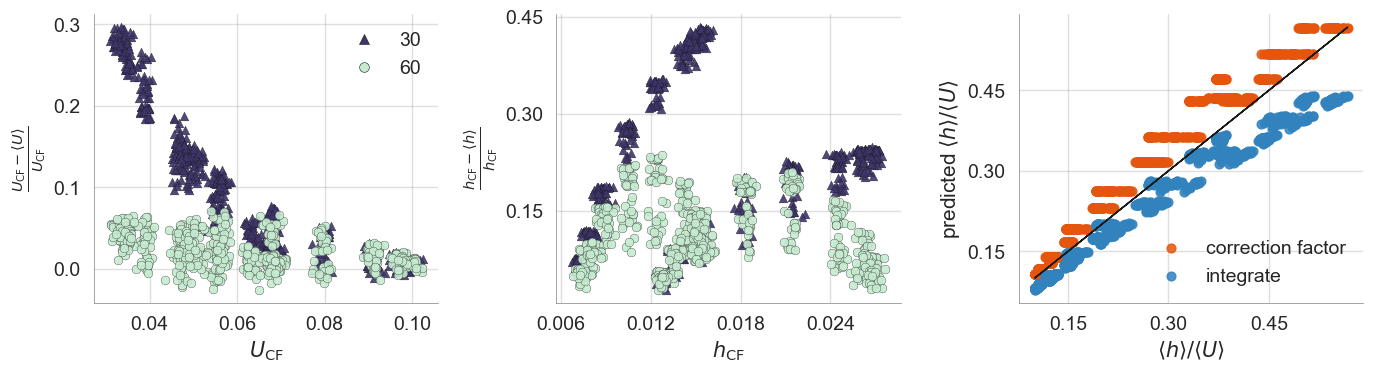

In [66]:
# fixed colors for the right-panel method comparison (independent of color_by)
COLOR_CF  = '#e6550d'   # orange  – correction factor
COLOR_INT = '#3182bd'   # blue    – integrate

def plot_CF_errors(df, color_by=None, tr_max=60, figsize=(14, 4),
                   color_cf=COLOR_CF, color_int=COLOR_INT,
                   fs_label=FS_LABEL + 3, fs_tick=FS_TICK + 2, fs_leg=FS_LEG + 2,
                   jitter=0.015):
    """
    Three-panel correction-factor diagnostic plot.

    Panels 1 & 2: relative U and h errors vs CF values, colored by `color_by`.
    Panel  3:     h/U identity comparison; correction factor in `color_cf`,
                  integrate in `color_int`.

    Parameters
    ----------
    df        : DataFrame containing the run summary (e.g. `summary`)
    color_by  : column to use for coloring panels 1 & 2
    tr_max    : upper limit on `tr` for subsetting (inclusive)
    figsize   : figure size tuple
    color_cf  : color for 'correction factor' points in panel 3
    color_int : color for 'integrate' points in panel 3
    jitter    : std-dev of Gaussian x-jitter (as fraction of x range)
    """
    from matplotlib.lines import Line2D
    from matplotlib.ticker import MaxNLocator

    _marker_pool = ['^', 'o', 's', 'D', 'P', 'X', 'v', '<', '>']

    sub = df.query("tr <= @tr_max").copy()

    # ── auto-detect color_by (same logic as scatter cell) ────────────────────
    if color_by is None:
        _vt = sub['veg_type'].unique()
        color_by = 'aniso' if set(_vt) == {'blob'} else 'veg_type'

    # ── build color + marker scheme for panels 1 & 2 ─────────────────────────
    def _build_color_scheme(data, col):
        if col not in data.columns:
            raise ValueError(f"Column '{col}' not found. Available: {list(data.columns)}")
        if col == 'veg_type':
            cats_ord  = [k for k in VEG_COLORS if k in data[col].unique()]
            cats_ord += [v for v in data[col].dropna().unique() if v not in cats_ord]
            cat_labels = [VEG_LABELS.get(c, c) for c in cats_ord]
            color_list = [VEG_COLORS.get(c, '#888888') for c in cats_ord]
            codes = np.array([cats_ord.index(v) if v in cats_ord else -1
                              for v in data[col]], dtype=int)
            title = 'vegetation'
        elif col == 'aniso':
            _aniso_name = {v: ('gradient-aligned' if v < 0 else
                               'isotropic'        if v == 1 else
                               'contour-aligned')
                           for v in sorted(data[col].dropna().unique())}
            _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                            if l in _aniso_name.values()]
            _explicit_colors = {
                'gradient-aligned': '#2166ac',
                'isotropic':        '#a6d96a',
                'contour-aligned':  '#1a9641',
            }
            cat_labels = _label_order
            color_list = [_explicit_colors[l] for l in cat_labels]
            _label_to_idx = {l: i for i, l in enumerate(cat_labels)}
            codes = np.array([_label_to_idx.get(_aniso_name.get(v, ''), -1)
                              for v in data[col]], dtype=int)
            title = 'orientation'
        else:
            raw = pd.to_numeric(data[col], errors='coerce')
            if raw.notna().mean() > 0.9:
                uniq = np.array(sorted(raw.dropna().unique()))
                codes = np.array([np.searchsorted(uniq, v) if not np.isnan(v) else -1
                                  for v in raw], dtype=int)
                cat_labels = [f"{v:g}" for v in uniq]
                cmap_fn = plt.get_cmap('mako')
                color_list = [cmap_fn(t) for t in np.linspace(0.25, 0.95, max(len(uniq), 2))]
            else:
                cats_ord = sorted(data[col].dropna().unique())
                codes = np.array([cats_ord.index(v) if v in cats_ord else -1
                                  for v in data[col]], dtype=int)
                cat_labels = [str(c) for c in cats_ord]
                cmap_fn = plt.get_cmap('tab10')
                color_list = [cmap_fn(i / max(len(cats_ord)-1, 1)) for i in range(len(cats_ord))]
            title = col
        marker_list = [_marker_pool[i % len(_marker_pool)] for i in range(len(cat_labels))]
        legend_handles = [
            Line2D([0], [0], marker=marker_list[i], color='none',
                   markerfacecolor=color_list[i],
                   markeredgecolor='k', markeredgewidth=0.4, markersize=7,
                   label=cat_labels[i])
            for i in range(len(cat_labels))
        ]
        return codes, cat_labels, color_list, marker_list, legend_handles, title

    codes, cat_labels, colors, markers, leg_handles, leg_title = _build_color_scheme(sub, color_by)

    rng = np.random.default_rng(42)

    def _scatter(ax, x, y):
        x, y = np.asarray(x, float), np.asarray(y, float)
        xrange = np.nanmax(x) - np.nanmin(x)
        mask = np.isfinite(x) & np.isfinite(y) & (codes >= 0)
        for i in range(len(cat_labels)):
            sel = mask & (codes == i)
            if np.any(sel):
                xj = x[sel] + rng.normal(0, jitter * xrange, sel.sum())
                ax.scatter(xj, y[sel], s=40, alpha=0.9,
                           marker=markers[i],
                           color=colors[i], edgecolors='k', linewidths=0.25)

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Panel 1 – U error vs U_CF
    _scatter(axes[0],
             sub['<U>_CF'],
             (sub['<U>_CF'] - sub['<U>']) / sub['<U>_CF'])
    axes[0].set_xlabel(r"$U_{\rm CF}$", fontsize=fs_label)
    axes[0].set_ylabel(r"$\frac{U_{\rm CF}-\langle U\rangle}{U_{\rm CF}}$", fontsize=fs_label)
    axes[0].tick_params(labelsize=fs_tick)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(handles=leg_handles, frameon=False, loc='best',
                   fontsize=fs_leg)

    # Panel 2 – h error vs h_CF
    _scatter(axes[1],
             sub['<h>_CF'],
             (sub['<h>_CF'] - sub['<h>']) / sub['<h>_CF'])
    axes[1].set_xlabel(r"$h_{\rm CF}$", fontsize=fs_label)
    axes[1].set_ylabel(r"$\frac{h_{\rm CF}-\langle h\rangle}{h_{\rm CF}}$", fontsize=fs_label)
    axes[1].tick_params(labelsize=fs_tick)
    axes[1].grid(True, alpha=0.25)

    # Panel 3 – h/U identity (own fixed colors, independent of color_by)
    hU = sub['<h>'] / sub['<U>']
    axes[2].plot(hU, hU, lw=1, color='k')
    axes[2].scatter(hU, sub['<h>_CF'] / sub['<U>_CF'],
                    c=color_cf,  label='correction factor', s=40, alpha=0.85)
    axes[2].scatter(hU, sub['<ha>']  / sub['<Ua>'],
                    c=color_int, label='integrate',          s=40, alpha=0.85)
    axes[2].legend(frameon=False, loc='best', fontsize=fs_leg)
    axes[2].set_xlabel(r"$\langle h\rangle/\langle U\rangle$", fontsize=fs_label)
    axes[2].set_ylabel(r"predicted $\langle h\rangle/\langle U\rangle$", fontsize=fs_label)
    axes[2].tick_params(labelsize=fs_tick)
    axes[2].grid(True, alpha=0.25)

    for ax in axes:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    plt.tight_layout()
    return fig


# ── call ──────────────────────────────────────────────────────────────────────
COLOR_BY = 'tr'   # None = auto ('aniso' if only blobs, else 'veg_type'); or set explicitly: 'sigma', 'fV', 'tr', ...
fig = plot_CF_errors(summary, color_by=COLOR_BY)


# ── save as SI figure ─────────────────────────────────────────────────────────

_fig_dir, _, _ = _fig_dirs()

_si1_name = 'SI1_CF_errors_3panel.png'

fig.savefig(_os.path.join(_fig_dir, _si1_name), dpi=300, bbox_inches='tight')

update_figure_registry(
    'SI1', _si1_name,
    description=(
        'Three-panel correction-factor diagnostic.\n'
        f'Panels 1 & 2: relative U and h errors vs CF values, coloured by {COLOR_BY}.\n'
        'Panel 3: h/U identity comparison (correction factor vs integrate).\n'
    ),
    concise=(
        f'Three-panel CF diagnostic coloured by {COLOR_BY}: '
        'relative U and h errors vs CF values, plus h/U identity comparison.'
    ),
)

## Equivalent roughness predictions

All four methods use only the **roughness field** (no simulation output).  

The CF per-cell depth and velocity apply the point-scale kinematic-wave solution at every cell using the full slope length $l$, then spatially average:

$$\langle U \rangle_\text{CF} = \frac{5}{7} \left\langle \left[ \frac{1}{n} \left( q_0\, l \right)^{2/3} S_0^{1/2} \right]^{3/5} \right\rangle, \qquad \langle h \rangle_\text{CF} = \frac{5}{8} \left\langle \left( q_0\, l\, n\, S_0^{-1/2} \right)^{3/5} \right\rangle$$

where $q_0 = (p - K_s)/3.6\times10^5\,\mathrm{m\,s^{-1}}$.  
<!-- Equivalent roughness is back-calculated as $n_e = \langle h \rangle^{2/3} S_0^{1/2} / \langle U \rangle$. -->


| Method | Formula |
|--------|---------|
| **Leading term (CF input)** | $n_e/\langle n\rangle \approx S_0 \langle h\rangle^{4/3} / (\langle n\rangle^2 \langle U\rangle^2)$ |
| **2nd-order $T_0$ (CF input)** | $n_e/\langle n\rangle \approx 1 + \langle r_n^2\rangle + \langle r_U^2\rangle + 4\langle r_n r_U\rangle$, where $r_n = n'/\bar{n}$, $r_U = U_i'/\bar{U}$ |
| **Lotter (CF input)** | $n_e/\langle n\rangle = \langle h^{5/3}\rangle / (\langle n\rangle \langle h^{5/3}/n\rangle) \equiv 1$ |
| **Felkel** | $n_e/\langle n\rangle = 1 \langle n\rangle^{-1} (\langle 1/n\rangle)^{-1}$  |

**Why Lotter = 1 for CF inputs.** The CF depth is $h_i = (q_0 l n_i / S_0^{1/2})^{3/5}$, so raising to the $5/3$ power gives

$$h_i^{5/3} = \frac{q_0\, l}{S_0^{1/2}}\, n_i \equiv C\, n_i$$

where $C = q_0 l / S_0^{1/2}$ is the same for every cell. Therefore $\langle h^{5/3}\rangle = C\langle n\rangle$ and $h_i^{5/3}/n_i = C$ (a cell-independent constant), so $\langle h^{5/3}/n\rangle = C$. Substituting:

$$\frac{n_e}{\langle n\rangle} = \frac{C\langle n\rangle}{\langle n\rangle \cdot C} = 1$$

The Lotter formula is uninformative for any set of inputs in which $h^{5/3} \propto n$ — which is what the CF approximation enforces.

Coloring by: sigma  (|r| with leading-term residual = 0.617)
Top correlates: [('sigma', -0.617), ('aniso', -0.232), ('fV', 0.12), ('p', -0.078)]
Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig5]


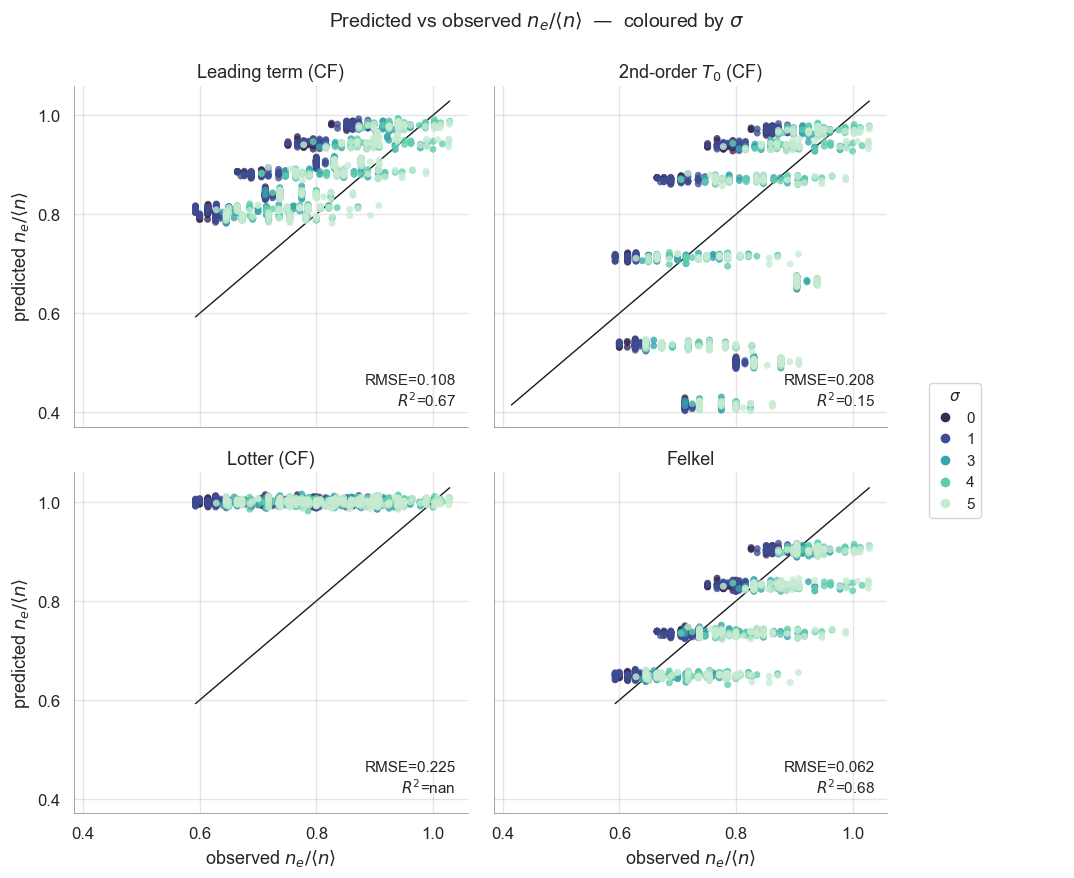

In [63]:
# ── Predicted vs observed effect ratio — CF-field methods + Felkel ─────────────
# All four methods use only the roughness field (no simulation output).
# Markers are coloured by the variable that explains the most variance in the
# Leading-term (CF) residuals (pred − obs).

# ── helper metrics ─────────────────────────────────────────────────────────────
def _rmse(pred, obs):
    m = np.isfinite(pred) & np.isfinite(obs)
    return float(np.sqrt(np.mean((pred[m] - obs[m])**2))) if m.sum() > 0 else np.nan

def _r2(pred, obs):
    m = np.isfinite(pred) & np.isfinite(obs)
    if m.sum() < 3:
        return np.nan
    return float(np.corrcoef(pred[m], obs[m])[0, 1]**2)

# ── observed column ─────────────────────────────────────────────────────────────
er_obs_col = 'effect_ratio'

# ── compute CF-based equivalent roughness predictions ──────────────────────────
summary['er_lead_CF'] = (
    summary['<h>_CF']**(2/3) * summary['So']**0.5
    / (summary['<U>_CF'] * summary['<n>'])
)
summary['er_T0_CF'] = (
    1
    + summary['<r2>']
    + (9/25) * summary['<r2>']
    + 4 * (-3/5) * summary['<r2>']
)
summary['er_Lotter_CF'] = 1.0
summary['er_Felkel_CF'] = summary['n_exp8'] / summary['<n>']

# ── define 4-panel method list ──────────────────────────────────────────────────
methods = [
    ('er_lead_CF',   'Leading term (CF)'),
    ('er_T0_CF',     r'2nd-order $T_0$ (CF)'),
    ('er_Lotter_CF', 'Lotter (CF)'),
    ('er_Felkel_CF', 'Felkel'),
]

# ── find variable that best explains Leading-term residuals ─────────────────────
_obs_arr   = summary[er_obs_col].to_numpy(float)
_lead_pred = summary['er_lead_CF'].to_numpy(float)
_m_lead    = np.isfinite(_obs_arr) & np.isfinite(_lead_pred)
_lead_resid = _lead_pred[_m_lead] - _obs_arr[_m_lead]

_sim_cols = ['fV', 'sigma', 'p', 'tr', 'l', 'aniso']
_candidates = []
for c in _sim_cols:
    if c not in summary.columns:
        continue
    try:
        _v  = pd.to_numeric(summary[c], errors='coerce').to_numpy(float)[_m_lead]
        _m2 = np.isfinite(_v) & np.isfinite(_lead_resid)
        if _m2.sum() < 20 or _v[_m2].std() < 1e-10:
            continue
        r = float(np.corrcoef(_v[_m2], _lead_resid[_m2])[0, 1])
        if np.isfinite(r):
            _candidates.append((c, r))
    except Exception:
        pass

_candidates.sort(key=lambda x: abs(x[1]), reverse=True)
COLOR_BY_VAR_4P   = _candidates[0][0] if _candidates else 'fV'
_pretty           = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
                     'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)'}
COLOR_BY_LABEL_4P = _pretty.get(COLOR_BY_VAR_4P, COLOR_BY_VAR_4P)
_cmap_name_4p     = VAR_CMAPS.get(COLOR_BY_VAR_4P, 'viridis')
_cmap_4p_base     = plt.get_cmap(_cmap_name_4p)
_cmap_4p          = mpl.colors.LinearSegmentedColormap.from_list(
    f'trunc_{_cmap_name_4p}', _cmap_4p_base(np.linspace(0.2, 0.95, 256)))

if _candidates:
    print(f"Coloring by: {COLOR_BY_VAR_4P}  (|r| with leading-term residual = {abs(_candidates[0][1]):.3f})")
    print("Top correlates:", [(c, round(r, 3)) for c, r in _candidates[:4]])
else:
    print(f"Coloring by: {COLOR_BY_VAR_4P}  (no valid correlates found; using default)")

# ── build discrete colour levels ────────────────────────────────────────────────
_color_vals_raw = pd.to_numeric(summary[COLOR_BY_VAR_4P], errors='coerce')
_unique_vals    = sorted(_color_vals_raw.dropna().unique())
MAX_LEVELS_4P   = 6
if len(_unique_vals) > MAX_LEVELS_4P:
    _binned      = pd.qcut(_color_vals_raw, q=MAX_LEVELS_4P, duplicates='drop')
    _bin_levels  = _binned.cat.categories.tolist()
    _color_vals  = _binned.cat.codes.astype(float)
    _color_vals[_binned.isna()] = np.nan
    _color_levels = list(range(len(_bin_levels)))
    _level_label  = lambda i: f'[{_bin_levels[i].left:.3g}, {_bin_levels[i].right:.3g}]'
else:
    _color_vals   = _color_vals_raw.to_numpy(float)
    _color_levels = _unique_vals
    _level_label  = lambda v: f'{v}'

_norm_4p    = mpl.colors.Normalize(vmin=min(_color_levels), vmax=max(_color_levels))
_palette_4p = {cv: _cmap_4p(_norm_4p(cv)) for cv in _color_levels}

# ── 2×2 plot ────────────────────────────────────────────────────────────────────
from matplotlib.ticker import MaxNLocator

fs_lab, fs_tck, fs_leg = 13, 12, 11
fig2, axes2 = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
axes2_flat  = axes2.ravel()

for idx, (ax, (pred_col, title)) in enumerate(zip(axes2_flat, methods)):
    obs  = summary[er_obs_col].to_numpy(float)
    pred = (summary[pred_col].to_numpy(float)
            if pred_col in summary.columns else np.full(len(summary), np.nan))

    finite = np.isfinite(obs) & np.isfinite(pred)
    if finite.sum() == 0:
        ax.set_title(f"{title}\n(no data)", fontsize=fs_lab)
        continue

    lo = min(np.nanmin(obs[finite]), np.nanmin(pred[finite]))
    hi = max(np.nanmax(obs[finite]), np.nanmax(pred[finite]))
    ax.plot([lo, hi], [lo, hi], 'k-', lw=1, zorder=0)

    _rng = np.random.default_rng(42)
    for cv in _color_levels:
        sel = finite & (np.abs(_color_vals - cv) < 1e-9)
        if sel.sum() == 0:
            continue
        _jitter = _rng.normal(0, 0.005, sel.sum())
        ax.scatter(obs[sel], pred[sel] + _jitter,
                   color=_palette_4p[cv], marker='o',
                   s=25, alpha=0.80, edgecolors='none', zorder=3)

    rmse = _rmse(pred[finite], obs[finite])
    r2v  = _r2(pred[finite], obs[finite])
    ax.set_title(title, fontsize=fs_lab)
    ax.text(0.97, 0.05, f'RMSE={rmse:.3f}\n$R^2$={r2v:.2f}',
            transform=ax.transAxes, fontsize=fs_tck - 1,
            ha='right', va='bottom', zorder=5)
    ax.tick_params(labelsize=fs_tck)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    if idx >= 2:
        ax.set_xlabel(r"observed $n_e/\langle n\rangle$", fontsize=fs_lab)
    if idx % 2 == 0:
        ax.set_ylabel(r"predicted $n_e/\langle n\rangle$", fontsize=fs_lab)

    # ── collect per-method metrics for dynamic registry text ─────────────────
    if not hasattr(fig2, '_method_metrics'):
        fig2._method_metrics = {}
    fig2._method_metrics[pred_col] = dict(title=title, rmse=rmse, r2=r2v)

fig2.suptitle(r"Predicted vs observed $n_e/\langle n\rangle$"
              f"  —  coloured by {COLOR_BY_LABEL_4P}", fontsize=fs_lab + 1)
fig2.tight_layout(rect=[0, 0, 0.84, 1])

# ── legend ───────────────────────────────────────────────────────────────────────
leg_ax = fig2.add_axes([0.85, 0.12, 0.13, 0.74])
leg_ax.set_axis_off()
from matplotlib.lines import Line2D
_leg_handles = [Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=_palette_4p[cv], markersize=8, label=_level_label(cv))
                for cv in _color_levels]
leg_ax.legend(handles=_leg_handles, title=COLOR_BY_LABEL_4P, loc='center left',
              fontsize=fs_leg, title_fontsize=fs_leg, frameon=True, handlelength=1.2)

# ── save figure ──────────────────────────────────────────────────────────────────
_fig_dir, _, _ = _fig_dirs()
_fig5_name = 'fig5_pred_vs_obs_CF.png'
fig2.savefig(_os.path.join(_fig_dir, _fig5_name), dpi=300, bbox_inches='tight')

# ── build dynamic registry text from per-method metrics ──────────────────────
_mm = fig2._method_metrics
_interp_lines = []
for _pc, _ttl in methods:
    _m = _mm.get(_pc, {})
    _r2s = f"R²={_m['r2']:.2f}" if np.isfinite(_m.get('r2', np.nan)) else "R² undefined"
    _rms = f"RMSE={_m['rmse']:.3f}" if np.isfinite(_m.get('rmse', np.nan)) else ""
    _interp_lines.append(f"  - {_m.get('title', _pc)}: {_r2s}, {_rms}".rstrip(', '))

# Identify best method by R² (excluding NaN)
_valid = [(k, v) for k, v in _mm.items() if np.isfinite(v.get('r2', np.nan))]
if _valid:
    _best_key = max(_valid, key=lambda x: x[1]['r2'])
    _worst_key = min(_valid, key=lambda x: x[1]['r2'])
    _best_title, _best_r2 = _best_key[1]['title'], _best_key[1]['r2']
    _worst_title, _worst_r2 = _worst_key[1]['title'], _worst_key[1]['r2']
    _concise_5 = (f"2×2 predicted vs observed n_e/<n> for four CF methods, coloured by {COLOR_BY_VAR_4P}. "
                  f"{_best_title} performs best (R²={_best_r2:.2f}); "
                  f"{_worst_title} is weakest (R²={_worst_r2:.2f}).")
else:
    _concise_5 = f"2×2 predicted vs observed n_e/<n> for four CF methods, coloured by {COLOR_BY_VAR_4P}."

update_figure_registry(
    'fig5', _fig5_name,
    'Predicted vs observed n_e/<n> for four CF-field methods (Leading term, T0, Lotter, Felkel).\n'
    f'Markers coloured by {COLOR_BY_VAR_4P} (highest |r| with leading-term residual).\n'
    'RMSE/R² annotated per panel.\n'
    '\n'
    'Per-method performance:\n' + '\n'.join(_interp_lines) + '\n'
    '\n'
    f'Residuals correlate most with {COLOR_BY_VAR_4P}; '
    f'dominant errors occur at extreme {COLOR_BY_VAR_4P} values.',
    concise=_concise_5)

plt.show()


## Effect ratio vs $f_V$, $\sigma$, and storm parameters


In [22]:
# ── Which variable best explains residuals in the CF predictions? ──────────────
# Uses the leading-term residual (pred - obs) as the response; correlates against
# input design parameters only (those printed by print_input_params(sim_list)).

_resid_col = 'er_lead_CF'   # focus on the most physically non-trivial method
_df_diag = summary.copy()
_df_diag['_rain_cm'] = _df_diag['p'].astype(float) * _df_diag['tr'].astype(float) / 60.0
_df_diag['_resid']   = _df_diag[_resid_col].astype(float) - _df_diag[er_obs_col].astype(float)

# --- candidate variables = input design parameters from sim_list (+ derived) ---
# Mimics print_input_params(sim_list): pd.DataFrame(sim_list).columns minus 'seed'.
# Falls back to hardcoded known design parameters if sim_list is not in scope.
try:
    _sim_cols = [c for c in pd.DataFrame(sim_list).columns if c != 'seed']
except NameError:
    _sim_cols = ['p', 'tr', 'l', 'So', 'fV', 'sigma', 'aniso', 'alpha_v', 'alpha_b', 'Ks_v']

_sim_cols_plus = _sim_cols + ['_rain_cm']   # add derived rainfall-depth column

_candidates = []
for c in _sim_cols_plus:
    if c not in _df_diag.columns:
        continue
    try:
        v = pd.to_numeric(_df_diag[c], errors='coerce')
        m = v.notna() & _df_diag['_resid'].notna()
        if m.sum() < 20 or v[m].std() < 1e-10:
            continue
        r = float(np.corrcoef(v[m], _df_diag['_resid'][m])[0, 1])
        if np.isfinite(r):
            _candidates.append((c, r))
    except Exception:
        pass

_candidates.sort(key=lambda x: abs(x[1]), reverse=True)
_top = _candidates[:15]

print(f"Top correlates with leading-term residual (pred − obs):\n")
print(f"{'Variable':<30}  {'r':>7}  {'R²':>7}")
print("-" * 48)
for c, r in _top:
    print(f"{c:<30}  {r:+.3f}  {r**2:.3f}")

# ── winner used by the plot below ─────────────────────────────────────────────
COLOR_BY_VAR   = _top[0][0]          # highest |r| with residual
_pretty = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
           'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)',
           '_rain_cm': r'$p\cdot t_r/60$ (cm)', 'alpha_v': r'$n_v$',
           'alpha_b': r'$n_b$', 'r_ratio': r'$n_b/n_v$',
           'So': r'$S_0$', 'Ks_v': r'$K_s$'}
COLOR_BY_LABEL = _pretty.get(COLOR_BY_VAR, COLOR_BY_VAR)
print(f"\n→ coloring next plot by: {COLOR_BY_VAR}  (r = {_top[0][1]:+.3f})")
COLOR_BY_CMAP = VAR_CMAPS.get(COLOR_BY_VAR, 'viridis')


Top correlates with leading-term residual (pred − obs):

Variable                              r       R²
------------------------------------------------
sigma                           -0.617  0.381
aniso                           -0.232  0.054
fV                              +0.120  0.014
p                               -0.078  0.006
_rain_cm                        -0.068  0.005
tr                              -0.039  0.002

→ coloring next plot by: sigma  (r = -0.617)


## Channel equation comparisons

In [29]:
# summary[['n_exp1', 'n_exp2','n_exp3', 'n_exp4', 'n_exp6', 'n_exp7','n_exp8',  'r_equiv']].corr()

# Djajadi (2009) expression names (Expr. 1–9) mapped onto your columns
rename_map = {
    "n_exp1": "Expr 1. Horton–Einstein",
    "n_exp2": "Expr 2. Pavlovskii et al.",
    "n_exp3": "Expr 3. Lotter",
    "n_exp4": "Expr 4. Cox",
    "n_exp6": "Expr 6. Shear-force",
    "n_exp7": "Expr 7. Shear-force",
    "n_exp8": "Expr 8. Felkel",

    # If r_equiv is your benchmark/observed equivalent roughness (not one of Expr 1–8):
    "r_equiv": "nₑ (equivalent)"
    # If instead r_equiv is actually Djajadi's Expr 9 result, use this label instead:
    # "r_equiv": "Expr 9 – Wetted-perimeter linear (Eq. 10)"
}

cols = ["r_equiv", "n_exp1","n_exp2","n_exp3","n_exp4","n_exp6","n_exp8"]

summary[cols].rename(columns=rename_map).corr().round(3)
## TODO: look for equations not already included in the channel flow literature


,nₑ (equivalent),Expr 1. Horton–Einstein,Expr 2. Pavlovskii et al.,Expr 3. Lotter,Expr 4. Cox,Expr 6. Shear-force,Expr 8. Felkel
nₑ (equivalent),1.000,0.938,0.923,0.991,0.954,0.953,0.981
Expr 1. Horton–Einstein,0.938,1.000,0.999,0.955,0.998,0.998,0.942
Expr 2. Pavlovskii et al.,0.923,0.999,1.000,0.941,0.993,0.994,0.925
Expr 3. Lotter,0.991,0.955,0.941,1.000,0.968,0.969,0.983
Expr 4. Cox,0.954,0.998,0.993,0.968,1.000,0.999,0.960
Expr 6. Shear-force,0.953,0.998,0.994,0.969,0.999,1.000,0.955
Expr 8. Felkel,0.981,0.942,0.925,0.983,0.960,0.955,1.000


In [30]:
compared = (summary[['n_exp1', 'n_exp2','n_exp3', 'n_exp4', 'n_exp6', 'n_exp8']].T -
            summary['r_equiv'])
                                                                                                                
                                                                                                             
compared = compared.T


Text(0.5, 0.98, 'Expression minus calibrated $r_e$')

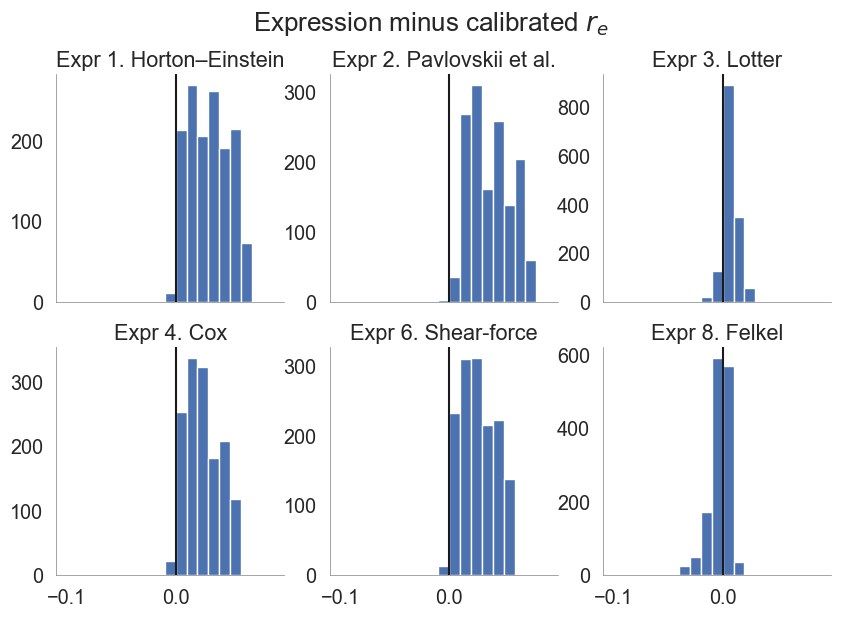

In [ ]:
fig, axes = plt.subplots(2,3, figsize = (10,6.5), sharex = True)
axes = axes.ravel()
for i, col in enumerate(compared.columns):
    axes[i].hist(compared[col], bins = np.arange(-.1, .1, 0.01))
    axes[i].set_title(rename_map[col])
    axes[i].axvline(0, c = 'k')
    # compared.hist()
plt.suptitle("Expression minus calibrated $r_e$")
# TODO: look for patterns in which equations over- vs under-predict, and whether that correlates with any of the input parameters (e.g. do some equations do better for high fV, others for low fV?)
# TODO: add this to SI figures 

Coloring by: 'sigma'  (mean |r| across expressions = 0.343)
{'sigma': '0.343', 'fV': '0.331', 'aniso': '0.148', 'p': '0.063', 'tr': '0.029'}
Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig4]


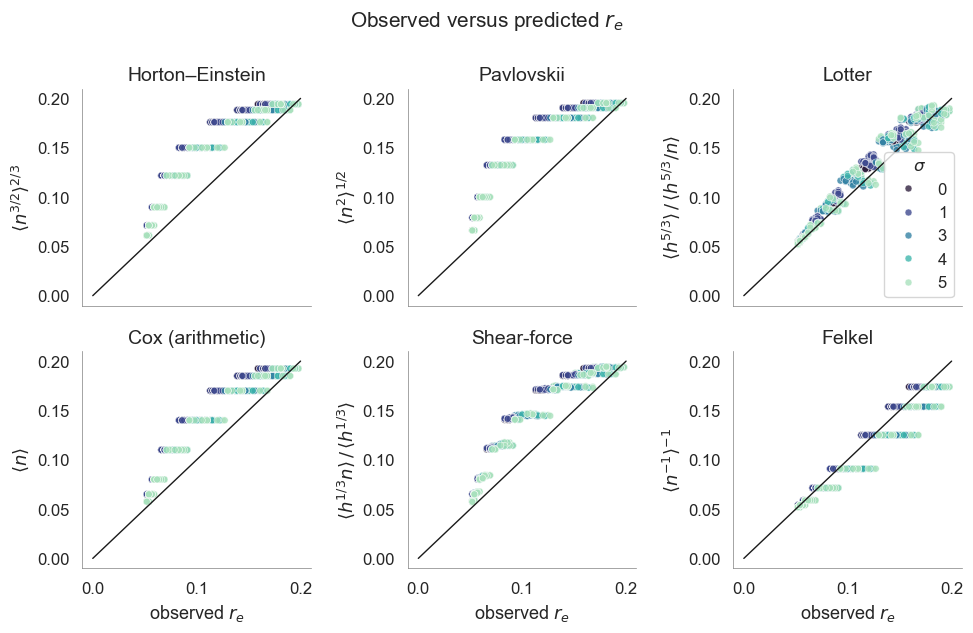

In [ ]:
# ── Find the variable that best explains residuals across all six expressions ──
# Residual for each expression: n_expX − r_equiv
# We scan design-parameter columns and pick the one with highest mean |r|.

_expr_cols = list(compared.columns)  # [n_exp1, n_exp2, n_exp3, n_exp4, n_exp6, n_exp8]

try:
    _sim_cols = [c for c in pd.DataFrame(sim_list).columns if c != 'seed']
except NameError:
    _sim_cols = ['p', 'tr', 'l', 'So', 'fV', 'sigma', 'aniso', 'alpha_v', 'alpha_b', 'Ks_v']

_hue_scores = {}
for c in _sim_cols:
    if c not in summary.columns:
        continue
    try:
        v = pd.to_numeric(summary[c], errors='coerce')
        rs = []
        for ec in _expr_cols:
            resid = compared[ec]
            m = v.notna() & resid.notna() & np.isfinite(resid)
            if m.sum() < 20 or v[m].std() < 1e-10:
                continue
            r = float(np.corrcoef(v[m], resid[m])[0, 1])
            if np.isfinite(r):
                rs.append(abs(r))
        if rs:
            _hue_scores[c] = np.mean(rs)
    except Exception:
        pass

_hue_var   = max(_hue_scores, key=_hue_scores.get)
_hue_score = _hue_scores[_hue_var]
print(f"Coloring by: {_hue_var!r}  (mean |r| across expressions = {_hue_score:.3f})")
print({k: f"{v:.3f}" for k, v in sorted(_hue_scores.items(), key=lambda x: -x[1])})

# ── discrete MAKO palette for the chosen variable ─────────────────────────────
MAX_HUE = 6
_hv_raw    = pd.to_numeric(summary[_hue_var], errors='coerce')
_hv_unique = sorted(_hv_raw.dropna().unique())

if len(_hv_unique) > MAX_HUE:
    _hv_binned  = pd.qcut(_hv_raw, q=MAX_HUE, duplicates='drop')
    _hv_levels  = sorted(_hv_binned.dropna().unique(), key=lambda x: x.left)
    _hv_labels  = [f'({b.left:.3g}, {b.right:.3g}]' for b in _hv_levels]
    _hv_codes   = pd.Categorical(_hv_binned, categories=_hv_levels).codes
    summary['_hue_group'] = [_hv_labels[c] if c >= 0 else np.nan for c in _hv_codes]
    _hue_order  = _hv_labels
else:
    summary['_hue_group'] = _hv_raw.apply(lambda x: f'{x:g}' if np.isfinite(x) else np.nan)
    _hue_order  = [f'{v:g}' for v in _hv_unique]

_hue_palette = {lbl: MAKO(i / max(len(_hue_order) - 1, 1))
                for i, lbl in enumerate(_hue_order)}

_pretty = {'fV': r'$f_V$', 'sigma': r'$\sigma$', 'aniso': 'anisotropy',
           'p': r'$p$ (mm/h)', 'tr': r'$t_r$ (min)', 'l': r'$L$ (m)',
           'So': r'$S_0$', 'Ks_v': r'$K_s$', 'alpha_v': r'$n_v$', 'alpha_b': r'$n_b$'}
_hue_label = _pretty.get(_hue_var, _hue_var)

# ── title and y-axis equation labels ─────────────────────────────────────────
_title_map = {
    'n_exp1': 'Horton–Einstein',
    'n_exp2': 'Pavlovskii',
    'n_exp3': 'Lotter',
    'n_exp4': 'Cox (arithmetic)',
    'n_exp6': 'Shear-force',
    'n_exp8': 'Felkel',
}
_ylabel_map = {
    'n_exp1': r'$\langle n^{3/2}\rangle^{2/3}$',
    'n_exp2': r'$\langle n^2\rangle^{1/2}$',
    'n_exp3': r'$\langle h^{5/3}\rangle\,/\,\langle h^{5/3}/n\rangle$',
    'n_exp4': r'$\langle n\rangle$',
    'n_exp6': r'$\langle h^{1/3}n\rangle\,/\,\langle h^{1/3}\rangle$',
    'n_exp8': r'$\langle n^{-1}\rangle^{-1}$',
}

# ── font sizes ────────────────────────────────────────────────────────────────
_fs_title = 14
_fs_label = 13
_fs_tick  = 12
_fs_leg   = 12

# ── 2×3 scatter: observed vs predicted r_e ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5), sharex=True)
axes = axes.ravel()

for i, col in enumerate(_expr_cols):
    sns.scatterplot(data=summary, x='r_equiv', y=col,
                    hue='_hue_group', hue_order=_hue_order,
                    palette=_hue_palette, ax=axes[i], legend=(i == 2),
                    s=25, alpha=0.8)
    axes[i].set_title(_title_map.get(col, col), fontsize=_fs_title)
    axes[i].set_ylabel(_ylabel_map.get(col, col), fontsize=_fs_label)
    axes[i].tick_params(labelsize=_fs_tick)
    if i == 2:
        axes[i].legend(title=_hue_label, fontsize=_fs_leg, title_fontsize=_fs_leg,
                       frameon=True)
    if i > 2:
        axes[i].set_xlabel(r"observed $r_e$", fontsize=_fs_label)
    axes[i].plot([0, 0.2], [0, 0.2], 'k-', lw=1)

plt.suptitle(r"Observed versus predicted $r_e$", fontsize=_fs_title + 1)
plt.tight_layout()

# ── save figure ──────────────────────────────────────────────────────────────────
_fig_dir, _, _ = _fig_dirs()
_fig4_name = 'fig4_obs_vs_pred_re_6panel.png'
fig.savefig(_os.path.join(_fig_dir, _fig4_name), dpi=300, bbox_inches='tight')

# ── build dynamic registry text from per-expression metrics ──────────────────
_fig4_metrics = {}
for _ec in _expr_cols:
    _obs4 = summary['r_equiv'].to_numpy(float)
    _prd4 = summary[_ec].to_numpy(float)
    _m4   = np.isfinite(_obs4) & np.isfinite(_prd4)
    if _m4.sum() >= 3:
        _r2_4 = float(np.corrcoef(_obs4[_m4], _prd4[_m4])[0, 1]**2)
        _rmse4 = float(np.sqrt(np.mean((_prd4[_m4] - _obs4[_m4])**2)))
    else:
        _r2_4, _rmse4 = np.nan, np.nan
    _fig4_metrics[_ec] = dict(title=_title_map.get(_ec, _ec), r2=_r2_4, rmse=_rmse4)

_interp4 = []
for _ec in _expr_cols:
    _m4d = _fig4_metrics[_ec]
    _interp4.append(f"  - {_m4d['title']}: R²={_m4d['r2']:.2f}, RMSE={_m4d['rmse']:.3f}")

_valid4 = [(k, v) for k, v in _fig4_metrics.items() if np.isfinite(v['r2'])]
_best4  = max(_valid4, key=lambda x: x[1]['r2'])[1] if _valid4 else {}
_worst4 = min(_valid4, key=lambda x: x[1]['r2'])[1] if _valid4 else {}

_concise_4 = (
    f"2×3 observed vs predicted r_e for six composite-roughness expressions, coloured by {_hue_var}. "
    f"{_best4.get('title','?')} tracks the 1:1 line best (R²={_best4.get('r2',0):.2f}); "
    f"{_worst4.get('title','?')} is weakest (R²={_worst4.get('r2',0):.2f})."
)

update_figure_registry(
    'fig4', _fig4_name,
    'Observed vs predicted r_e for six equivalent-roughness expressions '
    '(Horton-Einstein, Pavlovskii, Lotter, Cox, Shear-force, Felkel).\n'
    f'Markers coloured by {_hue_var} (highest mean |r| with residual across expressions).\n'
    '\n'
    'Per-expression performance:\n' + '\n'.join(_interp4) + '\n'
    '\n'
    f'Residual structure is most associated with {_hue_var}.',
    concise=_concise_4)


## Sensitivity to storm characteristics

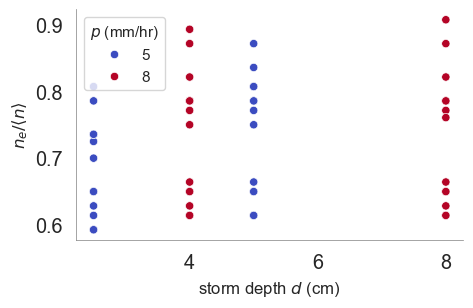

In [ ]:
summary['d'] = summary['p'] * summary['tr'] / 60
ax = sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 "),
                     x='d', y='effect_ratio', hue='p', palette='coolwarm')
ax.set_xlabel(r"storm depth $d$ (cm)", fontsize=12)
ax.set_ylabel(rename.get('effect_ratio', r'$n_e/\langle n \rangle$'), fontsize=12)
ax.legend(title=r"$p$ (mm/hr)", fontsize=11, title_fontsize=11)
# sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 and sigma ==5 "), x='p', y='effect_ratio')

_, _scratch, _ = _fig_dirs()
ax.get_figure().savefig(_os.path.join(_scratch, 'storm_depth_vs_effect_ratio.png'),
                        dpi=200, bbox_inches='tight')



## Comparing effect-ratio predictions

_Benchmarks and diagnostics for decomposition-based predictions of $n_e / \langle n \rangle$._


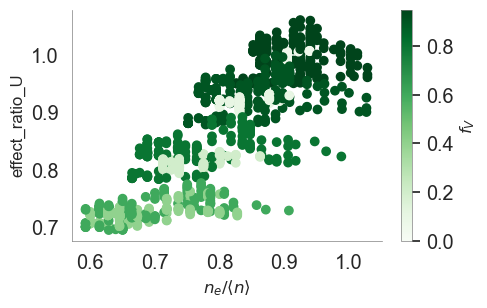

In [61]:
plt.scatter(summary.query("hydro_err < 0.05")['effect_ratio'], 
            summary.query("hydro_err < 0.05")['effect_ratio_U'],
           c = summary.query("hydro_err < 0.05")['fV'],cmap = 'Greens', vmin = 0)

plt.xlabel(renameit('effect_ratio', rename), fontsize=FS_LABEL)
plt.ylabel(renameit('effect_ratio_U', rename), fontsize=FS_LABEL)
_cb = plt.colorbar()
_cb.set_label(renameit('fV', rename), fontsize=FS_LABEL)

# plt.xlim(0, 0.7)
# plt.ylim(0, 0.7)


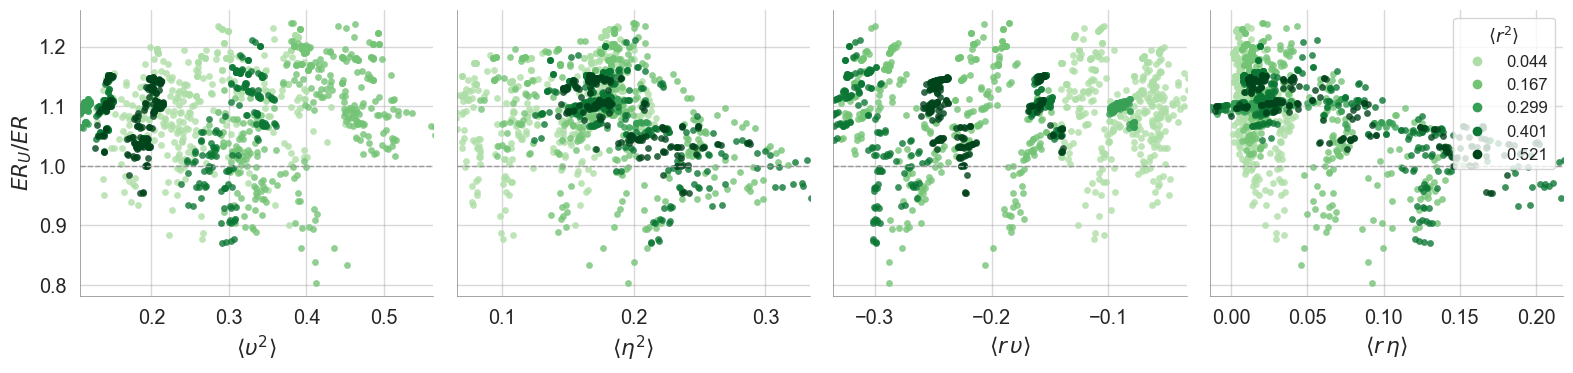

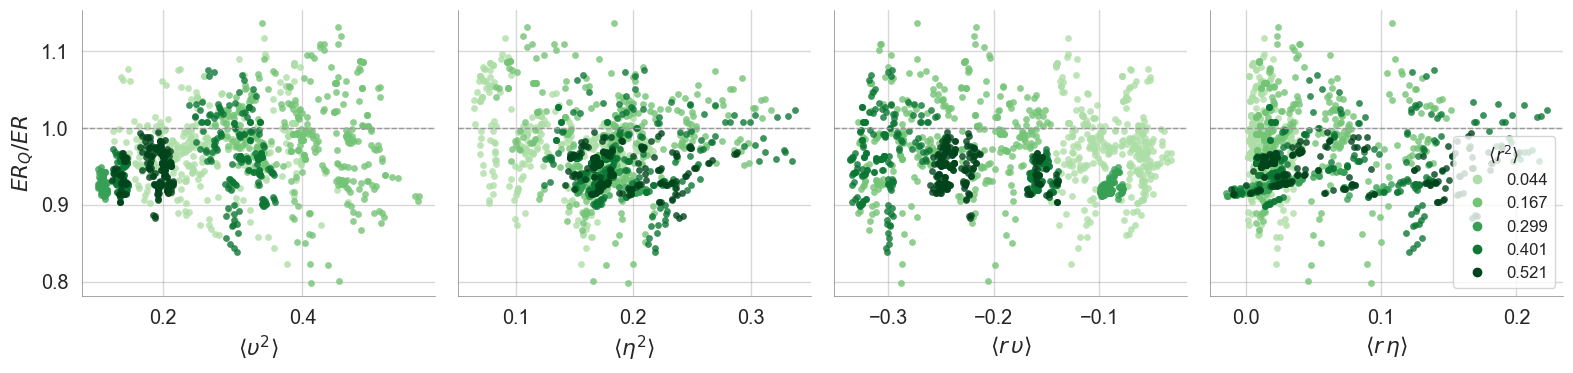

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        which: str = "U",            # "U" or "Q"
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        n_bins: int = 5,             # number of discrete <r2> bins
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_<which>/ER vs <ups2>, <eta2>, <r ups>, <r eta>,
    colored by binned <r2> with a point legend showing bin midpoints.
    Returns (fig, axes).
    """
    which = which.upper()
    if which not in ("U", "Q"):
        raise ValueError("which must be 'U' or 'Q'.")

    er_col = {"U": "effect_ratio_U", "Q": "effect_ratio_Q"}[which]

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eta2>", "<r ups>", "<r eta>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Bin <r2> into discrete categories
    r2 = df["<r2>"]
    valid = r2.notna() & y.notna() & np.isfinite(y)
    bin_edges = np.nanpercentile(r2[valid], np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    n_actual = len(bin_edges) - 1
    bin_mids = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_actual)]
    bin_mid_labels = [f"{m:.3f}" for m in bin_mids]
    bin_range_labels = [
        f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})"
        for i in range(n_actual)
    ]
    r2_binned = pd.cut(r2, bins=bin_edges, labels=bin_range_labels, include_lowest=True)

    cmap = plt.get_cmap("Greens", n_actual + 2)  # +2 to avoid very light start
    bin_colors = {lbl: cmap((i + 2) / (n_actual + 2)) for i, lbl in enumerate(bin_range_labels)}

    # Panel definitions
    xcols  = ["<ups2>", "<eta2>", "<r ups>", "<r eta>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \eta^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\eta\rangle$"]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        for lbl in bin_range_labels:
            m = (r2_binned == lbl) & x.notna() & y.notna() & np.isfinite(y)
            if m.any():
                ax.scatter(x[m], y[m], color=bin_colors[lbl],
                           s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        if clip_percentiles is not None:
            lo, hi = clip_percentiles
            m_all = x.notna() & np.isfinite(y)
            if m_all.any():
                ax.set_xlim(*np.nanpercentile(x[m_all], [lo, hi]))

    axes[0].set_ylabel(fr"$ER_{which}/ER$")

    # Point legend: one entry per bin, label = midpoint value
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=bin_colors[lbl], markersize=6, label=bin_mid_labels[i])
        for i, lbl in enumerate(bin_range_labels)
    ]
    axes[-1].legend(handles=legend_handles, title=r"$\langle r^{2}\rangle$",
                    fontsize=12, title_fontsize=13,
                    loc="best", frameon=True)

    fig.tight_layout()
    return fig, axes

# Examples:
fig, axes = plot_er_ratio_4cols(summary, which="U", err_thresh=0.05, clip_percentiles=(.1,99.9))
fig, axes = plot_er_ratio_4cols(summary, which="Q", err_thresh=0.05)


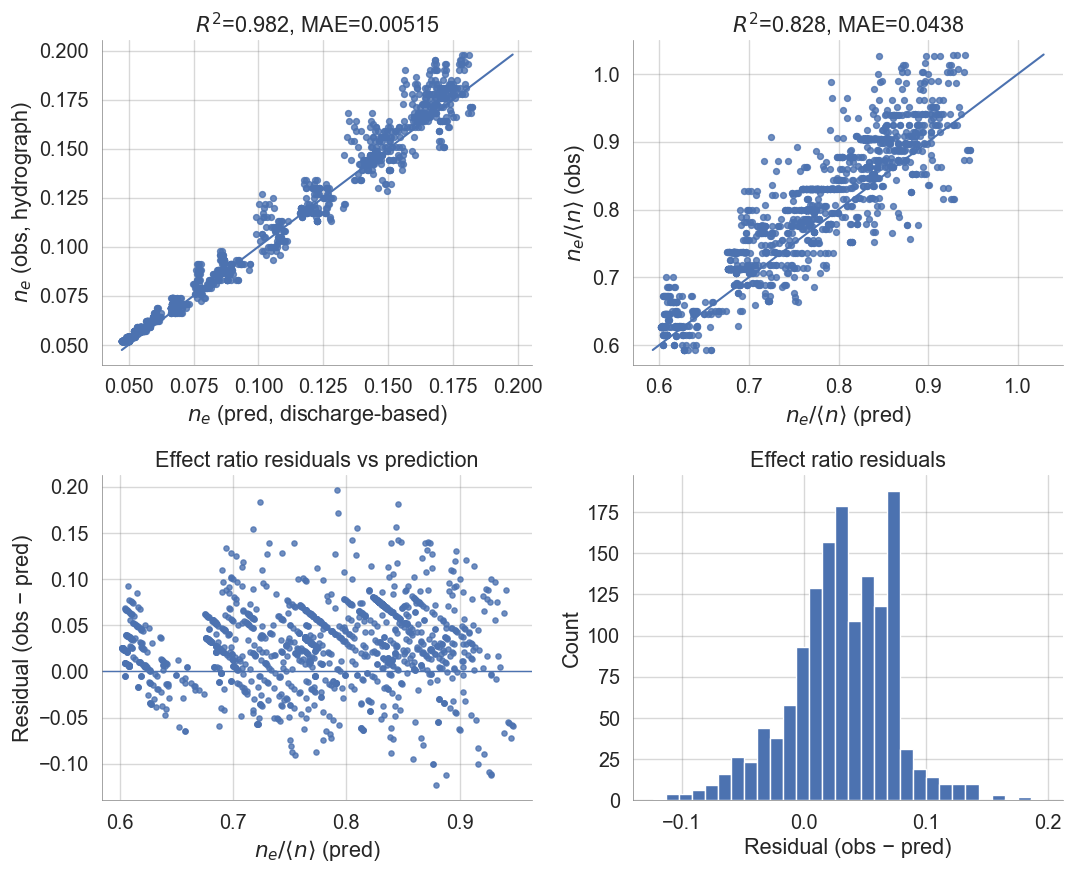

In [38]:
# -----------------------------------------------------------------------
# Diagnostic: predicted vs. observed n_e and effect ratio (n_e/<n>)
#
# Two quantities are compared:
#   (1) n_e          — the equivalent Manning roughness matched to the
#                      simulated hydrograph (r_equiv5), vs. the
#                      discharge-based prediction n_e_Qpred = ER_Q * <n>
#   (2) effect ratio — n_e/<n>, observed vs. effect_ratio_Q (discharge-based)
#
# The 2×2 panel layout is:
#   A (top-left)   : n_e pred vs obs — checks absolute roughness accuracy
#   B (top-right)  : effect ratio pred vs obs — checks relative correction
#   C (bottom-left): effect ratio residuals vs predicted — looks for bias
#   D (bottom-right): residual histogram — checks symmetry / normality
# -----------------------------------------------------------------------

# --- 1) Extract arrays, masking NaNs ---

# Observed effect ratio from hydrograph calibration (r_equiv5 / <n>)
er_obs = summary['effect_ratio'].to_numpy(float)
# Predicted effect ratio from discharge-based formula
er_hat = summary['effect_ratio_Q'].to_numpy(float)

# Observed equivalent roughness from hydrograph calibration
ne_obs = summary['r_equiv5'].to_numpy(float)
# Predicted n_e: multiply discharge-based ER back by the spatial mean n
summary['n_e_Qpred'] = summary['effect_ratio_Q'] * summary['<n>']
ne_hat = summary['n_e_Qpred'].to_numpy(float)

# Boolean masks: only include rows where both pred and obs are finite
m_er = np.isfinite(er_obs) & np.isfinite(er_hat)
m_ne = np.isfinite(ne_obs) & np.isfinite(ne_hat)

# --- Helper metrics ---
def r2(x, y):
    """Pearson R² between two arrays (returns NaN if fewer than 3 valid pairs)."""
    if np.sum(np.isfinite(x) & np.isfinite(y)) < 3:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1]**2)

def mae(x, y):
    """Mean absolute error."""
    return float(np.nanmean(np.abs(x - y)))

# --- 2) Plots: predicted vs observed + residual diagnostics ---
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
(ax1, ax2), (ax3, ax4) = axs

# A: n_e (pred vs obs) — absolute roughness accuracy
x, y = ne_hat[m_ne], ne_obs[m_ne]
ax1.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax1.plot([mn, mx], [mn, mx])  # 1:1 line
ax1.set_xlabel(r"$n_e$ (pred, discharge-based)")
ax1.set_ylabel(r"$n_e$ (obs, hydrograph)")
ax1.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax1.grid(True, alpha=0.3)

# B: effect ratio (pred vs obs) — relative correction accuracy
x, y = er_hat[m_er], er_obs[m_er]
ax2.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax2.plot([mn, mx], [mn, mx])  # 1:1 line
ax2.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax2.set_ylabel(r"$n_e/\langle n\rangle$ (obs)")
ax2.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax2.grid(True, alpha=0.3)

# C: residuals vs predicted — checks for systematic over/under-prediction
res = (er_obs[m_er] - er_hat[m_er])
ax3.scatter(er_hat[m_er], res, s=14, alpha=0.8)
ax3.axhline(0, linewidth=1)  # zero-residual reference
ax3.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax3.set_ylabel("Residual (obs − pred)")
ax3.set_title("Effect ratio residuals vs prediction")
ax3.grid(True, alpha=0.3)

# D: residual histogram — checks for symmetry around zero
ax4.hist(res[~np.isnan(res)], bins=30)
ax4.set_xlabel("Residual (obs − pred)")
ax4.set_ylabel("Count")
ax4.set_title("Effect ratio residuals")
ax4.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


In [39]:
summary['effect_ratio_T0'] =   1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']

# T1: adds first-order depth-fluctuation correction (negative sign)
summary['effect_ratio_T1'] =   1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']
        #    - 8/3*(summary['<r eta>'] + summary['<eta ups>'])    
        
summary['effect_ratio_T2'] =  1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']\
           - 8/3*(summary['<r eta>'] + summary['<eta ups>'])\
           + 14/9*summary['<eta2>']        
       
    
# Aliases for convenience
summary["ER_obs"] = summary["effect_ratio"]
summary["ER_Q"]   = summary.get("effect_ratio_Q", np.nan)
summary["ER_U"]   = summary.get("effect_ratio_U", np.nan)
summary["ER_leading"] =  summary['So'] / summary['<Sf>_nbar2_Ubar2']

# ---------------------------
# 1) Residuals vs observed
# ---------------------------
summary["res_Q"] = summary["ER_Q"] - summary["ER_obs"]
summary["res_U"] = summary["ER_U"] - summary["ER_obs"]

# ---------------------------
# 2) Fit metrics (bias, MAE, RMSE, R^2)
# ---------------------------
def fit_metrics(yhat, y):
    m = np.isfinite(yhat) & np.isfinite(y)
    if m.sum() < 3:
        return dict(n=int(m.sum()), bias=np.nan, mae=np.nan, rmse=np.nan, r2=np.nan)
    dy = yhat[m] - y[m]
    bias = float(np.mean(dy))
    mae  = float(np.mean(np.abs(dy)))
    rmse = float(np.sqrt(np.mean(dy**2)))
    r = float(np.corrcoef(yhat[m], y[m])[0,1])
    return dict(n=int(m.sum()), bias=bias, mae=mae, rmse=rmse, r2=r**2)

m_Q = fit_metrics(summary["ER_Q"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_U = fit_metrics(summary["ER_U"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_Qpred2 = fit_metrics(summary["effect_ratio_Qpred2"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_Upred2 = fit_metrics(summary["effect_ratio_Upred2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_T0 = fit_metrics(summary["effect_ratio_T0"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T1 = fit_metrics(summary["effect_ratio_T1"].to_numpy(float), summary["ER_obs"].to_numpy(float))
m_T2 = fit_metrics(summary["effect_ratio_T2"].to_numpy(float), summary["ER_obs"].to_numpy(float))

m_L = fit_metrics(summary["ER_leading"].to_numpy(float), summary["ER_obs"].to_numpy(float))

def print_metrics(label, m):
    print(f"{label}: n={m['n']}, "
          f"bias={m['bias']:.3f}, mae={m['mae']:.3f}, "
          f"rmse={m['rmse']:.3f}, r2={m['r2']:.3f}")

print("\n=== Effect ratio vs observed ===")
print_metrics("Q-based  vs obs", m_Q)
print_metrics("U-based  vs obs", m_U)

# ---------------------------
# 3) Which is closer to observed?
# ---------------------------
absQ = np.abs(summary["res_Q"])
absU = np.abs(summary["res_U"])
winner = np.where(absU < absQ, "U", np.where(absQ < absU, "Q", "tie"))
summary["ER_winner"] = winner
print("\nCount by winner (closer to observed):")
print(pd.Series(winner).value_counts())


# ---------------------------
# 4) Correlate residuals with drivers → combined table
# ---------------------------
drivers = ["<r2>", "<ups2>", "<eta2>", "<r ups>", "<r eta>", "<n>"]
drivers = [c for c in drivers if c in summary.columns]

def corr_to_res(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Compute for whichever residuals exist
residuals = [c for c in ["res_Q", "res_U"] if c in summary.columns]
combined_corr = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)

ERs = [c for c in ["effect_ratio_Q", "effect_ratio_U"] if c in summary.columns]
combined_ER = pd.concat([corr_to_res(r) for r in residuals], ignore_index=True)


# Add |r| and round for display
combined_corr["abs_r"] = combined_corr["pearson_r"].abs()
combined_corr_disp = combined_corr.copy()
combined_corr_disp["pearson_r"] = combined_corr_disp["pearson_r"].round(3)
combined_corr_disp["abs_r"]     = combined_corr_disp["abs_r"].round(3)

# Sort (strongest correlations first within each residual)
combined_corr_disp = (combined_corr_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True)
)

# Heatmap-friendly pivot (rows: residuals, columns: drivers)
corr_pivot = (combined_corr
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)

# If you want a neatly rounded pivot for quick viewing:
corr_pivot_disp = corr_pivot.round(3)

# --- LaTeX label maps ---
var_tex = {
    "<r2>":    r"$\langle r^2\rangle$",
    "<ups2>":  r"$\langle \upsilon^2\rangle$",
    "<eta2>":  r"$\langle \eta^2\rangle$",
    "<r ups>": r"$\langle r\,\upsilon\rangle$",
    "<r eta>": r"$\langle r\,\eta\rangle$",
    "fV":      r"$f_V$",
    "<n>":     r"$\langle n\rangle$",
}
res_tex = {
    "res_Q": r"$ER_Q - ER$",
    "res_U": r"$ER_U - ER$",
}

er_tex = {
    "effect_ratio_Q": r"$ER_Q$",
    "effect_ratio_U": r"$ER_U$",
    "effect_ratio":    r"$ER$",
}

# ---------- 1) Set a single canonical driver order ----------
driver_order_raw = ["<r2>", "<ups2>", "<eta2>", "<r ups>", "<r eta>", "<n>"]

# LaTeX labels for that order

x_order_tex = [var_tex[d] for d in driver_order_raw]

# Add LaTeX label columns for plotting
combined_corr_disp = combined_corr_disp.copy()
combined_corr_disp["var_tex"] = combined_corr_disp["var"].map(var_tex).fillna(combined_corr_disp["var"])
combined_corr_disp["variable_tex"] = combined_corr_disp["variable"].map(res_tex).fillna(combined_corr_disp["variable"])



=== Effect ratio vs observed ===
Q-based  vs obs: n=1439, bias=-0.032, mae=0.044, rmse=0.053, r2=0.828
U-based  vs obs: n=1439, bias=0.069, mae=0.081, rmse=0.090, r2=0.713

Count by winner (closer to observed):
Q      1131
U       308
tie       1
Name: count, dtype: int64


In [40]:
summary['fV'].unique()


array([0.05, 0.1 , 0.2 , 0.4 , 0.6 , 0.8 , 0.9 , 0.95])

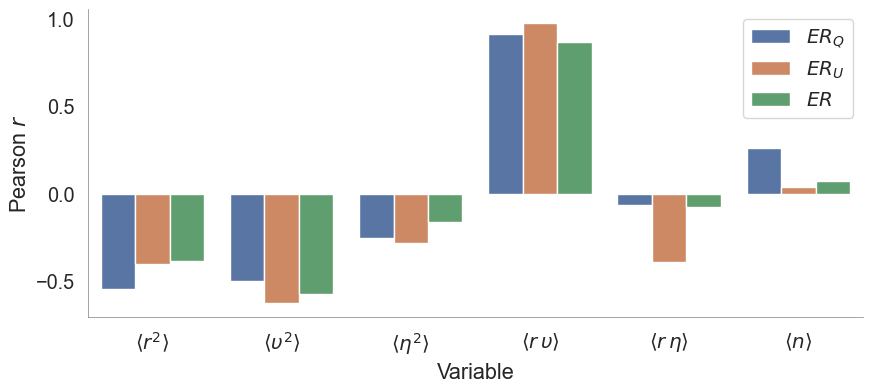

In [41]:
# ------------- Effect ratios to analyze -------------
# include observed ER if available
ERs = [c for c in ["effect_ratio_Q", "effect_ratio_U", "effect_ratio"] if c in summary.columns]

def corr_to_target(yname):
    rows = []
    for d in drivers:
        xy = summary[[yname, d]].dropna()
        if len(xy) >= 3:
            r = np.corrcoef(xy[yname], xy[d])[0, 1]
            rows.append({"variable": yname, "var": d, "pearson_r": r})
    return pd.DataFrame(rows)

# Build effect-ratio correlation table
combined_ER = pd.concat([corr_to_target(er) for er in ERs], ignore_index=True)

# Add |r| and make a display copy
combined_ER["abs_r"] = combined_ER["pearson_r"].abs()
combined_ER_disp = combined_ER.copy()
combined_ER_disp["pearson_r"] = combined_ER_disp["pearson_r"].round(3)
combined_ER_disp["abs_r"]     = combined_ER_disp["abs_r"].round(3)

# Sort within each ER by |r|
combined_ER_disp = (combined_ER_disp
    .sort_values(["variable", "abs_r"], ascending=[True, False])
    .reset_index(drop=True))

# Pivot (rows: ERs, cols: drivers) for quick inspection/heatmap if desired
ER_corr_pivot = (combined_ER
    .pivot(index="variable", columns="var", values="pearson_r")
    .sort_index()
)
ER_corr_pivot_disp = ER_corr_pivot.round(3)

er_order      = [e for e in ["effect_ratio_Q", "effect_ratio_U", "effect_ratio"] if e in ERs]
er_order_tex  = [er_tex[e] for e in er_order]

# Map LaTeX labels for plotting
combined_ER_disp = combined_ER_disp.copy()
combined_ER_disp["var_tex"] = combined_ER_disp["var"].map(var_tex).fillna(combined_ER_disp["var"])
combined_ER_disp["variable_tex"] = combined_ER_disp["variable"].map(er_tex).fillna(combined_ER_disp["variable"])

# --- Barplot of correlations (effect ratios vs drivers) ---
plt.figure(figsize=(10, 4))
sns.barplot(data=combined_ER_disp, x="var_tex", y="pearson_r", hue="variable_tex", order = x_order_tex,
            hue_order=er_order_tex)
plt.xlabel("Variable")
plt.ylabel(r"Pearson $r$")
plt.xticks(rotation=0);
plt.legend(title = '')


In [42]:
### Something important here? 
A = summary['<h>']**(4/3.)/summary['<n>']**(2)/summary['<U>']**(2.)
# summary['<Sf>_nbar2_Ubar2'] == -  1/A

summary.query("fV < 0.4")[['effect_ratio', 'ER_leading', 'effect_ratio_T0','effect_ratio_T1',
         'effect_ratio_T2', 'ER_Q', 'ER_U']].corr().round(2)


,effect_ratio,ER_leading,effect_ratio_T0,effect_ratio_T1,effect_ratio_T2,ER_Q,ER_U
effect_ratio,1.00,0.95,0.93,0.93,0.84,0.98,0.93
ER_leading,0.95,1.00,0.98,0.98,0.94,0.96,0.99
effect_ratio_T0,0.93,0.98,1.00,1.00,0.92,0.95,0.97
effect_ratio_T1,0.93,0.98,1.00,1.00,0.92,0.95,0.97
effect_ratio_T2,0.84,0.94,0.92,0.92,1.00,0.84,0.96
ER_Q,0.98,0.96,0.95,0.95,0.84,1.00,0.93
ER_U,0.93,0.99,0.97,0.97,0.96,0.93,1.00


In [43]:
# T1 and T2 already defined above
summary[['effect_ratio', 'effect_ratio_T0','effect_ratio_T1', 'effect_ratio_T2']].corr().round(2)


,effect_ratio,effect_ratio_T0,effect_ratio_T1,effect_ratio_T2
effect_ratio,1.00,0.82,0.82,0.87
effect_ratio_T0,0.82,1.00,1.00,0.93
effect_ratio_T1,0.82,1.00,1.00,0.93
effect_ratio_T2,0.87,0.93,0.93,1.00


Saved → ../figures/runaround_smooth/scratch/pred_vs_obs_3panel.png


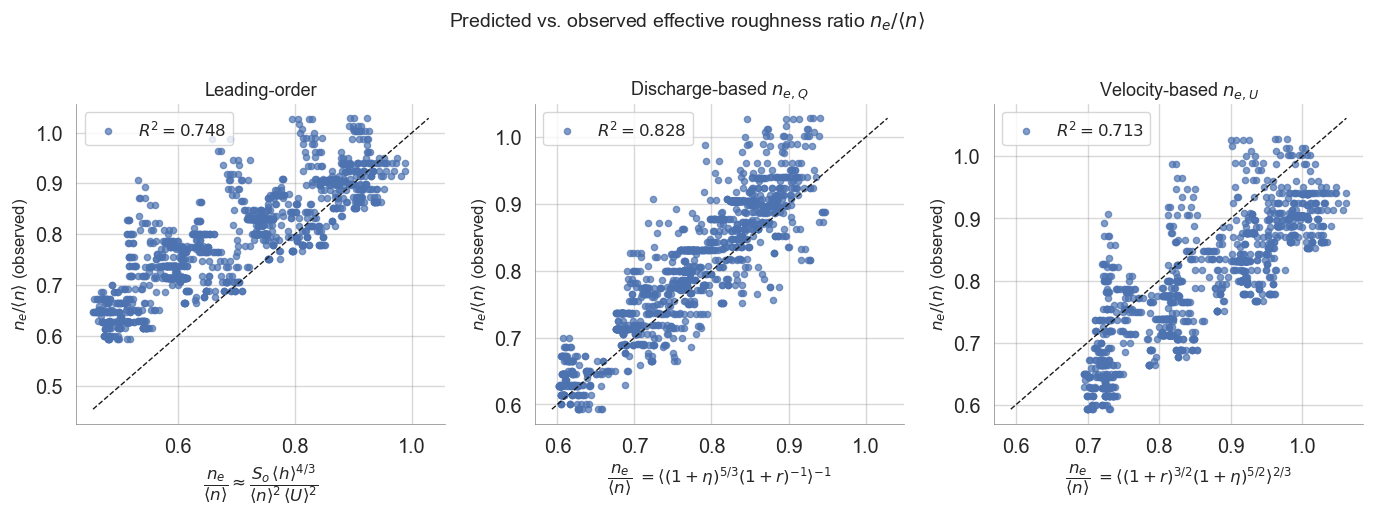

In [44]:

# Predicted vs observed — three analytic approximations
fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))

# --- axis 0: leading-order (mean-roughness only) ---
ax = axes[0]
xy0 = (
    summary.assign(_obs=summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [['_obs', 'effect_ratio']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7, s=20, label=f'$R^2 = {m_L["r2"]:.3f}$')
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], 'k--', linewidth=1)

ax.set_xlabel(
    r'$\dfrac{n_e}{\langle n\rangle} \approx \dfrac{S_o\,\langle h\rangle^{4/3}}{\langle n\rangle^2\,\langle U\rangle^2}$',
    fontsize=FS_LABEL)
ax.set_ylabel(r'$n_e/\langle n\rangle$ (observed)', fontsize=FS_LABEL)
ax.set_title('Leading-order', fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEG, loc='upper left')
ax.grid(True, alpha=0.3)

# --- axis 1: discharge-based effective roughness ---
ax = axes[1]
xy = summary[['effect_ratio_Q', 'effect_ratio']].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:, 0], xy[:, 1], alpha=0.7, s=20, label=f'$R^2 = {m_Q["r2"]:.3f}$')
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1)

ax.set_xlabel(
    r'$\dfrac{n_e}{\langle n\rangle}  $'
    + r' $= \langle(1+\eta)^{5/3}(1+r)^{-1}\rangle^{-1}$',
    #  \dfrac{\langle h\rangle^{5/3}}{\langle n\rangle\,\langle h^{5/3}/n\rangle}
    fontsize=FS_LABEL)
ax.set_ylabel(r'$n_e/\langle n\rangle$ (observed)', fontsize=FS_LABEL)
ax.set_title(f'Discharge-based $n_{{e,Q}}$', fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEG, loc='upper left')
ax.grid(True, alpha=0.3)

# --- axis 2: velocity-based effective roughness ---
ax = axes[2]
xy = summary[['effect_ratio_U', 'effect_ratio']].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:, 0], xy[:, 1], alpha=0.7, s=20, label=f'$R^2 = {m_U["r2"]:.3f}$')
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1)

ax.set_xlabel(
    r'$\dfrac{n_e}{\langle n\rangle} $'
    + r' $= \langle(1+r)^{3/2}(1+\eta)^{5/2}\rangle^{2/3}$',
    # = \left(\dfrac{\langle n^{3/2}\,h^{5/2}\rangle}{\langle n\rangle^{3/2}\,\langle h\rangle^{5/2}}\right)^{2/3}
    fontsize=FS_LABEL)
ax.set_ylabel(r'$n_e/\langle n\rangle$ (observed)', fontsize=FS_LABEL)
ax.set_title(f'Velocity-based $n_{{e,U}}$', fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEG, loc='upper left')
ax.grid(True, alpha=0.3)

fig.suptitle(r'Predicted vs. observed effective roughness ratio $n_e/\langle n\rangle$',
             fontsize=FS_TITLE + 1, y=1.0)
fig.tight_layout()

_, _scratch, _ = _fig_dirs()
fig.savefig(_os.path.join(_scratch, 'pred_vs_obs_3panel.png'), dpi=200, bbox_inches='tight')
print(f'Saved → {_scratch}/pred_vs_obs_3panel.png')


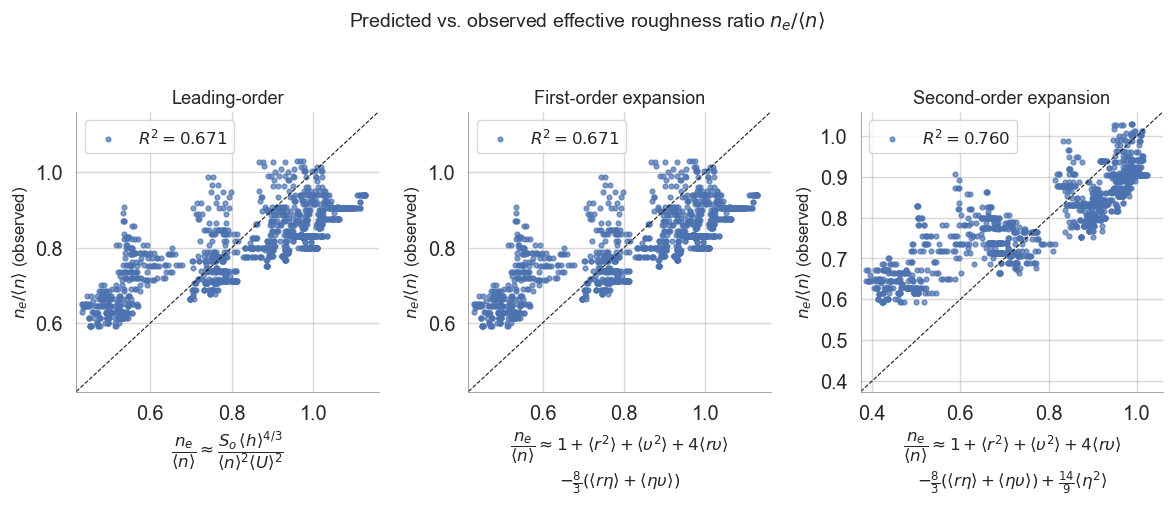

In [45]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 3, figsize = (12, 5))

_configs = [
    ('effect_ratio_T0',
     'Leading-order',
     r'$\dfrac{n_e}{\langle n\rangle} \approx \dfrac{S_o\,\langle h\rangle^{4/3}}{\langle n\rangle^2\langle U\rangle^2}$'),

    ('effect_ratio_T1',
     'First-order expansion',
     r'$\dfrac{n_e}{\langle n\rangle} \approx 1 + \langle r^2\rangle + \langle\upsilon^2\rangle + 4\langle r\upsilon\rangle$'
     '\n'
     r'$- \frac{8}{3}(\langle r\eta\rangle + \langle\eta\upsilon\rangle)$'),

    ('effect_ratio_T2',
     'Second-order expansion',
     r'$\dfrac{n_e}{\langle n\rangle} \approx 1 + \langle r^2\rangle + \langle\upsilon^2\rangle + 4\langle r\upsilon\rangle$'
     '\n'
     r'$- \frac{8}{3}(\langle r\eta\rangle + \langle\eta\upsilon\rangle) + \frac{14}{9}\langle\eta^2\rangle$'),

]

for ax, (xcol, title, xlabel) in zip(axes, _configs):
    xy = summary[[xcol, 'effect_ratio']].dropna().to_numpy(float)
    x, y = xy[:, 0], xy[:, 1]
    r2 = float(np.corrcoef(x, y)[0, 1]**2) if len(x) > 2 else float('nan')
    ax.scatter(x, y, s=12, alpha=0.7, label=f'$R^2 = {r2:.3f}$')
    lims = [min(x.min(), y.min()) * 0.97, max(x.max(), y.max()) * 1.03]
    ax.plot(lims, lims, 'k--', linewidth=0.8)
    ax.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax.set_ylabel(r'$n_e / \langle n \rangle$ (observed)', fontsize=FS_LABEL)
    ax.set_title(title, fontsize=FS_TITLE )
    ax.legend(fontsize=FS_LEG, loc='upper left')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.grid(True, alpha=0.3)

fig.suptitle(r"Predicted vs. observed effective roughness ratio $n_e/\langle n\rangle$",
             fontsize=FS_TITLE + 1, y=1.02)
fig.tight_layout()
plt.show()


In [46]:
summary['fV'].unique()


array([0.05, 0.1 , 0.2 , 0.4 , 0.6 , 0.8 , 0.9 , 0.95])

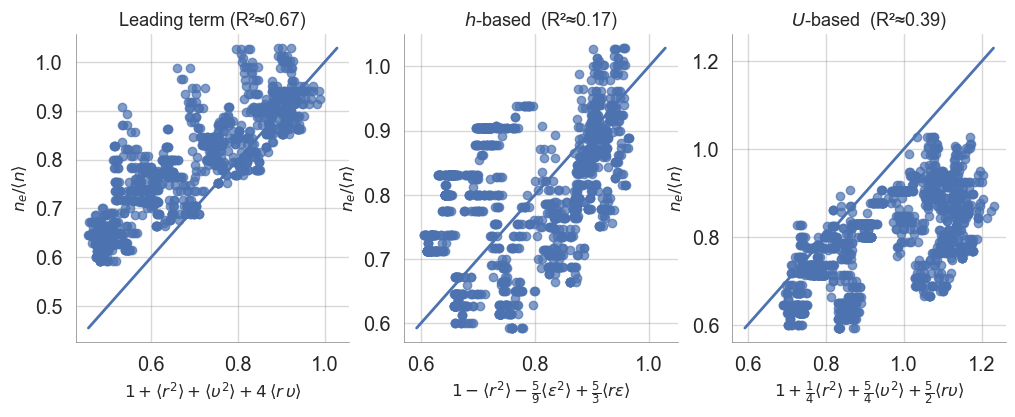

In [47]:
# Predicted vs observed (Q)
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

# --- axis 0 ---
ax = axes[0]
xy0 = (
    summary.assign(_obs = summary['So'] / summary['<Sf>_nbar2_Ubar2'])
           [[ '_obs', 'effect_ratio']]
           .dropna()
           .to_numpy(float))
if xy0.size:
    ax.scatter(xy0[:, 0], xy0[:, 1], alpha=0.7)
    mn0, mx0 = np.nanmin(xy0), np.nanmax(xy0)
    ax.plot([mn0, mx0], [mn0, mx0], linewidth=2)

    
label =  r'$1 + \langle r^{2}\rangle + \langle \upsilon^{2}\rangle + 4\,\langle r\,\upsilon\rangle$'
ax.set_xlabel(label, fontsize=12)
ax.set_ylabel(r"${n_e}/{\langle n\rangle}$", fontsize=12)
ax.set_title(r'Leading term' + f" (R²≈{m_T0['r2']:.2f})", fontsize=13)
ax.grid(True, alpha=0.3)

# --- axis 1: Q-based vs observed ---
ax = axes[1]
xy = summary[["effect_ratio_Qpred2", "effect_ratio"]].dropna().to_numpy(float)
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

ax.set_ylabel(r"${n_e}/{\langle n\rangle}$", fontsize=12)
ax.set_xlabel(r"$1 - \langle r^2 \rangle - \frac{5}{9}\langle \epsilon^2 \rangle + \frac{5}{3}\left\langle r \epsilon \right\rangle$", fontsize=12)
ax.set_title(f"$h$-based  (R²≈{m_Qpred2['r2']:.2f})", fontsize=13)
ax.grid(True, alpha=0.3)

# --- axis 2: U-based vs observed ---
xy = summary[["effect_ratio_Upred2", "effect_ratio"]].dropna().to_numpy(float)
ax = axes[2]
if xy.size:
    ax.scatter(xy[:,0], xy[:,1], alpha=0.7)
    mn, mx = np.nanmin(xy), np.nanmax(xy)
    ax.plot([mn,mx],[mn,mx], linewidth=2)

ax.set_ylabel(r"${n_e}/{\langle n\rangle}$", fontsize=12)
ax.set_xlabel(r"$1+\frac{1}{4}\langle r^2\rangle +\frac{5}{4}\langle \upsilon^2\rangle +\frac{5}{2}\langle r\upsilon\rangle$", fontsize=12)
ax.set_title(f"$U$-based  (R²≈{m_Upred2['r2']:.2f})", fontsize=13)
ax.grid(True, alpha=0.3)


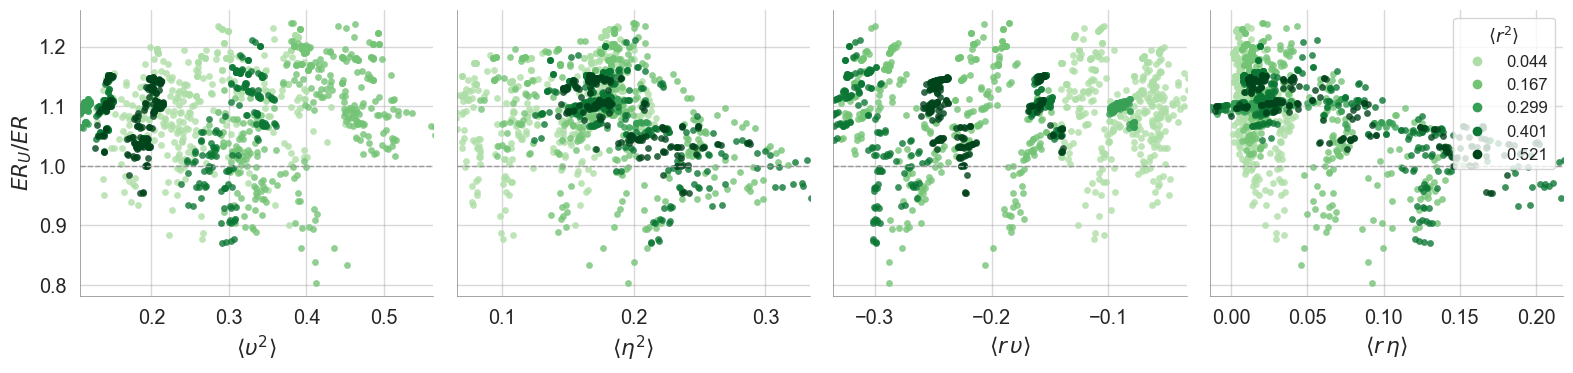

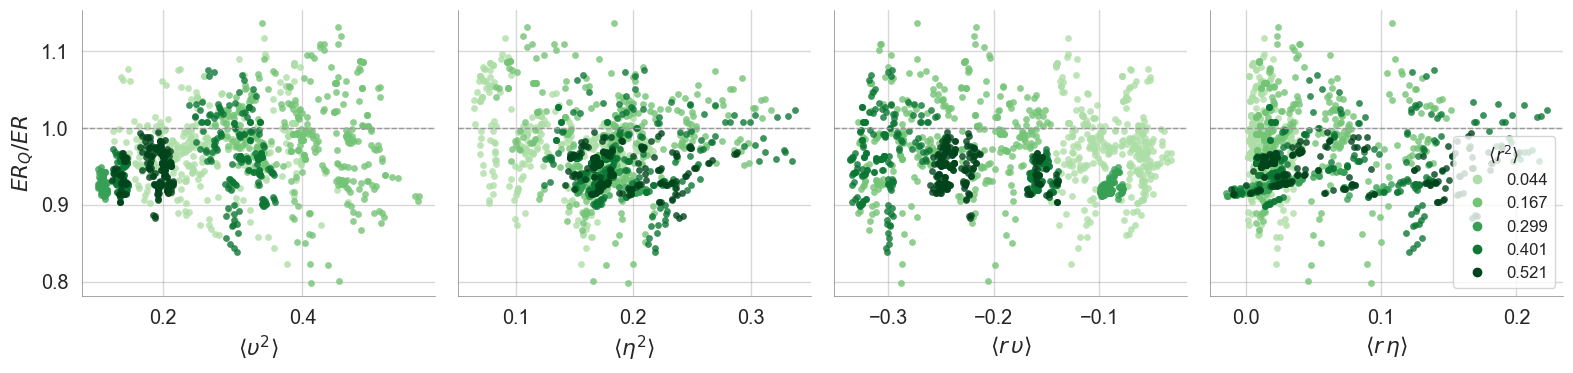

In [48]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        which: str = "U",            # "U" or "Q"
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        n_bins: int = 5,             # number of discrete <r2> bins
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_<which>/ER vs <ups2>, <eta2>, <r ups>, <r eta>,
    colored by binned <r2> with a point legend showing bin midpoints.
    Returns (fig, axes).
    """
    which = which.upper()
    if which not in ("U", "Q"):
        raise ValueError("which must be 'U' or 'Q'.")

    er_col = {"U": "effect_ratio_U", "Q": "effect_ratio_Q"}[which]

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eta2>", "<r ups>", "<r eta>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Bin <r2> into discrete categories
    r2 = df["<r2>"]
    valid = r2.notna() & y.notna() & np.isfinite(y)
    bin_edges = np.nanpercentile(r2[valid], np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    n_actual = len(bin_edges) - 1
    bin_mids = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_actual)]
    bin_mid_labels = [f"{m:.3f}" for m in bin_mids]
    bin_range_labels = [
        f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})"
        for i in range(n_actual)
    ]
    r2_binned = pd.cut(r2, bins=bin_edges, labels=bin_range_labels, include_lowest=True)

    cmap = plt.get_cmap("Greens", n_actual + 2)  # +2 to avoid very light start
    bin_colors = {lbl: cmap((i + 2) / (n_actual + 2)) for i, lbl in enumerate(bin_range_labels)}

    # Panel definitions
    xcols  = ["<ups2>", "<eta2>", "<r ups>", "<r eta>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \eta^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\eta\rangle$"]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        for lbl in bin_range_labels:
            m = (r2_binned == lbl) & x.notna() & y.notna() & np.isfinite(y)
            if m.any():
                ax.scatter(x[m], y[m], color=bin_colors[lbl],
                           s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        if clip_percentiles is not None:
            lo, hi = clip_percentiles
            m_all = x.notna() & np.isfinite(y)
            if m_all.any():
                ax.set_xlim(*np.nanpercentile(x[m_all], [lo, hi]))

    axes[0].set_ylabel(fr"$ER_{which}/ER$")

    # Point legend: one entry per bin, label = midpoint value
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=bin_colors[lbl], markersize=6, label=bin_mid_labels[i])
        for i, lbl in enumerate(bin_range_labels)
    ]
    axes[-1].legend(handles=legend_handles, title=r"$\langle r^{2}\rangle$",
                    fontsize=12, title_fontsize=13,
                    loc="best", frameon=True)

    fig.tight_layout()
    return fig, axes

# Examples:
fig, axes = plot_er_ratio_4cols(summary, which="U", err_thresh=0.05, clip_percentiles=(.1,99.9))
fig, axes = plot_er_ratio_4cols(summary, which="Q", err_thresh=0.05)


In [ ]:
(summary[['effect_ratio', '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU',  
                                    'effect_ratio_U', 'effect_ratio_Q',
                                    'effect_ratio_Upred2', 'effect_ratio_Qpred2']].corr()).round(3)


In [ ]:
# summary['effect_ratio'] = 1/summary['effect_ratio']

(summary.query("hydro_err < 1")[['effect_ratio', '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU',  
                                 '<Sf>_Ubar2_np2',  '<Sf>_nbar2_Up2']].corr()).round(3)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_er_ratio_4cols(summary: pd.DataFrame,
                        which: str = "U",            # "U" or "Q"
                        err_thresh: float = 0.05,    # filter on hydro_err
                        figsize=(16, 4),
                        s: float = 24, alpha: float = 0.8,
                        n_bins: int = 5,             # number of discrete <r2> bins
                        clip_percentiles=None):      # e.g., (1,99) to clip x/y
    """
    Four-panel plot of ER_<which>/ER vs <ups2>, <eta2>, <r ups>, <r eta>,
    colored by binned <r2> with a point legend showing bin midpoints.
    Returns (fig, axes).
    """
    which = which.upper()
    if which not in ("U", "Q"):
        raise ValueError("which must be 'U' or 'Q'.")

    er_col = {"U": "effect_ratio_U", "Q": "effect_ratio_Q"}[which]

    # Observed ER
    if "effect_ratio" in summary.columns:
        ER_obs = summary["effect_ratio"]
    elif {"r_equiv5", "<n>"}.issubset(summary.columns):
        ER_obs = summary["r_equiv5"] / summary["<n>"]
    else:
        raise ValueError("Need 'effect_ratio' or both 'r_equiv5' and '<n>'.")

    # Filter once
    df = summary.query("hydro_err < @err_thresh").copy()

    # Coerce to numeric
    cols_needed = ["<ups2>", "<eta2>", "<r ups>", "<r eta>", "<r2>", er_col]
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")
        df[c] = pd.to_numeric(df[c], errors="coerce")
    ERo = pd.to_numeric(ER_obs.loc[df.index], errors="coerce")

    # Response
    y = df[er_col] / ERo

    # Bin <r2> into discrete categories
    r2 = df["<r2>"]
    valid = r2.notna() & y.notna() & np.isfinite(y)
    bin_edges = np.nanpercentile(r2[valid], np.linspace(0, 100, n_bins + 1))
    bin_edges = np.unique(bin_edges)
    n_actual = len(bin_edges) - 1
    bin_mids = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(n_actual)]
    bin_mid_labels = [f"{m:.3f}" for m in bin_mids]
    bin_range_labels = [
        f"[{bin_edges[i]:.3f}, {bin_edges[i+1]:.3f})"
        for i in range(n_actual)
    ]
    r2_binned = pd.cut(r2, bins=bin_edges, labels=bin_range_labels, include_lowest=True)

    cmap = plt.get_cmap("Greens", n_actual + 2)  # +2 to avoid very light start
    bin_colors = {lbl: cmap((i + 2) / (n_actual + 2)) for i, lbl in enumerate(bin_range_labels)}

    # Panel definitions
    xcols  = ["<ups2>", "<eta2>", "<r ups>", "<r eta>"]
    xlabels = [r"$\langle \upsilon^{2}\rangle$",
               r"$\langle \eta^{2}\rangle$",
               r"$\langle r\,\upsilon\rangle$",
               r"$\langle r\,\eta\rangle$"]

    fig, axes = plt.subplots(1, 4, figsize=figsize, sharey=True)

    for ax, xcol, xlab in zip(axes, xcols, xlabels):
        x = df[xcol]
        for lbl in bin_range_labels:
            m = (r2_binned == lbl) & x.notna() & y.notna() & np.isfinite(y)
            if m.any():
                ax.scatter(x[m], y[m], color=bin_colors[lbl],
                           s=s, alpha=alpha, linewidths=0)
        ax.axhline(1.0, color="0.6", lw=1, ls="--")
        ax.set_xlabel(xlab)
        ax.grid(True, alpha=0.3)

        if clip_percentiles is not None:
            lo, hi = clip_percentiles
            m_all = x.notna() & np.isfinite(y)
            if m_all.any():
                ax.set_xlim(*np.nanpercentile(x[m_all], [lo, hi]))

    axes[0].set_ylabel(fr"$ER_{which}/ER$")

    # Point legend: one entry per bin, label = midpoint value
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               color=bin_colors[lbl], markersize=6, label=bin_mid_labels[i])
        for i, lbl in enumerate(bin_range_labels)
    ]
    axes[-1].legend(handles=legend_handles, title=r"$\langle r^{2}\rangle$",
                    fontsize=12, title_fontsize=13,
                    loc="best", frameon=True)

    fig.tight_layout()
    return fig, axes

# Examples:
fig, axes = plot_er_ratio_4cols(summary, which="U", err_thresh=0.05, clip_percentiles=(.1,99.9))
fig, axes = plot_er_ratio_4cols(summary, which="Q", err_thresh=0.05)


### Diagnostics

In [ ]:
import matplotlib.pyplot as plt

# ---------- Velocity moments ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<Up2>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle U^{\prime 2}\rangle$")
axes[0].set_title("Velocity variance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<U>"]**2, 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle U\rangle^2$")
axes[1].set_title("Mean-squared velocity")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<Up2>"]/summary["<U>"]**2, 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle U^{\prime 2}\rangle/\langle U\rangle^2$")
axes[2].set_title("Velocity variance ratio")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Velocity moments vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


# ---------- Depth moments ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<hp2>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle h^{\prime 2}\rangle$")
axes[0].set_title("Depth variance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<h>"]**2, 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle h\rangle^2$")
axes[1].set_title("Mean-squared depth")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<hp2>"]/summary["<h>"]**2, 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle h^{\prime 2}\rangle/\langle h\rangle^2$")
axes[2].set_title("Depth variance ratio")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Depth moments vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


# ---------- Cross-covariances & n-variance ----------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(summary["fV"], summary["<r ups>"], 20)
axes[0].set_xlabel(r"$f_V$")
axes[0].set_ylabel(r"$\langle r\,\eta\rangle$")
axes[0].set_title(r"$n$–$U$ normalized covariance")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(summary["fV"], summary["<r eta>"], 20)
axes[1].set_xlabel(r"$f_V$")
axes[1].set_ylabel(r"$\langle r\,\eta\rangle$")
axes[1].set_title(r"$n$–$h$ normalized covariance")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(summary["fV"], summary["<r2>"], 20)
axes[2].set_xlabel(r"$f_V$")
axes[2].set_ylabel(r"$\langle r^2\rangle$")
axes[2].set_title(r"$n$ normalized variance")
axes[2].grid(True, alpha=0.3)

fig.suptitle(r"Covariances and $n$-variance vs $f_V$")
fig.tight_layout(rect=[0, 0, 1, 0.92])


### OLS regression of $n_e/\langle n\rangle$ on second-order variance components

In [ ]:
# --- build table (observed & components) ---
cols = ["effect_ratio", "<r2>", "<eta2>", "<r eta>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y    = dfM["effect_ratio"].to_numpy(float)
x_r2 = dfM["<r2>"].to_numpy(float)
x_e2 = dfM["<eta2>"].to_numpy(float)
x_re = dfM["<r eta>"].to_numpy(float)

def fit_ols(X, y):
    """Return (beta, R2, adjR2). X must include intercept column."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    n, p = X.shape
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - y.mean())**2))
    r2 = 1.0 - (sse / sst) if sst > 0 else np.nan
    adjr2 = 1.0 - (1.0 - r2) * (n - 1) / max(n - p, 1)
    return beta, r2, adjr2, yhat

def eval_yhat(yhat, y):
    resid = yhat - y
    bias = float(np.mean(resid))
    mae  = float(np.mean(np.abs(resid)))
    rmse = float(np.sqrt(np.mean(resid**2)))
    sse  = float(np.sum(resid**2))
    sst  = float(np.sum((y - y.mean())**2))
    r2   = 1.0 - (sse/sst) if sst > 0 else np.nan
    return {"bias": bias, "mae": mae, "rmse": rmse, "r2": r2}

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <eta2> + <r eta> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_e2, x_re])
b, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": b[0], "b_<r2>": b[1], "b_<eta2>": b[2], "b_<r eta>": b[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_e2, x_re])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<eta2>": b2[1], "b_<r eta>": b2[2]
})

# ----- Drop <eta2> -----
X_drop_e2 = np.column_stack([np.ones_like(y), x_r2, x_re])
b3, r2_de, adj_de, _ = fit_ols(X_drop_e2, y)
results.append({
    "model": "drop <eta2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<eta2>": np.nan, "b_<r eta>": b3[2]
})

# ----- Drop <r eta> -----
X_drop_re = np.column_stack([np.ones_like(y), x_r2, x_e2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_re, y)
results.append({
    "model": "drop <r eta>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<eta2>": b4[2], "b_<r eta>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<eta2>","b_<r eta>"]
print(res_df[cols_out].round(3).to_string(index=False))



# =========================
# U-based second-order fit
# =========================

# --- build table (observed & U-based components) ---
cols = ["effect_ratio", "<r2>", "<ups2>", "<r ups>"]
df = summary.copy()
for c in cols:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}")
dfM = df[cols].apply(pd.to_numeric, errors="coerce").dropna()

y      = dfM["effect_ratio"].to_numpy(float)
x_r2   = dfM["<r2>"].to_numpy(float)
x_ups2 = dfM["<ups2>"].to_numpy(float)
x_reta = dfM["<r ups>"].to_numpy(float)

results = []

# ----- Full model: effect_ratio ~ 1 + <r2> + <ups2> + <r ups> -----
X_full = np.column_stack([np.ones_like(y), x_r2, x_ups2, x_reta])
bU, r2_full, adj_full, yhat_full = fit_ols(X_full, y)
results.append({
    "model": "full (U-based)",
    "R2":  r2_full,
    "adjR2": adj_full,
    "b0": bU[0], "b_<r2>": bU[1], "b_<ups2>": bU[2], "b_<r ups>": bU[3]
})

# ----- Drop <r2> -----
X_drop_r2 = np.column_stack([np.ones_like(y), x_ups2, x_reta])
b2, r2_dr, adj_dr, _ = fit_ols(X_drop_r2, y)
results.append({
    "model": "drop <r2>",
    "R2": r2_dr, "adjR2": adj_dr,
    "b0": b2[0], "b_<r2>": np.nan, "b_<ups2>": b2[1], "b_<r ups>": b2[2]
})

# ----- Drop <ups2> -----
X_drop_ups2 = np.column_stack([np.ones_like(y), x_r2, x_reta])
b3, r2_de, adj_de, _ = fit_ols(X_drop_ups2, y)
results.append({
    "model": "drop <ups2>",
    "R2": r2_de, "adjR2": adj_de,
    "b0": b3[0], "b_<r2>": b3[1], "b_<ups2>": np.nan, "b_<r ups>": b3[2]
})

# ----- Drop <r ups> -----
X_drop_reta = np.column_stack([np.ones_like(y), x_r2, x_ups2])
b4, r2_dre, adj_dre, _ = fit_ols(X_drop_reta, y)
results.append({
    "model": "drop <r ups>",
    "R2": r2_dre, "adjR2": adj_dre,
    "b0": b4[0], "b_<r2>": b4[1], "b_<ups2>": b4[2], "b_<r ups>": np.nan
})

# Assemble tidy table with R2 deltas vs full
res_df = pd.DataFrame(results)
res_df["ΔR2 (vs full)"] = res_df["R2"] - r2_full
res_df["ΔadjR2 (vs full)"] = res_df["adjR2"] - adj_full

# Print formatted view
cols_out = ["model","R2","ΔR2 (vs full)","adjR2","ΔadjR2 (vs full)",
            "b0","b_<r2>","b_<ups2>","b_<r ups>"]
print("\n")
print(res_df[cols_out].round(3).to_string(index=False))



# -------------------------------------------------------------------
#  THEORY from discharge result
#   Linearized (1/(1+A) ≈ 1 - A):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>
#   Nonlinear:                     ER_th = 1 / (1 + <r2> + (5/9)<eta2> - (5/3)<r eta>)
# -------------------------------------------------------------------
# Pretty print: coefficients for effect_ratio ~ b0 + b1*<r2> + b2*<eta2> + b3*<r eta>
labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]

def fmt_row(tag, vals, width=10, prec=3):
    def fmt_cell(v):
        # numbers -> fixed width with decimals; strings/NaNs -> right-aligned text
        if isinstance(v, (int, float, np.floating, np.integer)):
            return f"{v:>{width}.{prec}f}" if np.isfinite(v) else f"{str(v):>{width}}"
        return f"{str(v):>{width}}"
    return f"{tag:<10}" + " ".join(fmt_cell(v) for v in vals)

h_labels = ["b0", "b1 (<r2>)", "b2 (<eta2>)", "b3 (<r eta>)"]
b_theory = np.array([1.0, -1.0, -(5.0/9.0), +(5.0/3.0)])


print("\n=== H-based:  ER ≈ b0 + b1*<r2> + b2*<eta2> + b3*<r eta> ===")
print("Theory (linear):  ER ≈ 1 - <r2> - (5/9)<eta2> + (5/3)<r eta>")
print(fmt_row("coef",     h_labels, prec=0))
print(fmt_row("estimate", [b[0], b[1], b[2], b[3]]))
print(fmt_row("theory",   b_theory))


print("\n=== U-based:  ER ≈ b0 + b1*<r2> + b2*<ups2> + b3*<r ups> ===")
print("Theory (linear):  ER ≈ 1/4·<r2> + 5/4·<ups2> + 5/2·<r ups> + 1")
u_labels = ["b0", "b1 (<r2>)", "b2 (<ups2>)", "b3 (<r ups>)"]
b_theory_U = np.array([1.0, 0.25, 1.25, 2.50])
print(fmt_row("coef",     u_labels, prec=0))
print(fmt_row("estimate", [bU[0], bU[1], bU[2], bU[3]]))
print(fmt_row("theory",   b_theory_U))


In [ ]:
# --------------------------- configuration ---------------------------
target_col  = "<Sf>_nbar2_Ubar2"          # y (means-only term already in your df)
feat_cols   = ["<U>", "<h>", "<n>"]     # X: Ua, ha, n
cv_folds    = 5
rng_seed    = 42

# --------------------------- data prep ---------------------------
if target_col not in summary.columns:
    raise KeyError(f"Missing '{target_col}' in dataframe.")

missing = [c for c in feat_cols if c not in summary.columns]
if missing:
    raise KeyError(f"Missing feature columns: {missing}")

df = summary[[target_col, *feat_cols]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# positivity for log-transform
pos_mask = (df[target_col] > 0)
for c in feat_cols:
    pos_mask &= (df[c] > 0)

df = df.loc[pos_mask].copy()
if df.empty:
    raise ValueError("No valid rows after filtering for positivity & non-NaNs.")

y  = df[target_col].to_numpy(dtype=float)
Ua = df["<U>"].to_numpy(dtype=float)
ha = df["<h>"].to_numpy(dtype=float)
nn = df["<n>"].to_numpy(dtype=float)

N = len(df)

print("=" * 55)
print("FITTING SUMMARY")
print("=" * 55)
print(f"  Target  (y) : {target_col}")
print(f"  Features (X): {feat_cols}")
print(f"  Rows used   : N = {N}  (after NaN + positivity filter)")
print("=" * 55)

# --------------------------- helper metrics ---------------------------
def r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan
    ssr = np.sum((y_true[m] - y_pred[m])**2)
    sst = np.sum((y_true[m] - np.mean(y_true[m]))**2)
    return 1.0 - ssr/sst if sst > 0 else np.nan

def rmse(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(np.nanmean((y_true[m] - y_pred[m])**2))

# --------------------------- (1) free power-law fit ---------------------------
# log y = alpha + a*log Ua + b*log ha + c*log n
logy  = np.log(y)
X_log = np.column_stack([np.ones(N), np.log(Ua), np.log(ha), np.log(nn)])

beta, *_ = np.linalg.lstsq(X_log, logy, rcond=None)
alpha, a_hat, b_hat, c_hat = beta

# standard errors & 95% CI in log-space
resid   = logy - X_log @ beta
p       = X_log.shape[1]
dof     = max(N - p, 1)
sigma2  = float(np.sum(resid**2) / dof)
# Use pseudo-inverse for stability
XtX_inv = np.linalg.pinv(X_log.T @ X_log)
se      = np.sqrt(np.diag(sigma2 * XtX_inv))

alpha_ci = (alpha - 1.96*se[0], alpha + 1.96*se[0])
a_ci     = (a_hat - 1.96*se[1], a_hat + 1.96*se[1])
b_ci     = (b_hat - 1.96*se[2], b_hat + 1.96*se[2])
c_ci     = (c_hat - 1.96*se[3], c_hat + 1.96*se[3])

A_hat = np.exp(alpha)
y_pred_free = A_hat * (Ua**a_hat) * (ha**b_hat) * (nn**c_hat)

print("\n--- Free power-law fit (log-space OLS) ---")
print(f"log A  = {alpha: .3f}  (95% CI: {alpha_ci[0]: .3f}, {alpha_ci[1]: .3f})")
print(f"a (U) = {a_hat: .3f}  (95% CI: {a_ci[0]: .3f}, {a_ci[1]: .3f})")
print(f"b (h) = {b_hat: .3f}  (95% CI: {b_ci[0]: .3f}, {b_ci[1]: .3f})")
print(f"c (n ) = {c_hat: .3f}  (95% CI: {c_ci[0]: .3f}, {c_ci[1]: .3f})")
print(f"R^2 (linear space) = {r2(y, y_pred_free):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_free):.3e}")

# --------------------------- (2) physics-anchored exponents ---------------------------
# Fixed a=2, b=-4/3, c=2; fit only alpha (i.e., A) in log-space
a_fix, b_fix, c_fix = 2.0, -4.0/3.0, 2.0
logX_fix = (a_fix*np.log(Ua) + b_fix*np.log(ha) + c_fix*np.log(nn))
alpha_fix = float(np.mean(logy - logX_fix))  # least-squares intercept
A_fix = float(np.exp(alpha_fix))
y_pred_phys = A_fix * (Ua**a_fix) * (ha**b_fix) * (nn**c_fix)

print("\n--- a=2, b=-4/3, c=2; fit A only ---")
print(f"log A  = {alpha_fix: .3f}  ->  A = {A_fix:.3e}")
print(f"R^2 (linear space) = {r2(y, y_pred_phys):.3f}")
print(f"RMSE (linear space)= {rmse(y, y_pred_phys):.3e}")


## Banded results

In [ ]:
_term_titles = [
    r"$\langle r^2 \rangle$",
    r"$\langle \upsilon^2 \rangle$",
    r"$4\langle r\,\upsilon \rangle$",
    r"$-\frac{8}{3}\langle r\,\eta \rangle$",
    r"$-\frac{8}{3}\langle \eta\,\upsilon \rangle$",
    r"$\frac{14}{9}\langle \eta^2 \rangle$",
]

l = [summary['<r2>'], summary['<ups2>'], 4*summary['<r ups>'],
     -8/3*summary['<r eta>'], -8/3*summary['<eta ups>'], 14/9*summary['<eta2>']]

_veg_colors = {'hand': 'tab:green', 'band': 'tab:green', 'v_band': 'tab:blue'}
_veg_labels = {'hand': 'contour', 'band': 'contour', 'v_band': 'along-slope'}

fig, axes = plt.subplots(2, 3, figsize=(11, 8), sharey=True, sharex=True)
axes = axes.ravel()
for i, (c, title) in enumerate(zip(l, _term_titles)):
    for vtype, grp in summary.groupby('veg_type'):
        axes[i].scatter(grp['fV'], c.loc[grp.index],
                        color=_veg_colors.get(vtype, 'gray'),
                        label=_veg_labels.get(vtype, vtype),
                        s=20, alpha=0.8)
    axes[i].set_title(title, fontsize=16)
    axes[i].axhline(0, color='k', lw=0.8, ls='--')
    axes[i].tick_params(labelsize=13)

for ax in axes[3:]:
    ax.set_xlabel(r'$f_V$', fontsize=14)

# single legend on first axes, deduplicated
handles, labels = axes[0].get_legend_handles_labels()
seen = {}
for h, l_ in zip(handles, labels):
    seen.setdefault(l_, h)
axes[0].legend(seen.values(), seen.keys(), fontsize=14)

fig.text(0.04, 0.5, 'term value', va='center', rotation='vertical', fontsize=14)
fig.suptitle(r"Second-order $S_f$ decomposition terms  ($r = n'/\bar{n}$,  $\upsilon = U'/\bar{U}$,  $\eta = h'/\bar{h}$)", fontsize=16)
fig.tight_layout(rect=[0.06, 0, 1, 0.96])


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

_x_offsets = {'hand': -0.008, 'band': -0.008, 'v_band': 0.008}

# discrete colors for COLOR_BY_VAR
_levels   = sorted(summary[COLOR_BY_VAR].unique())
_n        = len(_levels)
_cmap_d   = plt.get_cmap(VAR_CMAPS.get(COLOR_BY_VAR, 'viridis'))
_level_colors = {v: _cmap_d(i / max(_n - 1, 1)) for i, v in enumerate(_levels)}

_veg_markers = {'hand': 'o', 'band': 'o', 'v_band': '^'}

for vtype, grp in summary.groupby('veg_type'):
    xoff = _x_offsets.get(vtype, 0)
    for val, vgrp in grp.groupby(COLOR_BY_VAR):
        ax.scatter(vgrp['fV'] + xoff, vgrp['effect_ratio'],
                   color=_level_colors[val],
                   marker=_veg_markers.get(vtype, 'o'),
                   s=25, alpha=0.8)

ax.axhline(1, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$f_V$', fontsize=14)
ax.set_ylabel(r'effect ratio  $n_e / \langle n \rangle$', fontsize=14)
ax.tick_params(labelsize=13)

# discrete color legend for COLOR_BY_VAR
from matplotlib.lines import Line2D
_color_handles = [Line2D([0], [0], marker='s', color='w',
                          markerfacecolor=_level_colors[v], markersize=9,
                          label=f'{v}')
                  for v in _levels]

ax.legend(handles=_color_handles, title=COLOR_BY_LABEL,
          fontsize=11, title_fontsize=11, loc='upper left')

fig.tight_layout()


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
_label_map = {'hand': 'contour', 'v_band': 'along-slope'}

# Pivot so each row is a matched (fV, p, tr, sigma) group with one column per veg_type
_other_vars = ['fV', 'p', 'tr', 'sigma']
_pivot = (
    summary.dropna(subset=['effect_ratio', 'sigma'])
           .groupby(_other_vars + ['veg_type'])['effect_ratio']
           .median()
           .unstack('veg_type')
           .reset_index()
)
_pivot['p*tr'] = _pivot['p'] * _pivot['tr'] / 60  # cm (mm/hr * min / 60)

# Difference: contour (hand) minus along-slope (v_band)
if 'hand' in _pivot.columns and 'v_band' in _pivot.columns:
    _pivot['diff'] = _pivot['hand'] - _pivot['v_band']
else:
    available = [c for c in _pivot.columns if c not in _other_vars]
    _pivot['diff'] = _pivot[available[0]] - _pivot[available[1]]

# hue variable and cmap per subplot; p*tr falls back to the 'p' palette
_hue_for  = {'fV': 'p*tr', 'p*tr': 'p', 'sigma': 'fV'}
_cmap_for = {'fV': 'p*tr', 'p*tr': 'p', 'sigma': 'fV'}  # key= x-var, value= hue var name for VAR_CMAPS lookup

def _get_cmap(hue_var):
    """Look up VAR_CMAPS using the hue variable."""
    cmap_name = VAR_CMAPS.get(hue_var, 'viridis')
    cmap = plt.get_cmap(cmap_name)
    # lighten very-dark sequential cmaps by using a truncated range
    return mpl.colors.LinearSegmentedColormap.from_list(
        f'trunc_{cmap_name}', cmap(np.linspace(0.25, 0.95, 256)))

# Plot diff vs each variable, coloured by the others
_plot_vars = ['fV', 'p*tr', 'sigma']
fig, axes = plt.subplots(1, len(_plot_vars), figsize=(4 * len(_plot_vars), 4), sharey=True)

for ci, (ax, xvar) in enumerate(zip(axes, _plot_vars)):
    hue_var = _hue_for[xvar]
    hue_vals = _pivot[hue_var]
    _cmap = _get_cmap(hue_var)
    norm = mpl.colors.Normalize(vmin=hue_vals.min(), vmax=hue_vals.max())
    colors = _cmap(norm(hue_vals))
    ax.scatter(_pivot[xvar], _pivot['diff'], c=colors, s=60, alpha=1)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(r"$p \cdot t_r$ (cm)" if xvar == 'p*tr' else f"${xvar}$")
    ax.set_ylabel(r"$\Delta n_e/\langle n\rangle$  (contour $-$ along-slope)" if ax is axes[0] else "")
    _unique_vals = np.sort(hue_vals.unique())
    _legend_vals = _unique_vals if len(_unique_vals) <= 4 else np.linspace(hue_vals.min(), hue_vals.max(), 5)
    _handles = [mpl.lines.Line2D([0],[0], marker='o', color='w', markersize=7,
                markerfacecolor=_cmap(norm(v)), label=f"{v:.2g}") for v in _legend_vals]
    _leg_titles = {'fV': r"$f_V$", 'p*tr': r"$p \cdot t_r$ (cm)", 'p': r"$p$ (mm/hr)", 'sigma': r"$\sigma$"}
    ax.legend(handles=_handles, title=_leg_titles.get(hue_var, hue_var),
              fontsize=11, title_fontsize=11, markerscale=1.4)

fig.suptitle(r"Difference in $n_e/\langle n\rangle$ between veg orientations")
plt.tight_layout()


## Tracer flow visuals

_Visual diagnostics of tracer transport under varying storm intensities and durations._


In [ ]:
def format_plot(summary, xfld, yfld, cfld, cmap = cm.ocean, 
                alpha = 0.5, err_tol = 0.1, vmax = None, vmin = None,
                s = None, edgecolor = None):
    '''
    Will create a color-coded scatter plot for tracer fields
    '''
    if err_tol:
        inds = summary.query('abs_err < {0}'.format(err_tol)).index
    else: 
        inds = summary.index
    c = plt.scatter(summary.loc[inds][xfld].astype(float), 
                summary.loc[inds][yfld].astype(float), 
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, visible = 0, vmin = vmin, vmax = vmax)

    plt.scatter(summary.loc[inds][xfld].astype(float),  
                summary.loc[inds][yfld].astype(float),  
                c = summary.loc[inds][cfld].astype(float),  cmap = cmap, alpha =alpha,
                vmin = vmin, edgecolor = edgecolor,
                 vmax = vmax, s = s)

    plt.xlabel(format_name(xfld))
    plt.ylabel(format_name(yfld))
    plt.colorbar(c ,label = format_name(cfld))


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
plt.figure(figsize = (6,4))
cfld = "aniso"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.1 and l == 200")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
cfld = "sigma"
xfld = "curve"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and fV > 0.15   and tr == 60")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])

subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
# tortuosity here looks really low – visuals from GRL paper?
xfld = "LV"
cfld = "fV"
yfld = 'effect_ratio'
subset = summary.query("hydro_err < 0.05 and l > 10")
format_plot(subset, xfld, yfld, cfld, cmap = MAKO, alpha = 1)
plt.ylabel(rename[yfld])
# plt.gca().set_xscale('log')
subset[['effect_ratio', 'curve']].corr().iloc[0, 1]


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
def nrmse(x,y):
    
    return np.sqrt(np.sum((x - y)**2)/np.size(x))/np.mean(x)

def dislay_fit(subset, ax, target = 'f_cal',  cols = ['fV', 'l'], 
               cfld = "fV", colorbar = False):

    subset = subset.copy()   # prevent in-place mutation of the caller's DataFrame
    subset[cols] += 1

    res, subset, equation = wrap_fit(subset, cols , target )
    nrmse_val = nrmse(subset[target], make_prediction(res, cols, subset))
    
    c = ax.scatter( 
                 (subset[target]), 
                 (make_prediction(res, cols, subset)),
                 c = subset[cfld], alpha = 0.8, label = '$R^2 = {0:.2f}$'.format(res.rsquared, nrmse_val),
                 cmap = "coolwarm")

    ax.legend(loc = 'upper left', handletextpad=0.1)
    if colorbar == True:
        cbaxes = fig.add_axes([0.91, 0.1, 0.008, 0.75])
        plt.colorbar(c, label = format_name(cfld), cax  = cbaxes)

    ax.set_xlabel(format_name(target).replace("m1", "T"));
    ax.set_ylabel( 'predicted ' + format_name(target).replace("m1", "T"));

    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x, c = 'k', lw = .5)


    ax.set_ylim(np.percentile(subset[target].dropna(), 0)/2, )
    ax.set_xlim(np.percentile(subset[target].dropna(), 0)/2, )

    return ax, equation, res

plt.figure(figsize = (6,4))

ax, equation, res = dislay_fit(summary.query("fV >0"), ax = plt.gca(),
                               target = 'r_equiv',  cfld = 'fV',
                               cols = [  'fV',   'p', 'tr',   'sigma', #  'curve', 
                                       'Re_all', 
                                       'LB', 
                                      ])

plt.xlabel("$r_e$")
plt.ylabel("$\hat r_e$")

plt.title (equation);


In [ ]:
ax, equation, res = dislay_fit(summary.query("hydro_err < 0.1"), ax = plt.gca(), 
                               target = 'effect_ratio',  cfld = 'fV',
                                cols = [  'fV',   'p', 'tr', 'sigma',  'curve',  'LB', 'Re_all',  'aniso'
                                      ])


In [ ]:

ax, equation, res = dislay_fit(summary, ax = plt.gca(), target = 'effect_ratio', 
                               cols = ['Re_all', 'fV', 'LV'])


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
summary.groupby("l")[['curve', 'r_equiv']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1).round(2)


In [ ]:
summary.query("abs_err < 0.1").groupby("l")[['curve', 'effect_ratio']].corr().reset_index().drop(
    ['level_1', 'curve'], axis = 1)


In [ ]:
def plot_3D_trajectories(sim, positions, escape = '', ax = '', trapped = '', title = '', dcut = 1,  
                         ucut = 70, min_curve = 0., point = 1, stack = 0, alpha = 0.1):
    '''
    '''
    if dcut == 0:
        dcut = 1
        
    if ax == '':
        fig = plt.figure(figsize= (6,5))
        ax =    fig.add_subplot(111, projection='3d');

    ax = plot_surface(sim, 'veg', title, ucut = ucut, dcut = dcut, 
                      alpha = 0.5,vmax = 1.5, color = cm.Greens,
                      plot_veg = 0, ax = ax, stack = stack);

    for ind in range(len(positions)):

        p = positions.iloc[ind]
        xo = np.array(p.xo)
        yo = np.array(p.yo)    
        xo = xo[yo <= sim.l-dcut*sim.dx] 
        yo = yo[yo <= sim.l-dcut*sim.dx] 
        
        if len(xo) > 0 and p.escape == 1:
            xo = np.concatenate((xo , [xo[-1]]))
            yo = np.concatenate((yo , [sim.l-dcut*sim.dx]))
        
        xo = xo[yo >= ucut*sim.dx]
        yo = yo[yo >= ucut*sim.dx]
        zo = np.array([sim.zc[int(xo[i]/sim.dx), int(yo[i]/sim.dx)] for i in range(len(xo))])
        
        if escape != '':

            if p.escape == 1 and np.std(xo) > min_curve:
                ax.plot(xo,  yo, zo, escape, alpha = alpha) 

        if trapped != '':

            if p.escape == 0 and np.std(xo) > min_curve:
                ax.plot(xo,  yo, zo, trapped, alpha = alpha)  ;    
                
                if point == 1:
                    ax.plot(xo[-1],  yo[-1], zo[-1], trapped +  '.', ms = 5, alpha = 0.4) ;                         

    # ax.set_xlim(ucut*sim.dx, sim.l-dcut*sim.dx)
    ax.view_init(25, 20);

    return ax


In [ ]:
summary.curve.max()


In [ ]:
sim = summary.query("curve > 0.35").iloc[1]


### Evaluate hybrid predictions

_How does vegetation spatial arrangement ($\sigma$, anisotropy, orientation) drive the ratio $n_e / \langle n \rangle$?_


In [ ]:
# ---------- pick rows & resolve column names ----------
subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# ground truth <Sf>
direct_col = next((c for c in ["<Sf>", "<Sf>_direct"] if c in subset.columns), None)
if direct_col is None:
    raise KeyError("Need '<Sf>' or '<Sf>_direct' in the dataframe.")

# ---------- hybrid approximation (preferred only) ----------
hybrid_prefs = ["<Sf>_hybrid_quad", "<Sf>_hybrid2", "<Sf>_hybrid"]
hybrid_col = next((c for c in hybrid_prefs if c in subset.columns), None)

# fallback to a pure series if no hybrid present (still "only one curve" on plots)
if hybrid_col is None:
    series_prefs = ["<Sf>_exp2", "<Sf>_series2", "<Sf>_approx", "<Sf>_approx2"]
    hybrid_col = next((c for c in series_prefs if c in subset.columns), None)
    if hybrid_col is None:
        raise KeyError("No hybrid/series/approx column found.")

# ---------- labels ----------
term_labels = {
    direct_col: r"$\langle S_f\rangle$",
    hybrid_col: r"$\langle S_f\rangle_{\rm hybrid}$" if "hybrid" in hybrid_col else r"$\langle S_f\rangle_{\rm series}$",
}

# ---------- metrics ----------
def _err_stats(pred, truth):
    e = pred - truth
    m = np.isfinite(e) & np.isfinite(truth) & np.isfinite(pred)
    if m.sum() == 0:
        return dict(bias=np.nan, mae=np.nan, rmse=np.nan, mape=np.nan, r2=np.nan)
    bias = np.nanmean(e[m])
    mae  = np.nanmean(np.abs(e[m]))
    rmse = np.sqrt(np.nanmean(e[m]**2))
    denom = np.where(np.abs(truth[m]) > 1e-12, np.abs(truth[m]), np.nan)
    mape = np.nanmean(np.abs(e[m]) / denom)
    r = np.corrcoef(pred[m], truth[m])[0,1] if m.sum() > 2 else np.nan
    r2 = (r*r if np.isfinite(r) else np.nan)
    return dict(bias=bias, mae=mae, rmse=rmse, mape=mape, r2=r2)

# ---------- data ----------
y_true = subset[direct_col].to_numpy()
y_hyb  = subset[hybrid_col].to_numpy()
stats  = _err_stats(y_hyb, y_true)

print("\n=== Hybrid vs direct ===")
print("Hybrid column:", hybrid_col)
print({k: float(v) for k,v in stats.items()})

# =========================================================
# Two subplots: (1) hybrid vs direct, (2) histogram of error
# =========================================================
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5.2))
plt.subplots_adjust(wspace=0.35)

# ---- (1) scatter: hybrid vs direct ----
m = np.isfinite(y_true) & np.isfinite(y_hyb)
ax_scatter.scatter(y_hyb[m], y_true[m], s=30, alpha=0.75, marker='.', label=term_labels[hybrid_col])

# 1:1 line + bounds
if m.any():
    lo = np.nanmin(np.concatenate([y_true[m], y_hyb[m]]))
    hi = np.nanmax(np.concatenate([y_true[m], y_hyb[m]]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    a, b = lo - pad, hi + pad
    ax_scatter.plot([a, b], [a, b], lw=1.0, alpha=0.6, linestyle='--', color='k')
    ax_scatter.set_xlim(a, b)
    ax_scatter.set_ylim(a, b)

ax_scatter.set_xlabel(term_labels[hybrid_col])
ax_scatter.set_ylabel(term_labels[direct_col])
ax_scatter.set_title(r"Hybrid vs $\langle S_f\rangle$")
ax_scatter.grid(True, alpha=0.3)


# Annotate stats on the plot (3 decimals; MAPE in %)
txt = (
    fr"$R^2$ = {stats['r2']:.3f}" + "\n" +
    fr"bias = {stats['bias']:.3f}" + "\n" +
    fr"MAE = {stats['mae']:.3f}" + "\n" +
    fr"RMSE = {stats['rmse']:.3f}" + "\n" +
    (fr"MAPE = {100.0*stats['mape']:.1f}%" if np.isfinite(stats['mape']) else "MAPE = —")
)
# place in upper left of axes coords
ax_scatter.text(0.02, 0.98, txt, transform=ax_scatter.transAxes,
                va='top', ha='left', 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.9))

# ---- (2) histogram: hybrid error ----
err = y_hyb - y_true
err_finite = err[np.isfinite(err)]
ax_hist.hist(err_finite, bins=30, alpha=0.85)
ax_hist.set_title("Hybrid error: (hybrid − direct)")
ax_hist.set_xlabel("Error")
ax_hist.set_ylabel("Count")
ax_hist.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
# ---------- pick rows & resolve column names ----------
subset = summary.query("hydro_err < 0.05").copy() if "hydro_err" in summary.columns else summary.copy()

# ground truth <Sf>
direct_col = next((c for c in ["<Sf>", "<Sf>_direct"] if c in subset.columns), None)
if direct_col is None:
    raise KeyError("Need '<Sf>' or '<Sf>_direct' in the dataframe.")

# ---------- hybrid approximation (preferred only) ----------
hybrid_prefs = ["<Sf>_hybrid_quad", "<Sf>_hybrid2", "<Sf>_hybrid"]
hybrid_col = next((c for c in hybrid_prefs if c in subset.columns), None)

# fallback to a pure series if no hybrid present (still "only one curve" on plots)
if hybrid_col is None:
    series_prefs = ["<Sf>_exp2", "<Sf>_series2", "<Sf>_approx", "<Sf>_approx2"]
    hybrid_col = next((c for c in series_prefs if c in subset.columns), None)
    if hybrid_col is None:
        raise KeyError("No hybrid/series/approx column found.")

# ---------- labels ----------
term_labels = {
    direct_col: r"$\langle S_f\rangle$",
    hybrid_col: r"$\langle S_f\rangle_{\rm hybrid}$" if "hybrid" in hybrid_col else r"$\langle S_f\rangle_{\rm series}$",
}

# ---------- metrics ----------
def _err_stats(pred, truth):
    e = pred - truth
    m = np.isfinite(e) & np.isfinite(truth) & np.isfinite(pred)
    if m.sum() == 0:
        return dict(bias=np.nan, mae=np.nan, rmse=np.nan, mape=np.nan, r2=np.nan)
    bias = np.nanmean(e[m])
    mae  = np.nanmean(np.abs(e[m]))
    rmse = np.sqrt(np.nanmean(e[m]**2))
    denom = np.where(np.abs(truth[m]) > 1e-12, np.abs(truth[m]), np.nan)
    mape = np.nanmean(np.abs(e[m]) / denom)
    r = np.corrcoef(pred[m], truth[m])[0,1] if m.sum() > 2 else np.nan
    r2 = (r*r if np.isfinite(r) else np.nan)
    return dict(bias=bias, mae=mae, rmse=rmse, mape=mape, r2=r2)

# ---------- data ----------
y_true = subset[direct_col].to_numpy()
y_hyb  = subset[hybrid_col].to_numpy()
stats  = _err_stats(y_hyb, y_true)

print("\n=== Hybrid vs direct ===")
print("Hybrid column:", hybrid_col)
print({k: float(v) for k,v in stats.items()})

# =========================================================
# Two subplots: (1) hybrid vs direct, (2) histogram of error
# =========================================================
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12, 5.2))
plt.subplots_adjust(wspace=0.35)

# ---- (1) scatter: hybrid vs direct ----
m = np.isfinite(y_true) & np.isfinite(y_hyb)
ax_scatter.scatter(y_hyb[m], y_true[m], s=30, alpha=0.75, marker='.', label=term_labels[hybrid_col])

# 1:1 line + bounds
if m.any():
    lo = np.nanmin(np.concatenate([y_true[m], y_hyb[m]]))
    hi = np.nanmax(np.concatenate([y_true[m], y_hyb[m]]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        lo, hi = 0.0, 1.0
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    a, b = lo - pad, hi + pad
    ax_scatter.plot([a, b], [a, b], lw=1.0, alpha=0.6, linestyle='--', color='k')
    ax_scatter.set_xlim(a, b)
    ax_scatter.set_ylim(a, b)

ax_scatter.set_xlabel(term_labels[hybrid_col])
ax_scatter.set_ylabel(term_labels[direct_col])
ax_scatter.set_title(r"Hybrid vs $\langle S_f\rangle$")
ax_scatter.grid(True, alpha=0.3)


# Annotate stats on the plot (3 decimals; MAPE in %)
txt = (
    fr"$R^2$ = {stats['r2']:.3f}" + "\n" +
    fr"bias = {stats['bias']:.3f}" + "\n" +
    fr"MAE = {stats['mae']:.3f}" + "\n" +
    fr"RMSE = {stats['rmse']:.3f}" + "\n" +
    (fr"MAPE = {100.0*stats['mape']:.1f}%" if np.isfinite(stats['mape']) else "MAPE = —")
)
# place in upper left of axes coords
ax_scatter.text(0.02, 0.98, txt, transform=ax_scatter.transAxes,
                va='top', ha='left', 
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.9))

# ---- (2) histogram: hybrid error ----
err = y_hyb - y_true
err_finite = err[np.isfinite(err)]
ax_hist.hist(err_finite, bins=30, alpha=0.85)
ax_hist.set_title("Hybrid error: (hybrid − direct)")
ax_hist.set_xlabel("Error")
ax_hist.set_ylabel("Count")
ax_hist.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
summary.query("hydro_err < 0.3")[
    [c for c in summary.columns if 'Sf' in c and 'nd' not in c and 'hyb' not in c 
        and 'direct' not in c] + ['effect_ratio']].corr()[['effect_ratio','<Sf>', '<Sf>_nbar2_Ubar2']
                                                         ].sort_values(by = 'effect_ratio').round(3)


In [ ]:
summary = summary[[c for c in summary.columns if 'norm' not in c]]


In [ ]:
summary["fV"].to_numpy(float)


## Q(a, b) — Decomposition terms vs $n_e/\langle n \rangle$

_Which spatial-covariance $S_f$ terms best predict the effect ratio, and how do they vary with vegetation pattern?_


In [ ]:
summary["fV"].to_numpy(float)


In [ ]:
# =======================================================================
# Individual decomposition terms vs effect_ratio 
# =======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import Optional, Dict, Tuple, List

# ------------------------------ helpers ------------------------------
def palette(n: int) -> List:
    base = 'tab10' if n <= 10 else 'tab20'
    cmap = plt.get_cmap(base)
    return [cmap(i % cmap.N) for i in range(max(n, 1))]


def factorize_categorical_rounded(df: pd.DataFrame, cat_col: str) -> Tuple[np.ndarray, list]:
    """Factorize a categorical column; if numeric-like, format labels to 2 decimals."""
    if cat_col in df.columns:
        cats = df[cat_col].astype("category")
        codes = cats.cat.codes.to_numpy()
        names = []
        for x in cats.cat.categories:
            try:
                names.append(f"{float(x):.2f}")
            except (ValueError, TypeError):
                names.append(str(x))
    else:
        codes = np.zeros(len(df), dtype=int)
        names = ["all"]
    return codes, names




def default_math_labels() -> Dict[str, str]:
    return {
        '<Sf>_nbar2_Ubar2': r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U\rangle^2$",
        '<Sf>_nbar2_Up2':   r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle U'^2\rangle$",
        '<Sf>_Ubar2_np2':   r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle n'^2\rangle$",
        '<Sf>_cross_nU':    r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle n'U'\rangle$",
        '<Sf>_C_Uphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle n\rangle^2\,\langle U\rangle\,\langle U'h'\rangle$",
        '<Sf>_C_nphp_lin':   r"$-\frac{8}{3}\,\langle h\rangle^{-7/3}\,\langle U\rangle^2\,\langle n\rangle\,\langle n'h'\rangle$",
        '<Sf>_h2':       r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^2\,\langle U\rangle^2\,\langle (h')^2\rangle$",
        '<Sf>_hyb_Up2':     r"$\langle h\rangle^{-4/3}\,\langle n\rangle^2\,\langle w_{\rm hyb}\,U'^2\rangle$",
        '<Sf>_hyb_np2':     r"$\langle h\rangle^{-4/3}\,\langle U\rangle^2\,\langle w_{\rm hyb}\,n'^2\rangle$",
        '<Sf>_hyb_cross':   r"$\langle h\rangle^{-4/3}\,4\,\langle n\rangle\langle U\rangle\,\langle w_{\rm hyb}\,n'U'\rangle$",
    }


In [ ]:

from typing import List, Tuple, Optional
import numpy as np
import pandas as pd

def _compute_limits_union_xy(
    df: pd.DataFrame,
    pairs: List[Tuple[str, str]],
    pad_frac: float = 0.05,) -> Optional[Tuple[Tuple[float, float], Tuple[float, float]]]:
    """
    Compute global x/y axis limits that cover multiple (xcol, ycol) pairs.

    For each pair, finite values are used to expand a running min/max.
    A fractional padding `pad_frac` is added to both ends of each axis.

    """
    xmin = ymin = np.inf
    xmax = ymax = -np.inf

    for xcol, ycol in pairs:
        if (xcol not in df.columns) or (ycol not in df.columns):
            continue
        x = df[xcol].to_numpy()
        y = df[ycol].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if not np.any(m):
            continue
        xmin = min(xmin, float(np.nanmin(x[m])))
        xmax = max(xmax, float(np.nanmax(x[m])))
        ymin = min(ymin, float(np.nanmin(y[m])))
        ymax = max(ymax, float(np.nanmax(y[m])))

    if not np.isfinite([xmin, xmax, ymin, ymax]).all():
        return None

    # Avoid zero span; pad based on span or magnitude fallback
    xspan = (xmax - xmin) if xmax > xmin else (abs(xmax) + 1.0)
    yspan = (ymax - ymin) if ymax > ymin else (abs(ymax) + 1.0)

    xpad = pad_frac * xspan
    ypad = pad_frac * yspan

    return (xmin - xpad, xmax + xpad), (ymin - ypad, ymax + ypad)


def collect_individual_sf_terms(df: pd.DataFrame,
                                include_hybrid_terms: bool = False,
                                exclude_base: bool = True) -> List[str]:
    """one
    Collect 'individual' <Sf>_* terms (exclude sums/approximations/etc.).
    Optionally include '<Sf>_hyb_*' pieces. Explicitly exclude any '*_base'.
    """
    exclude_exact = {"<Sf>_T0", "<Sf>_T1", "<Sf>_T2", "<Sf>_T0*", "<Sf>_T1*", "<Sf>_T2*"}
    exclude_substrings = [
        "hybrid",  
        "nd_", "sumK", "baseline", "series", "approx", "exp", 'hyb',
        "direct", "frac_series", "_share_abs", "norm", "error", "err"
    ]
    all_sf_cols = [c for c in df.columns if c.startswith("<Sf>_")]
    all_sf_cols = [c for c in all_sf_cols if 'hyb' not in c]


    terms = []
    for c in all_sf_cols:
        if c in exclude_exact:
            continue
        if exclude_base and ("_base" in c):
            continue
        # allow '<Sf>_hyb_*' only when requested
        if c.startswith("<Sf>_hyb_"):
            if include_hybrid_terms:
                terms.append(c)
            continue
        if any(s in c for s in exclude_substrings):
            continue
        terms.append(c)
    print(terms)
    # dedupe (preserve order)
    seen, ordered = set(), []
    for c in terms:
        if c not in seen:
            ordered.append(c); seen.add(c)
    return ordered

def compute_correlations(df: pd.DataFrame,
                         predictors: List[str],
                         effect_col: str = "effect_ratio",
                         top_n: int = 9) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Return full correlation table and a rounded top-N display table."""
    if effect_col not in df.columns:
        return (pd.DataFrame(columns=["predictor","pearson_r","r2"]),
                pd.DataFrame(columns=["predictor","pearson_r","r2"]))
    y = df[effect_col].to_numpy()
    rows = []
    for col in predictors:
        if col not in df.columns:
            continue
        x = df[col].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3:
            continue
        r = np.corrcoef(x[m], y[m])[0, 1]
        rows.append((col, r, r*r))
    corr_df = pd.DataFrame(rows, columns=["predictor", "pearson_r", "r2"]).sort_values("r2", ascending=False)
    disp = corr_df.head(top_n).copy()
    disp["pearson_r"] = disp["pearson_r"].round(3)
    disp["r2"]        = disp["r2"].round(3)
    return corr_df, disp


In [ ]:
# === Modular decomposition → tables → plots ===
from typing import List, Tuple, Dict, Optional
from matplotlib.lines import Line2D

def greens_palette(n: int, cmap_name: str = 'Greens', start: float = 0.25, stop: float = 0.90):
    n = max(int(n), 1)
    cmap = plt.get_cmap(cmap_name)
    return [cmap(t) for t in np.linspace(start, stop, n)]


def _bin_column(series, n_bins):
    """Bin a numeric series into n_bins equal-width bins. Returns (codes array, bin label list)."""
    raw = pd.to_numeric(series, errors='coerce')
    cut = pd.cut(raw, bins=n_bins)
    codes = cut.cat.codes.to_numpy()
    labels = [f"{iv.left:.2g}–{iv.right:.2g}" for iv in cut.cat.categories]
    return codes, labels


# ---------- 1) Tables-only: gather predictors and compute correlations ----------
def build_decomp_predictor_tables(
    df: pd.DataFrame,
    effect_col: str = 'effect_ratio',
    include_hybrid_terms: bool = False,
    exclude_base: bool = True,
    top_n: int = 9,) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, str]]:
    """
    Build correlation tables for unnormalized <Sf>_* decomposition terms vs `effect_col`.
    """
    if effect_col not in df.columns:
        empty = pd.DataFrame(columns=['predictor', 'pearson_r', 'r2'])
        return empty, empty, {}

    indiv_terms = collect_individual_sf_terms(
        df, include_hybrid_terms=include_hybrid_terms, exclude_base=exclude_base
    )
    if not indiv_terms:
        empty = pd.DataFrame(columns=['predictor', 'pearson_r', 'r2'])
        return empty, empty, {}

    corr_df, disp_table = compute_correlations(
        df, indiv_terms, effect_col=effect_col, top_n=top_n
    )
    labels = default_math_labels()
    return corr_df, disp_table, labels


# ---------- 2) Plot A: predictors vs effect_ratio ----------
def plot_terms_vs_effect_ratio(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    effect_col: str = 'effect_ratio',
    cat_col: str = 'tr',
    n_color_bins: int = 5,
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 90,
    alpha: float = 0.8):
    """
    Grid of scatter plots: each top predictor (x) vs effect_ratio (y), colored by
    `cat_col` binned into `n_color_bins` equal-width bins.
    R^2 in each subplot legend (separate); figure-level color legend on the right.
    """
    if share_limits:
        sharex, sharey = True, True

    if disp_table.empty or effect_col not in df.columns:
        return None

    y = df[effect_col].to_numpy()
    k_plot = min(max_plots, len(disp_table))
    if k_plot == 0:
        return None

    ncols = min(3, k_plot)
    nrows = int(np.ceil(k_plot / ncols))

    # constrained_layout lets fig.legend(..., loc='outside right center') work cleanly
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey,
                            layout='constrained')
    axs = np.atleast_1d(axs).ravel()

    if share_limits:
        pairs = [(row['predictor'], effect_col) for _, row in disp_table.iloc[:k_plot].iterrows()]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    # Bin cat_col for color
    if n_color_bins and n_color_bins > 1 and cat_col in df.columns:
        codes, bin_names = _bin_column(df[cat_col], n_color_bins)
    else:
        codes, bin_names = factorize_categorical_rounded(df, cat_col)

    n_cats = len(bin_names)
    colors = greens_palette(n_cats)

    for ax, (_, row) in zip(axs, disp_table.iloc[:k_plot].iterrows()):
        col = row['predictor']
        if col not in df.columns:
            ax.axis('off')
            continue

        x = df[col].to_numpy()
        m_valid = np.isfinite(x) & np.isfinite(y)

        for ci in range(n_cats):
            sel = m_valid & (codes == ci)
            if np.any(sel):
                ax.scatter(x[sel], y[sel], s=marker_size, alpha=alpha,
                           marker='.', color=colors[ci])

        ax.set_xlabel(label_map.get(col, col), fontsize=FS_LABEL)
        left_cols = axs.reshape(nrows, ncols)[:, 0] if nrows > 1 else axs[:1]
        show_ylabel = (not sharey) or (ax is axs[0]) or (ax in left_cols)
        ax.set_ylabel(r'$n_e/\langle n \rangle$' if show_ylabel else '', fontsize=FS_LABEL)
        ax.grid(True, alpha=0.3)
        ax.set_title(label_map.get(col, col), fontsize=FS_TITLE)

        # R^2 only in each subplot legend (no color here)
        r2_handle = Line2D([], [], linestyle='none',
                           label=f"$R^2={float(row['r2']):.3f}$")
        ax.legend(handles=[r2_handle], loc='upper left', frameon=True,
                  fontsize=FS_LEG, handlelength=0)

        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    for j in range(k_plot, len(axs)):
        axs[j].axis('off')

    # Separate figure-level color legend (outside right)
    color_handles = [Line2D([0], [0], marker='o', linestyle='None',
                            color=colors[i], label=bin_names[i], markersize=6)
                     for i in range(n_cats)]
    leg_title = r'$f_V$' if cat_col == 'fV' else cat_col
    fig.legend(handles=color_handles, title=leg_title,
               loc='outside right upper',
               frameon=True, fontsize=FS_LEG, title_fontsize=FS_LEG)

    return fig


# ---------- 3) Plot B: best predictor vs the other top predictors ----------
def plot_best_vs_other_terms(
    df: pd.DataFrame,
    disp_table: pd.DataFrame,
    label_map: Dict[str, str],
    cat_col: str = 'tr',
    n_color_bins: int = 5,
    max_plots: int = 7,
    share_limits: bool = True,
    sharex: bool = False,
    sharey: bool = False,
    marker_size: int = 70,
    alpha: float = 0.8):
    """
    Grid comparing the best predictor (x) vs each other top predictor (y).
    Colored by `cat_col` (binned). R^2 in per-subplot legend; color legend separate.
    """
    if disp_table.empty:
        return None

    best = disp_table['predictor'].iloc[0]
    if best not in df.columns:
        return None

    others_all = [p for p in disp_table['predictor'].tolist() if p != best and (p in df.columns)]
    if not others_all:
        return None

    if share_limits:
        sharex, sharey = True, True

    k = min(max_plots, len(others_all))
    ncols = min(3, k)
    nrows = int(np.ceil(k / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(5.8*ncols, 4.4*nrows),
                            sharex=sharex, sharey=sharey, layout='constrained')
    axs = np.atleast_1d(axs).ravel()

    if share_limits:
        pairs = [(best, other) for other in others_all[:k]]
        xlim, ylim = _compute_limits_union_xy(df, pairs)
    else:
        xlim = ylim = None

    if n_color_bins and n_color_bins > 1 and cat_col in df.columns:
        codes, bin_names = _bin_column(df[cat_col], n_color_bins)
    else:
        codes, bin_names = factorize_categorical_rounded(df, cat_col)

    n_cats = len(bin_names)
    colors = greens_palette(n_cats)
    x_best = df[best].to_numpy()

    for ax, other in zip(axs, others_all[:k]):
        y_other = df[other].to_numpy()
        m2 = np.isfinite(x_best) & np.isfinite(y_other)

        for ci in range(n_cats):
            sel = m2 & (codes == ci)
            if np.any(sel):
                ax.scatter(x_best[sel], y_other[sel], s=marker_size, alpha=alpha,
                           marker='.', color=colors[ci])

        ax.set_xlabel(label_map.get(best, best))
        ax.set_ylabel(label_map.get(other, other))
        r2_val = (np.corrcoef(x_best[m2], y_other[m2])[0, 1]**2) if np.sum(m2) >= 3 else float('nan')
        r2_handle = Line2D([], [], linestyle='none', label=f'$R^2={r2_val:.3f}$')
        ax.legend(handles=[r2_handle], loc='upper left', frameon=True,
                  fontsize=FS_LEG, handlelength=0)
        ax.grid(True, alpha=0.3)
        if share_limits and (xlim is not None) and (ylim is not None):
            ax.set_xlim(*xlim); ax.set_ylim(*ylim)

    for j in range(k, len(axs)):
        axs[j].axis('off')

    color_handles = [Line2D([0], [0], marker='o', linestyle='None',
                            color=colors[i], label=bin_names[i], markersize=5)
                     for i in range(n_cats)]
    leg_title = r'$f_V$' if cat_col == 'fV' else cat_col
    fig.legend(handles=color_handles, title=leg_title,
               loc='outside right upper',
               frameon=True, fontsize=FS_LEG, title_fontsize=FS_LEG)

    return fig


# ------------------------------ example usage ------------------------------
# 1) Tables:
corr_df, disp_table, labels = build_decomp_predictor_tables(
    subset, effect_col='effect_ratio', include_hybrid_terms=True, exclude_base=True, top_n=9
)
print('\n=== Individual decomposition terms vs effect_ratio (univariate R^2) ===')
if not disp_table.empty:
    print(disp_table.to_string(index=False))

# 2) Plot A: predictors vs effect_ratio
fig_terms = plot_terms_vs_effect_ratio(
    subset, disp_table, labels,
    effect_col='effect_ratio', cat_col='fV', n_color_bins=6,
    max_plots=6, share_limits=False, sharey=True, marker_size=100
)

# 3) Plot B: best predictor vs each of the other top predictors
fig_best = plot_best_vs_other_terms(
    subset, disp_table, labels,
    cat_col='fV', n_color_bins=5, max_plots=6, share_limits=False, marker_size=80
)


In [ ]:
disp_table


In [ ]:
 summary["fV"].to_numpy(float)


In [ ]:
# --- consolidated (toggle 'extras' and 'share_x' to match either prior block) ---
# extras=("c_var","Tsum"); share_x=False  #for the first block's behavior
extras=("T0","Tsum");   share_x=False  #   for the second block's behavior

from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression

# ---- Dimensionless ratios for suggested extra panels
summary["c_var"]  = summary["<Up2>"] / np.clip(summary["<U>"]**2, 1e-18, np.inf)  # c = <U'^2>/<U>^2
summary["k_nvar"] = summary["<np2>"] / np.clip(summary["<n>"]**2, 1e-18, np.inf)  # k = <n'^2>/<n>^2

# ---- Build T0+T1+T2 series sum (requires these columns)
h    = summary["<h>"].to_numpy(float)
u    = summary["<U>"].to_numpy(float)
n    = summary["<n>"].to_numpy(float)
up2  = summary["<Up2>"].to_numpy(float)
np2  = summary["<np2>"].to_numpy(float)
n_up = summary["<np Up>"].to_numpy(float)
u_hp = summary["<Up hp>"].to_numpy(float)
n_hp = summary["<np hp>"].to_numpy(float)
hp2  = summary["<hp2>"].to_numpy(float)

h_pref0 = np.power(np.clip(h, 1e-12, np.inf), -4/3)
h_pref1 = np.power(np.clip(h, 1e-12, np.inf), -7/3)
h_pref2 = np.power(np.clip(h, 1e-12, np.inf), -10/3)

t0 = h_pref0*( n**2*u**2 + n**2*up2 + u**2*np2 + 4*n*u*n_up )
t1 = (-4/3)*h_pref1*( 2*n**2*u*u_hp + 2*n*u**2*n_hp )
t2 = (14/9)*h_pref2*( n**2*u**2*hp2 )

summary["T0"]    = t0
summary["Tsum"]  = t0 + t1 + t2
summary["<Sf>_h2"] = t2.astype(float)  # ensure T2 panel availability

# ---- Predictors to plot (7 base + 2 extras)
predictors = [
    "<Sf>_nbar2_Ubar2", "<Sf>_nbar2_Up2", "<Sf>_Ubar2_np2", "<Sf>_cross_nU",
    "<Sf>_C_Uphp_lin", "<Sf>_C_nphp_lin", "<Sf>_h2",
] + list(extras)

xlabels = {
    "<Sf>_nbar2_Ubar2": r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}$",
    "<Sf>_nbar2_Up2":   r"$\langle h\rangle^{-4/3}\,\langle n\rangle^{2}\,\langle U'^2\rangle$",
    "<Sf>_Ubar2_np2":   r"$\langle h\rangle^{-4/3}\,\langle U\rangle^{2}\,\langle n'^2\rangle$",
    "<Sf>_cross_nU":    r"$4\,\langle h\rangle^{-4/3}\,\langle n\rangle\,\langle U\rangle\,\langle n'U'\rangle$",
    "<Sf>_C_Uphp_lin":  r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle^{2}\,\langle U\rangle\,\langle U'h'\rangle$",
    "<Sf>_C_nphp_lin":  r"$-\frac{4}{3}\,\langle h\rangle^{-7/3}\,2\,\langle n\rangle\,\langle U\rangle^{2}\,\langle n'h'\rangle$",
    "<Sf>_h2":          r"$\frac{14}{9}\,\langle h\rangle^{-10/3}\,\langle n\rangle^{2}\,\langle U\rangle^{2}\,\langle h'^2\rangle$",
    "c_var":            r"$c=\langle U'^2\rangle/\langle U\rangle^2$",
    "T0":               r"$T_{0}$",
    "Tsum":             r"$T_{0+1+2}$"
}
title_prefix = {
    "<Sf>_nbar2_Ubar2": "uniform",
    "<Sf>_nbar2_Up2":   "velocity variance",
    "<Sf>_Ubar2_np2":   "roughness variance",
    "<Sf>_cross_nU":    "cross term",
    "<Sf>_C_Uphp_lin":  "$U'h'$",
    "<Sf>_C_nphp_lin":  "$n'h'$",
    "<Sf>_h2":          "$h'^2$",
    "c_var":            "Variance ratio $c$",
    "T0":               "Series sum $T_{0}$",
    "Tsum":             "Series sum $T_{0+1+2}$",
}

# Keep only predictors that exist
have = [p for p in predictors if p in summary.columns]
y = summary["effect_ratio"].to_numpy(float)

def r2_fn(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    r = np.corrcoef(a[m], b[m])[0, 1]
    return r*r

def panel_r2(x, y):
    return r2_fn(x, y)

# ---- Color by fV (vegetation fraction) rounded to 0.05; darker GnBu; thin black outlines
fv = summary["fV"].to_numpy(float)
step = 0.05
fv_rounded = np.round(fv / step) * step
cats = np.unique(fv_rounded[np.isfinite(fv_rounded)])
cat_to_idx = {v: i for i, v in enumerate(cats)}
fv_idx = np.array([cat_to_idx.get(v, np.nan) for v in fv_rounded], dtype=float)

cmap = plt.get_cmap("GnBu")
colors = [cmap(t) for t in np.linspace(0.35, 0.95, len(cats) if len(cats) > 0 else 1)]

legend_handles = [
    Line2D([0],[0], marker='o', color='none', 
           markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.5, 
           markersize=8, label=f"{cats[i]:.2f}")
    for i in range(len(cats))
]

# ---- Plot grid with descriptive titles including R^2
nplots = len(have); ncols = 3; nrows = int(np.ceil(nplots/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows), 
                         sharex=share_x, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
plt.subplots_adjust(hspace=0.2)

for ax, col in zip(axes, have):
    x = summary[col].to_numpy(float)
    m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(fv_idx)

    if len(cats) == 0:
        ax.scatter(x[m0], y[m0], s=30, alpha=0.90, marker='o',
                   color=colors[-1], edgecolors='k', linewidths=0.1)
    else:
        for i, _cat_val in enumerate(cats):
            sel = m0 & (fv_idx == i)
            if np.any(sel):
                ax.scatter(
                    x[sel], y[sel],
                    s=30, alpha=0.90, marker='o',
                    color=colors[i],
                    edgecolors='k', linewidths=0.1
                )

    r2 = panel_r2(x, y)
    ax.set_title(f"{title_prefix[col]} — $R^2={r2:.2f}$")
    ax.set_xlabel(xlabels[col])
    ax.set_ylabel(r"$n_e/\langle n\rangle$")
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

# hide any unused axes
for ax in axes[len(have):]:
    ax.axis("off")

# Legend inside the upper-right panel
legend_ax_index = 0; # min(len(axes) - 1, ncols - 1)
legend_ax = axes[legend_ax_index]
legend_ax.legend(
    handles=legend_handles,
    title="Vegetation $f_V$",
    loc="upper right",
    frameon=True,
)

print ( summary["fV"].to_numpy(float))


## Not useful

In [ ]:
# # ---- Additive model vs multiplicative closure (printed below)
# # Build x_add only from columns that actually exist (avoids scalar np.nan issues).
# x_add_all = ["<Sf>_nbar2_Ubar2", "<Sf>_nbar2_Up2", "<Sf>_Ubar2_np2",
#              "<Sf>_cross_nU", "<Sf>_C_Uphp_lin", "<Sf>_C_nphp_lin", "<Sf>_h2"]
# x_add_cols = [c for c in x_add_all if c in summary.columns]

# x_add = summary[x_add_cols].to_numpy(dtype=float) if x_add_cols else np.empty((len(y), 0))
# mask_add = (np.isfinite(x_add).all(1) if x_add_cols else np.ones_like(y, dtype=bool)) & np.isfinite(y)
# if mask_add.sum() < 3 or not x_add_cols:
#     print("Additive model: too few finite rows after masking; skipping.")
#     r2_add = np.nan; rmse_add = np.nan
# else:
#     lr = LinearRegression().fit(x_add[mask_add], y[mask_add])
#     y_add = lr.predict(x_add[mask_add])
#     r2_add  = r2_fn(y[mask_add], y_add)
#     rmse_add = float(np.sqrt(np.nanmean((y[mask_add] - y_add)**2)))

# # multiplicative closure: (1 + a c + b k)^gamma  (grid over a,b; closed-form gamma)
# c = summary["c_var"].to_numpy(float)
# k = summary["k_nvar"].to_numpy(float)
# mask_mul = np.isfinite(y) & np.isfinite(c) & np.isfinite(k) & (y > 0)

# def fit_gamma_given(a, b):
#     x = np.log1p(np.clip(a*c[mask_mul] + b*k[mask_mul], 0, np.inf))
#     z = np.log(y[mask_mul])
#     m = np.isfinite(x) & np.isfinite(z) & (x != 0)
#     if m.sum() < 3:
#         return np.nan, None
#     gamma = float((x[m]*z[m]).sum() / (x[m]**2).sum())
#     yhat = np.exp(gamma * x)
#     return gamma, yhat

# grid = np.linspace(0, 10, 41)
# best = None
# for a in grid:
#     for b in grid:
#         gamma, yhat = fit_gamma_given(a, b)
#         if yhat is None:
#             continue
#         r2   = r2_fn(y[mask_mul], yhat)
#         rmse = float(np.sqrt(np.nanmean((y[mask_mul] - yhat)**2)))
#         if (best is None) or (rmse < best[0]):
#             best = (rmse, r2, a, b, gamma)

# if best is None:
#     rmse_mul = r2_mul = a_star = b_star = gamma_star = np.nan
#     print("Multiplicative model: insufficient data; skipping.")
# else:
#     rmse_mul, r2_mul, a_star, b_star, gamma_star = best

# print(f"Additive model:                 R^2={r2_add:.3f}, RMSE={rmse_add:.3f}")
# print(f"Multiplicative (1+ac+bk)^gamma: R^2={r2_mul:.3f}, RMSE={rmse_mul:.3f}, a={a_star:.2f}, b={b_star:.2f}, gamma={gamma_star:.2f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ---- pull arrays once
U   = summary['<U>'].to_numpy(float)
U2  = U**2
Up2 = summary['<Up2>'].to_numpy(float)

h   = summary['<h>'].to_numpy(float)
h2  = h**2
hp2 = summary['<hp2>'].to_numpy(float)

n   = summary['<n>'].to_numpy(float)
er  = summary['effect_ratio'].to_numpy(float)

# ---- ratios (robust to zeros)
U2_pos = np.clip(U2, 1e-18, np.inf)
h2_pos = np.clip(h2, 1e-18, np.inf)
ratio_U = (U2 - Up2) / U2_pos      # 1 - Up2/U2
ratio_h = (h2 - hp2) / h2_pos      # 1 - hp2/h2

Up2_over_U2 = Up2 / U2_pos
hp2_over_h2 = hp2 / h2_pos

# =============================================================================
# Flexible color variable / binning
# =============================================================================

# --- choose which summary column to color by:
COLOR_BY = '<n>'              # set to '<n>' or 'p' or any numeric column in `summary`

# --- per-variable presets (range, bin step, LaTeX legend label, numeric display format)
COLOR_PRESETS = {
    '<n>'      : dict(vmin=0.05, vmax=0.30, step=0.05,
                      label=r'$\langle n\rangle$', fmt='{:.2f}',
                      cmap=VAR_CMAPS.get('<n>',    'GnBu')),
    'p'        : dict(vmin=0.0,  vmax=10.0, step=1.0,
                      label=r'$p$ (mm h$^{-1}$)', fmt='{:.0f}',
                      cmap=VAR_CMAPS.get('p',      'YlOrRd')),
    'fV'       : dict(vmin=0.0,  vmax=0.6,  step=0.1,
                      label=r'$f_V$',              fmt='{:.1f}',
                      cmap=VAR_CMAPS.get('fV',     'Greens')),
    'sigma'    : dict(vmin=1.0,  vmax=5.0,  step=1.0,
                      label=r'$\sigma$',           fmt='{:.0f}',
                      cmap=VAR_CMAPS.get('sigma',  'mako')),
    'tr'       : dict(vmin=10.0, vmax=60.0, step=10.0,
                      label=r'$t_R$ (min)',         fmt='{:.0f}',
                      cmap=VAR_CMAPS.get('tr',     'Blues')),
    'aniso'    : dict(label='anisotropy',            fmt='{:.1f}',
                      cmap=VAR_CMAPS.get('aniso',  'coolwarm')),
}

def _nice_step(vmin, vmax, nbins=6):
    """Pick a 'nice' step size for ~nbins bins."""
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        return 1.0
    raw = (vmax - vmin) / max(nbins, 1)
    mag = 10 ** np.floor(np.log10(raw))
    r = raw / mag
    if r >= 5:  nice = 5 * mag
    elif r >= 2: nice = 2 * mag
    else:        nice = 1 * mag
    return nice

def make_color_cats(summary, color_by, *, override=None):
    """Build bins, categories, colors, legend for a chosen column."""
    vals = summary[color_by].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError(f"No finite values in summary['{color_by}'].")

    # start from preset if present, then apply any overrides
    cfg = COLOR_PRESETS.get(color_by, {}).copy()
    if override:
        cfg.update({k: v for k, v in override.items() if v is not None})

    # defaults for unknown variables
    if 'vmin' not in cfg or 'vmax' not in cfg:
        q2, q98 = np.nanpercentile(vals, [2, 98])
        cfg.setdefault('vmin', float(q2))
        cfg.setdefault('vmax', float(q98))
        # expand a touch
        span = cfg['vmax'] - cfg['vmin']
        cfg['vmin'] -= 0.02 * span
        cfg['vmax'] += 0.02 * span

    if cfg['vmax'] <= cfg['vmin']:
        cfg['vmax'] = cfg['vmin'] + 1.0

    cfg.setdefault('step', _nice_step(cfg['vmin'], cfg['vmax']))
    cfg.setdefault('label', color_by)
    # derive a sensible numeric format from step if not provided
    if 'fmt' not in cfg:
        decimals = max(0, int(np.ceil(-np.log10(max(cfg['step'], 1e-12)))))
        cfg['fmt'] = '{:.' + str(decimals) + 'f}'
    cfg.setdefault('cmap', 'GnBu')

    # bin to nearest step, aligned to vmin
    cvals_raw = summary[color_by].to_numpy(float)
    cvals_clip = np.clip(cvals_raw, cfg['vmin'], cfg['vmax'])
    cbinned = np.round((cvals_clip - cfg['vmin']) / cfg['step']) * cfg['step'] + cfg['vmin']
    mfin = np.isfinite(cvals_raw)
    cbinned[~mfin] = np.nan

    # categories that actually appear
    cats = np.unique(cbinned[np.isfinite(cbinned)])
    cats.sort()

    # color map along [vmin, vmax]
    cmap = plt.get_cmap(cfg['cmap'])
    def color_for(val):
        if not np.isfinite(val):
            return cmap(0.6)
        if cfg['vmax'] == cfg['vmin']:
            t = 0.5
        else:
            t = (val - cfg['vmin']) / (cfg['vmax'] - cfg['vmin'])
        return cmap(np.clip(t, 0, 1))

    cat_colors = {c: color_for(c) for c in cats}
    legend_handles = [
        Line2D([0],[0], marker='o', color='none',
               markerfacecolor=cat_colors[c], markeredgecolor='k',
               markeredgewidth=0.5, markersize=8, label=cfg['fmt'].format(c))
        for c in cats
    ]
    return cbinned, cats, cat_colors, legend_handles, cfg

# Build color categories for the chosen variable (optionally pass overrides, e.g. override={'step':0.02})
cbinned, cats, cat_colors, legend_handles, color_cfg = make_color_cats(summary, COLOR_BY)

def scatter_binned(ax, x, y, cbinned, cats, cat_colors):
    """Scatter with per-bin colors + thin black outlines; ignores non-finite rows."""
    mfin = np.isfinite(x) & np.isfinite(y) & np.isfinite(cbinned)
    for c in cats:
        sel = mfin & (cbinned == c)
        if np.any(sel):
            ax.scatter(x[sel], y[sel], s=20, alpha=0.90, marker='o',
                       color=cat_colors[c], edgecolors='k', linewidths=0.1, zorder=2)

# =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=False)
axes = np.asarray(axes)

# Row 1: velocity second moments
scatter_binned(axes[0,0], U2, Up2, cbinned, cats, cat_colors)
axes[0,0].set_xlabel(r"$\langle U \rangle^{2}$")
axes[0,0].set_ylabel(r"$\langle U'^2 \rangle$")

scatter_binned(axes[0,1], U2, ratio_U, cbinned, cats, cat_colors)
axes[0,1].set_xlabel(r"$\langle U \rangle^{2}$")
axes[0,1].set_ylabel(r"$1 - \langle U'^2 \rangle / \langle U \rangle^{2}$")

# Row 2: depth second moments
scatter_binned(axes[1,0], h2, hp2, cbinned, cats, cat_colors)
axes[1,0].set_xlabel(r"$\langle h \rangle^{2}$")
axes[1,0].set_ylabel(r"$\langle h'^2 \rangle$")

scatter_binned(axes[1,1], h2, ratio_h, cbinned, cats, cat_colors)
axes[1,1].set_xlabel(r"$\langle h \rangle^{2}$")
axes[1,1].set_ylabel(r"$1 - \langle h'^2 \rangle / \langle h \rangle^{2}$")

# Row 3: ratios vs effect ratio
scatter_binned(axes[2,0], Up2_over_U2, er, cbinned, cats, cat_colors)
axes[2,0].set_xlabel(r"$\langle U'^2 \rangle / \langle U \rangle^{2}$")
axes[2,0].set_ylabel(r"$n_e/\langle n \rangle$")

scatter_binned(axes[2,1], hp2_over_h2, er, cbinned, cats, cat_colors)
axes[2,1].set_xlabel(r"$\langle h'^2 \rangle / \langle h \rangle^{2}$")
axes[2,1].set_ylabel(r"$n_e/\langle n \rangle$")

# Row 4: cross-plots
scatter_binned(axes[3,0], Up2, hp2, cbinned, cats, cat_colors)
axes[3,0].set_xlabel(r"$\langle U'^2 \rangle$")
axes[3,0].set_ylabel(r"$\langle h'^2 \rangle$")

scatter_binned(axes[3,1], U2, h2, cbinned, cats, cat_colors)
axes[3,1].set_xlabel(r"$\langle U \rangle^{2}$")
axes[3,1].set_ylabel(r"$\langle h \rangle^{2}$")

# ---- legends on the top panels only (one per column), no colorbars
for j in (0, 1):
    axes[0, j].legend(
        handles=legend_handles,
        title=color_cfg['label'],   # auto-updates with COLOR_BY
        loc="upper right",
        frameon=False
    )

# ---- share x within the first two rows (to match your original sharex=True in those pairs)
axes[0,0].get_shared_x_axes().join(axes[0,0], axes[0,1])
axes[1,0].get_shared_x_axes().join(axes[1,0], axes[1,1])

# ---- tidy ticks
for ax in axes.ravel():
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

fig.suptitle(
    fr"Moments, ratios, and cross-relations colored by {color_cfg['label']} (binned); no colorbars",
    y=0.995
)
fig.tight_layout()
plt.show()


## Q(b) — Spatial pattern correlations: additional analyses


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# --- config ---
terms = [
    '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
]



xfld_left  = 'effect_ratio'   # left column x
xfld_right = 'fV'             # right column x
cfld       = 'sigma'
query      = 'hydro_err < 0.1 and aniso == 1'

# labels only
rename_map = globals().get('rename', {})
rev_rename = {v: k for k, v in rename_map.items()} if rename_map else {}

def resolve(col, cols): return col if col in cols else rev_rename.get(col, col)

df = summary.query(query).copy()

# resolve fields
xfld_left  = resolve(xfld_left,  df.columns)
xfld_right = resolve(xfld_right, df.columns)
cfld       = resolve(cfld,       df.columns)
terms      = [resolve(t, df.columns) for t in terms]

# guard
required = set(terms + [xfld_left, xfld_right, cfld])
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in `summary`: {missing}")

# ----------------------------
# Legend style: fV bins (left)
# ----------------------------
step = 0.2
fv_rounded = np.round(df[xfld_right].to_numpy(float) / step) * step
# keep only finite
cats = np.unique(fv_rounded[np.isfinite(fv_rounded)])

# color ramp like your example (GnBu slice)
cmap_fv = plt.get_cmap("GnBu")
fv_colors = [cmap_fv(t) for t in np.linspace(0.35, 0.95, max(len(cats), 1))]

fv_color_map = {c: fv_colors[i] for i, c in enumerate(cats)}
# build handles like your code (marker with black edge)
fv_legend_handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=fv_color_map[c], markeredgecolor='k',
           markeredgewidth=0.5, markersize=8, label=f"{c:.2f}")
    for c in cats
]

# ----------------------------
# Legend style: sigma (right)
# ----------------------------
hue_vals = df[cfld].dropna().unique()
try:    hue_order = sorted(hue_vals, key=float)
except: hue_order = sorted(hue_vals)
palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))
sigma_color_map = {s: palette_sigma[i] for i, s in enumerate(hue_order)}
sigma_legend_handles = [
    Line2D([0],[0], marker='o', color='none',
           markerfacecolor=sigma_color_map[s], markeredgecolor='k',
           markeredgewidth=0.5, markersize=8, label=str(s))
    for s in hue_order
]

# x-order for right column (boxplot vs fV)
x_right_vals = df[xfld_right].dropna().unique()
try:    x_order_right = sorted(x_right_vals, key=float)
except: x_order_right = sorted(x_right_vals)

# --- layout: 7 rows × 2 cols ---
nrows = len(terms)
fig, axes = plt.subplots(nrows, 2, figsize=(14, 2.8*nrows), sharey = 'row', sharex='col')
if nrows == 1:
    axes = np.array([axes])

for i, yfld in enumerate(terms):
    axL, axR = axes[i, 0], axes[i, 1]
    y_lab  = rename_map.get(yfld, yfld)
    xL_lab = rename_map.get(xfld_left, xfld_left)
    xR_lab = rename_map.get(xfld_right, xfld_right)
    sig_lab= rename_map.get(cfld, cfld)

    # LEFT: scatter (colored by fV bins; legend only on top-left)
    x = df[xfld_left].to_numpy(float) # TODO: normalize? /df['<U>']**2/df['<n>']**2*df['<h>']**(4/3)
    y = df[yfld].to_numpy(float)
    mfin = np.isfinite(x) & np.isfinite(y) & np.isfinite(fv_rounded)
    for c in cats:
        sel = mfin & (fv_rounded == c)
        if np.any(sel):
            axL.scatter(x[sel], y[sel], s=20, alpha=0.9, marker='o',
                        color=fv_color_map[c], edgecolors='k', linewidths=0.1)
    axL.set_ylabel(y_lab)
    axL.set_xlabel("" if i < nrows - 1 else xL_lab)

    # RIGHT: boxplot (hue = sigma; legend only on top-right)
    dR = df.dropna(subset=[yfld, xfld_right, cfld])
    sns.boxplot(
        data=dR, x=xfld_right, y=yfld,
        hue=cfld, hue_order=hue_order, palette=palette_sigma,
        order=x_order_right, ax=axR, showfliers=False
    )
    if axR.get_legend() is not None:
        axR.get_legend().remove()
    axR.set_ylabel("")
    axR.set_xlabel("" if i < nrows - 1 else xR_lab)
a
# place legends in the top panels only
axes[0, 0].legend(
    handles=fv_legend_handles,
    title=rename_map.get(xfld_right, xfld_right),  # "fV"
    loc="upper right", frameon=False
)
axes[0, 1].legend(
    handles=sigma_legend_handles,
    title=rename_map.get(cfld, cfld),              # "sigma"
    loc="upper left", frameon=False
)

fig.tight_layout()

# <n><U><n'U'>/


## Q(b) — Summary: $n_e/\langle n \rangle$ vs spatial pattern parameters

_Key figures showing how the effect ratio varies with $\sigma$, anisotropy, $f_V$, and vegetation orientation._


In [ ]:
plot_hydrographs(summary.query("tr == 60 and p > 6 and l == 200"))


In [ ]:
(summary.Cd/summary.Cd.mean()).hist()
plt.xlabel("$C_d/$mean$(C_d)$")
plt.ylabel('count')


In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 10 and aniso == 1").iloc[0]['veg'], cmap = "Greens")


In [ ]:
# plt.pcolormesh(summary.query("l == 200 and sigma == 3 and aniso < 0").iloc[-1]['veg'], cmap = "Greens")


In [ ]:
summary.query("hydro_err < 0.05 and IF_err < .05")[['Re_all', 'effect_ratio_geom']].corr('spearman')


## Q(b, c) — Summary: effect ratio vs pattern and storm characteristics


In [ ]:

# --- filter and make a working copy
query = "hydro_err < 0.05 and tr == 60 and p == 8"
subset = summary.query(query).copy()

# --- your deliberate shifts (since `tr == 60` is already in the query,
#     these apply to the whole subset)
subset["l"]     = subset["l"] + 10
subset["sigma"] = subset["sigma"].astype(int) 

# --- round σ to two decimals and force ordered categorical for clean ticks
subset["sigma"] = subset["sigma"].astype(float).round(2)
sigma_order = np.sort(subset["sigma"].dropna().unique())
subset["sigma"] = pd.Categorical(subset["sigma"], categories=sigma_order, ordered=True)

# --- rename columns for pretty axis labels (keeps numeric values intact)
subset = subset.rename(columns=rename)

xfld = renameit("sigma")          # r"$\sigma$"
yfld = renameit("effect_ratio")   # r"$n_e/\langle n \rangle$"
cfld = renameit("aniso")          # "anisotropic"

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=subset,
    x=xfld,
    y=yfld,
    hue=cfld,
    order=sigma_order,  # use the exact σ categories as tick order
    palette="Greens",
    dodge=True
)

# format ticks exactly as your rounded σ values
ax.set_xticklabels([f"{v:.0f}" for v in sigma_order])

# legend
ax.legend(loc="center left", title="anisotropic", bbox_to_anchor=(1.0, 0.5), ncol=1)
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$n_e/\langle n \rangle$")
ax.grid(axis="y", alpha=0.2)


In [ ]:
subset = summary.query(query).copy()
summary.groupby("aniso")['effect_ratio'].mean()


In [ ]:
# expand this to consider all the combinations of sigma and roughness ratio

fig, axes = plt.subplots(1, 8, figsize = (18, 4), sharey = True)
for i, l in enumerate(summary.fV.unique()):
    subset = summary.query("hydro_err < 0.05 and tr == 60 and fV == {0} and p == 5 ".format(l)).copy()
    subset.loc[subset.query("aniso == 3").index, 'sigma'] += .25
    sns.scatterplot(subset,
                x = 'sigma', ax = axes[i], palette = mako(3),
                y = 'effect_ratio', hue = 'aniso', s = 100)
    axes[i].set_title("$fV$ = {0:.1f}".format(l))
    axes[0].set_ylabel(renameit('effect_ratio'))    
    x = plt.suptitle("duration = 60 minute, p = 8 cm/hr", y = 1.03)


In [ ]:
print_input_params(sim_list)


In [ ]:
# dUdx = (sim.vc[sim.i_tr,:, 2:] - sim.vc[sim.i_tr,:, :-2])/2/sim.dx
# U_dUdx = sim.vc[sim.i_tr, :, 1:-1]*dUdx


In [ ]:
fig, ax = plt.subplots(1, figsize = (10,4))
# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 100 and fV < 0.15 ")
# plot_hydrographs(subset,ax = ax)

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and effect_ratio < 0.45 ")
plot_hydrographs(subset, c= 'C1', ax =ax)
print ((subset.fV.max()))

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and  effect_ratio > 0.5 ")
plot_hydrographs(subset, c= 'C2', ax =ax)
print ((subset.fV.max()))

# fig, ax = plt.subplots(1, figsize = (10,4))
# # subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 100 and fV < 0.15 ")
# # plot_hydrographs(subset,ax = ax)

# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.15 and sigma >3  ")
# plot_hydrographs(subset, c= 'C1', ax =ax)

# subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.15 and sigma <3 ")
# plot_hydrographs(subset, c= 'C2', ax =ax)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# --- build discrete categories for <n> (rounded to nearest 0.05) ---
nvals = np.asarray(summary['<n>'], dtype=float)
step = 0.04
n_round = np.round(nvals / step) * step
cats = np.unique(n_round[np.isfinite(n_round)])
cat_to_idx = {v: i for i, v in enumerate(cats)}
idx = np.array([cat_to_idx.get(v, np.nan) for v in n_round], dtype=float)

# palette: discrete slice of GnBu (avoid very light end)
cmap = plt.get_cmap("GnBu")
colors = [cmap(t) for t in np.linspace(0.35, 0.95, len(cats))]

legend_handles = [
    Line2D([0],[0], marker='o', color='none', markerfacecolor=colors[i],
           markeredgecolor='k', markeredgewidth=0.4, markersize=6,
           label=f"{cats[i]:.2f}")
    for i in range(len(cats))
]

def scatter_by_category(ax, x, y, idx, colors, cats):
    m0 = np.isfinite(x) & np.isfinite(y) & np.isfinite(idx)
    for i, _ in enumerate(cats):
        sel = m0 & (idx == i)
        if np.any(sel):
            ax.scatter(x[sel], y[sel], s=36, alpha=0.9, marker='o',
                       color=colors[i], edgecolors='k', linewidths=0.25)

# -------------------- Plot 1: normalized variances vs effect ratio --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>/<U>^2  vs  ne/<n>
x0 = summary['<Up2>'] / summary['<U>']**2
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle / \langle U\rangle^{2}$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>/<h>^2  vs  ne/<n>
x1 = summary['<hp2>'] / summary['<h>']**2
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle / \langle h\rangle^{2}$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# One legend in the upper-right panel
axes[0].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()


# -------------------- Plot 2: raw variances vs effect ratio (with legend) --------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# Left: <U'^2>  vs  ne/<n>
x0 = summary['<Up2>']
y0 = summary['effect_ratio']
scatter_by_category(axes[0], x0, y0, idx, colors, cats)
axes[0].set_xlabel(r"$\langle U'^2\rangle$")
axes[0].set_ylabel(r"$n_e / \langle n\rangle$")

# Right: <h'^2>  vs  ne/<n>
x1 = summary['<hp2>']
y1 = summary['effect_ratio']
scatter_by_category(axes[1], x1, y1, idx, colors, cats)
axes[1].set_xlabel(r"$\langle h'^2\rangle$")
axes[1].set_ylabel(r"$n_e / \langle n\rangle$")

# Legend in upper-right panel
axes[1].legend(handles=legend_handles, title=r"$\langle n\rangle$",
               loc="upper right", frameon=False, ncol=1)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
plt.tight_layout()


In [ ]:
query ='hydro_err < 0.03 and tr == 30 and p == 8 '
cfld = 'sigma'
sfld = 'l'
plt.figure(figsize = (6, 4))
xfld = '<n>'
yfld = 'effect_ratio'
subset = summary.query(query).copy()
for s in subset.sigma.unique():
    subset.loc[subset.query("sigma == {0}".format(s)).index, 'l'] =subset.loc[subset.query("sigma == {0}".format(s)).index, 'l'] + s*5
subset = subset.rename(rename, axis = 1)
g = sns.scatterplot(data = subset,
                    x = renameit(xfld), 
                    y = renameit(yfld), alpha = 0.8,
                    size = renameit(sfld),  
                    hue = renameit(cfld), palette = "coolwarm"
                   )



plt.title("$t_r = 20$ min, $p$ = 8 cm/hr, maximum 2% error")

subset = summary.query(query).copy()

g.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
def plot_q_compare(sim, ax):
    """Plot hydrograph comparison: avg-n discharge vs equivalent-n discharge.
    Gracefully skips series that are missing from the slimmed summary."""
    # Use .get() so missing columns don't raise AttributeError on a pandas Series row
    t       = sim.get('t')           if hasattr(sim, 'get') else getattr(sim, 't',          None)
    hydro   = sim.get('hydro')       if hasattr(sim, 'get') else getattr(sim, 'hydro',      None)
    eq_hyd  = sim.get('equiv_hydro') if hasattr(sim, 'get') else getattr(sim, 'equiv_hydro',None)
    r_avg_v   = sim.get('r_avg',   sim.get('<n>',          None)) if hasattr(sim, 'get') else None
    r_equiv_v = sim.get('r_equiv', sim.get('effect_ratio', None)) if hasattr(sim, 'get') else None

    plotted = False
    if t is not None and hydro is not None:
        lbl = r"$r_{\mathrm{avg}}$" + (r"$={:.2f}$".format(r_avg_v) if r_avg_v is not None else "")
        ax.plot(t / 60, hydro, label=lbl)
        plotted = True
    if t is not None and eq_hyd is not None:
        lbl = r"$r_e$" + (r"$={:.2f}$".format(r_equiv_v) if r_equiv_v is not None else "")
        ax.plot(t[:len(eq_hyd)] / 60, eq_hyd, label=lbl)
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "hydrograph data\nnot in slim summary",
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='grey')
        ax.set_axis_off()
    else:
        ax.legend()
        ax.set_xlabel("time (min)")
        ax.set_ylabel("discharge")

In [ ]:
query = 'hydro_err < 0.04   and p == 5 and  l == 200 and tr == 60'
fig, axes = plt.subplots(2, 2, figsize = (16,8))
axes = axes.ravel()
sim = summary.query(query).query("fV > 0.3 and sigma == 1 and aniso == 1").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[0].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
plot_q_compare(sim, axes[1])
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

sim = summary.query(query).query("fV > 0.3 and sigma == 5 and aniso == 1 ").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens')
axes[2].set_title(r"$n_e / \langle n \rangle$ = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio, sim.veg.mean()))
print (sim['<U>']**2, sim['<Up2>'], sim['<U>']**2/sim['<Up2>'])

plot_q_compare(sim, axes[3])
# the effect size increases with 


In [ ]:
query = 'hydro_err < 0.05'
fig, axes = plt.subplots(2, 2, figsize = (16,6), sharex = 'col')
axes = axes.ravel()
sim = summary.query(query).query(" sigma == 5 and aniso > 0 and tr == 60  and fV > 0.15").iloc[0]
axes[0].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[0].set_title(r"$n_e/\langle n \rangle $ " +" = {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))
plot_q_compare(sim, axes[1])

sim = summary.query(query).query("sigma == 3 and aniso < 0 and tr == 60 and fV > 0.15").iloc[0]
axes[2].imshow(sim.veg[:, :150], cmap = 'Greens')

axes[2].set_title(r"$n_e/\langle n \rangle $ " + "= {0:.2f}, $f_V$ = {1:.2f}".format(sim.effect_ratio_geom, sim.veg.mean()))


plot_q_compare(sim, axes[3])
# the effect size increases with 


In [ ]:
yfld = "effect_ratio"
xfld  = 'Re'
cfld = 'l'
sfld = 'sigma'

df = summary.query("hydro_err < 0.05 and tr == 60 and p == 8").rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = renameit(xfld), 
                    y = renameit(yfld), 
                    size = renameit(sfld),  
                    hue = renameit(cfld), palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)    
# plt.semilogx()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)

yfld = "effect_ratio"
xfld  = 'fV'
sfld = "sigma"
cfld = 'sigma'
summary['fV'] = summary['fV'].astype(float).round(2)
summary['sigma'] = summary['sigma'].astype(int)
query ='hydro_err < 0.1 and aniso < 0'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[0],
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend().set_visible(False)


query ='hydro_err < 0.1 and aniso == 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[1],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend().set_visible(False)

query ='hydro_err < 0.1 and aniso >= 1'
g = sns.boxplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  
                   hue = rename[cfld],  ax = axes[2],
                    palette = mako(len(summary.query(query)[cfld].unique())))
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1 , title = rename[cfld])    

axes[0].axhline(0.5, c = 'gray')
axes[1].axhline(0.5, c = 'gray')
axes[2].axhline(0.5, c = 'gray')
axes[0].set_title("Along-slope bands")
axes[1].set_title("Isotropic")
axes[2].set_title("Cross-slope bands")


In [ ]:


# --- terms to plot (filter to those present just in case) ---
terms_all = [
    '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
]
terms = [t for t in terms_all if t in summary.columns]
if not terms:
    raise ValueError("None of the S_f term columns were found in `summary`.")

xfld = 'fV'
cfld = 'sigma'
q_left   = 'hydro_err < 0.05 and aniso < 0'   # along-slope bands
q_right  = 'hydro_err < 0.05 and aniso >= 1'   # cross-slope bands
q_scatt  = 'hydro_err < 0.05'                 # all (no anisotropy filter)

# pretty labels (if you have a 'rename' dict; fall back to raw names)
rename_map = globals().get('rename', {})
def label(col): return rename_map.get(col, col)

# --- consistent orders and palette (based on hydro_err < 0.1 subset) ---
df_all = summary.query('hydro_err < 0.1').copy()

# hue ordering for sigma
hue_vals = df_all[cfld].dropna().unique()
try:
    hue_order = sorted(hue_vals, key=float)
except Exception:
    hue_order = sorted(hue_vals)

palette_sigma = sns.color_palette("mako", n_colors=len(hue_order))  # consistent across all panels

# x order for fV (numeric sort if possible)
x_vals = df_all[xfld].dropna().unique()
try:
    x_order = sorted(x_vals, key=float)
except Exception:
    x_order = sorted(x_vals)

# --- figure layout: 7 rows × 3 cols ---
nrows = len(terms)
fig, axes = plt.subplots(
    nrows, 3, figsize=(18, 3.2*nrows),
    sharex=False, sharey=False
)
axes = np.asarray(axes)

for i, term in enumerate(terms):
    # ---------- LEFT: effect_ratio vs term (scatter, color by sigma) ----------
    axS = axes[i, 0]
    dS = summary.query(q_scatt).copy()
    if not dS.empty:
        sns.scatterplot(
            data=dS, x=term, y='effect_ratio', hue=cfld,
            hue_order=hue_order, palette=palette_sigma,
            s=25, alpha=0.6, edgecolor='none', ax=axS, legend=False
        )
        # least-squares line + R^2
        x = dS[term].to_numpy(dtype=float)
        y = dS['effect_ratio'].to_numpy(dtype=float)
        msk = np.isfinite(x) & np.isfinite(y)
        if msk.sum() > 1:
            m, b = np.polyfit(x[msk], y[msk], 1)
            xx = np.linspace(np.nanpercentile(x[msk], 2), np.nanpercentile(x[msk], 98), 100)
            yy = m*xx + b
            axS.plot(xx, yy, lw=2, alpha=0.85, color='k')
            yhat = m*x[msk] + b
            ss_res = np.sum((y[msk] - yhat)**2)
            ss_tot = np.sum((y[msk] - y[msk].mean())**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
            axS.text(0.02, 0.96, rf"$R^2={r2:.2f}$",
                     transform=axS.transAxes, ha='left', va='top', fontsize=14)
    axS.axhline(0.5, c='gray', lw=1, alpha=0.6)
    axS.set_ylabel(r"$n_e/\langle n\rangle$")
    axS.set_xlabel(label(term))  # <-- show xlabel on EVERY left (scatter) panel

    # ---------- MIDDLE: along-slope bands (boxplot) ----------
    axM = axes[i, 1]
    dL = summary.query(q_left)
    if not dL.empty:
        sns.boxplot(
            data=dL, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axM
        )
    axM.set_ylabel(label(term))
    axM.set_xlabel("" if i < nrows-1 else label(xfld))
    if axM.get_legend() is not None:
        axM.get_legend().remove()

    # ---------- RIGHT: cross-slope bands (boxplot) ----------
    axR = axes[i, 2]
    dR = summary.query(q_right)
    if not dR.empty:
        sns.boxplot(
            data=dR, x=xfld, y=term, hue=cfld,
            order=x_order, hue_order=hue_order,
            palette=palette_sigma, showfliers=False, ax=axR
        )
    axR.set_ylabel("")
    axR.set_xlabel("" if i < nrows-1 else label(xfld))

    # ----- make RIGHT TWO COLUMNS share axes (per row) -----
    # (x-axis is categorical but we still ensure identical limits/ticks;
    #  y-axis range is unified across the two boxplots)
    ymin = min(axM.get_ylim()[0], axR.get_ylim()[0])
    ymax = max(axM.get_ylim()[1], axR.get_ylim()[1])
#     axM.set_ylim(ymin, ymax)
#     axR.set_ylim(ymin, ymax)

    # align x tick labels/category order (already same via 'order=x_order')
    axR.set_xlim(axM.get_xlim())

    # titles + single legend
    if i == 0:
        axS.set_title("Effect ratio vs term")
        axM.set_title("Along-slope bands")
        axR.set_title("Cross-slope bands")
        if axR.get_legend() is not None:
            axR.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       title=label(cfld), frameon=False)
    else:
        if axR.get_legend() is not None:
            axR.get_legend().remove()

# cosmetics
for ax in axes.ravel():
    ax.grid(True, alpha=0.2)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()


In [ ]:
import contextlib, os, sys

with open(os.devnull, 'w') as dn, contextlib.redirect_stderr(dn):
    # call the function/library that prints the MallocStackLogging line
    pass


# --- Setup ---------------------------------------------------------------
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

# ---------- 0) Grouped means (sanity / baseline) ------------------------
grp = (
    summary
    .groupby(['fV', 'sigma', 'aniso', 'tr', 'l', 'p'], dropna=False)[['effect_ratio']]
    .mean()
    .reset_index()
)
display(grp.head())

# ---------- 1) Supervised prediction targets ----------------------------
target_effect = 'effect_ratio'

term_cols = [
    '<Sf>_nbar2_Ubar2',
    '<Sf>_cross_nU',
    '<Sf>_nbar2_Up2',
    '<Sf>_Ubar2_np2',
    '<Sf>_C_Uphp_lin',
    '<Sf>_C_nphp_lin',
    '<Sf>_h2',
]
# Keep only rows that have these columns present
needed = ['fV','sigma','aniso','tr','l','p', target_effect] + term_cols
df = summary.loc[:, [c for c in needed if c in summary.columns]].copy()

# Optionally filter out NaNs
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['fV','sigma','aniso','tr','l','p', target_effect])

# ---------- 2) Features / columns ---------------------------------------
X = df[['fV','sigma','aniso','tr','l','p']]
y_effect = df[target_effect].to_numpy(dtype=float)

# For multi-output, require rows with all terms present
df_terms = df.dropna(subset=term_cols).copy()
X_terms = df_terms[['fV','sigma','aniso','tr','l','p']]
Y_terms = df_terms[term_cols].to_numpy(dtype=float)

# Decide which are categorical vs numeric (treat integer-like as numeric unless you want one-hot)
# If 'aniso' is categorical (e.g., strings or {0,1} with interaction meaning), one-hot it:
cat_cols = []
if X['aniso'].dtype.kind in {'O','U','S'}:
    cat_cols.append('aniso')

# If you prefer to one-hot 'sigma' or 'tr' when they are low-cardinality design factors:
# cat_cols += ['sigma', 'tr']

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), cat_cols),
    ],
    remainder='drop'
)

# ---------- 3) Models ----------------------------------------------------
# (A) Effect ratio: try a simple regularized linear model and a tree ensemble
ridge_pipe = Pipeline([
    ('prep', preprocess),
    ('model', Ridge(alpha=1.0, random_state=0))
])

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_single(X, y, pipe, label):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    r2 = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"[{label}] R^2={r2:.3f}, RMSE={rmse:.4f}")
    return pipe, (r2, rmse)

print("=== Effect ratio prediction ===")
ridge_effect, _ = evaluate_single(X, y_effect, ridge_pipe, "Ridge (effect_ratio)")
rf_effect, _    = evaluate_single(X, y_effect, rf_pipe,    "RandomForest (effect_ratio)")

# ---------- 4) Multi-output for the 7 terms ------------------------------
# Use the same preprocess; wrap a regressor for multi-output
ridge_multi = Pipeline([
    ('prep', preprocess),
    ('model', MultiOutputRegressor(Ridge(alpha=1.0, random_state=0)))
])

rf_multi = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=0, n_jobs=-1))
])

def evaluate_multi(Xm, Ym, pipe, label, colnames):
    Xtr, Xte, Ytr, Yte = train_test_split(Xm, Ym, test_size=0.25, random_state=42)
    pipe.fit(Xtr, Ytr)
    Yhat = pipe.predict(Xte)
    # overall macro R^2 / RMSE across outputs
    r2s, rmses = [], []
    for j in range(Ym.shape[1]):
        r2s.append(r2_score(Yte[:, j], Yhat[:, j]))
        rmses.append(np.sqrt(mean_squared_error(Yte[:, j], Yhat[:, j])))
    print(f"\n== {label} (7-term multi-output) ==")
    for name, r2j, rmj in zip(colnames, r2s, rmses):
        print(f"{name:>18s}: R^2={r2j:6.3f}  RMSE={rmj:.4e}")

    return pipe, (r2s, rmses)

print("\n=== Decomposition terms prediction ===")
ridge_terms, _ = evaluate_multi(X_terms, Y_terms, ridge_multi, "Ridge", term_cols)
rf_terms, _    = evaluate_multi(X_terms, Y_terms, rf_multi,    "RandomForest", term_cols)

# ---------- 5)  cross-validation for effect_ratio --------------
cv = KFold(n_splits=5, shuffle=True, random_state=0)
cv_r2 = cross_val_score(rf_pipe, X, y_effect, cv=cv, scoring='r2')
print(f"\nRF effect_ratio 5-fold R^2: mean={cv_r2.mean():.3f}, std={cv_r2.std():.3f}")

# ---------- 6)  feature importance (RF only; after fitting) ----
rf_effect_model = rf_effect.named_steps['model']
# map back transformed feature names
feat_names = []
# numeric
feat_names += num_cols
# categorical one-hot (if any)
if cat_cols:
    ohe = rf_effect.named_steps['prep'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    feat_names = num_cols + cat_names

importances = rf_effect_model.feature_importances_
order = np.argsort(importances)[::-1]
print("\nFeature importances (RF; effect_ratio):")
for idx in order:
    print(f"{feat_names[idx]:>20s}: {importances[idx]:.3f}")


In [ ]:
((summary['effect_ratio'])).hist()


In [ ]:
# --- Sensitivity of terms to sigma + aniso, controlling for fV, tr, l, p ---
# Outputs standardized betas and partial R² for each target (incl. effect_ratio).

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def _is_numeric(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def _build_design(df: pd.DataFrame, feature_cols, cat_cols):
    """Standardize numeric features; one-hot encode categorical; return matrix and names."""
    num_cols = [c for c in feature_cols if c not in cat_cols]
    X_num = df[num_cols].astype(float).copy() if num_cols else pd.DataFrame(index=df.index)
    X_cat = pd.get_dummies(df[cat_cols], drop_first=True) if cat_cols else pd.DataFrame(index=df.index)

    if len(num_cols):
        scaler = StandardScaler()
        X_num_std = pd.DataFrame(scaler.fit_transform(X_num), columns=[c+"_std" for c in num_cols], index=df.index)
    else:
        X_num_std = pd.DataFrame(index=df.index)

    X = pd.concat([X_num_std, X_cat], axis=1)
    names = X.columns.tolist()
    return X, names, num_cols, X_cat.columns.tolist()

def _fit_ols(y, X, names):
    Xc = sm.add_constant(X, has_constant='add')
    model = sm.OLS(y, Xc).fit()
    # map params to original feature names (without 'const')
    params = pd.Series(model.params, index=['const'] + names)
    pvals  = pd.Series(model.pvalues, index=['const'] + names)
    sse    = float(model.ssr)  # sum of squared residuals
    r2     = float(model.rsquared)
    return model, params, pvals, sse, r2

def _partial_r2(y, X_full, names_full, drop_cols):
    """Partial R² for a *set* of columns (drop_cols) given the rest."""
    # full
    _, _, _, sse_full, _ = _fit_ols(y, X_full, names_full)
    # reduced (drop the specified columns)
    keep_mask = [n not in drop_cols for n in names_full]
    X_red = X_full.loc[:, keep_mask]
    names_red = [n for n in names_full if n not in drop_cols]
    _, _, _, sse_red, _ = _fit_ols(y, X_red, names_red)
    # partial R² = (SSE_reduced - SSE_full)/SSE_reduced
    if sse_red <= 0:
        return np.nan
    return max(0.0, min(1.0, (sse_red - sse_full)/sse_red))

def sensitivity_to_sigma_aniso(df: pd.DataFrame,
                               targets=None,
                               controls=('fV','tr','l','p'),
                               sigma_col='sigma',
                               aniso_col='aniso',
                               subset_expr=None):
    """
    For each target (effect_ratio or <Sf>_* term), fit OLS:
        y ~ sigma + aniso + controls
    Report standardized beta for sigma/aniso (if numeric), their p-values,
    and partial R² (incremental) for sigma/aniso conditional on controls (+ the other one).
    """
    # optional subset (e.g., hydro_err < 0.05)
    if subset_expr is not None:
        df = df.query(subset_expr).copy()

    # default targets: effect_ratio + 7-term decomposition (if present)
    default_terms = [
        '<Sf>_nbar2_Ubar2', '<Sf>_cross_nU', '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_h2'
    ]
    if targets is None:
        targets = ['effect_ratio'] + [t for t in default_terms if t in df.columns]

    # keep rows with all needed columns present
    need_cols = list(set([sigma_col, aniso_col, *controls, *targets]))
    data = df.loc[:, [c for c in need_cols if c in df.columns]].replace([np.inf, -np.inf], np.nan).dropna()
    if data.empty:
        raise ValueError("No valid rows after dropping NaNs/infs across required columns.")

    # determine which features are categorical (non-numeric)
    cat_cols = []
    for c in [sigma_col, aniso_col, *controls]:
        if c not in data.columns: 
            continue
        if not _is_numeric(data[c]):
            cat_cols.append(c)

    # build design matrix (standardize numeric features, one-hot the categorical)
    feat_cols = [c for c in [sigma_col, aniso_col, *controls] if c in data.columns]
    X_raw = data[feat_cols].copy()
    X, X_names, num_cols, cat_names = _build_design(data, feat_cols, cat_cols)

    # find which standardized/one-hot columns correspond to sigma/aniso
    sigma_is_numeric = (sigma_col in num_cols)
    aniso_is_numeric = (aniso_col in num_cols)

    sigma_std_name = (sigma_col + "_std") if sigma_is_numeric else None
    aniso_std_name = (aniso_col + "_std") if aniso_is_numeric else None

    # if categorical, collect the dummy names to drop as a block for partial R²
    sigma_dummy_names = [n for n in X_names if (not sigma_is_numeric) and (n.startswith(sigma_col+'_'))]
    aniso_dummy_names = [n for n in X_names if (not aniso_is_numeric) and (n.startswith(aniso_col+'_'))]

    # standardize y to report standardized betas (β_std = β * sd(X)/sd(Y))
    out_rows = []
    for y_col in targets:
        y = data[y_col].astype(float).to_numpy()

        # If y is constant, skip
        if np.nanstd(y) == 0:
            out_rows.append({
                'target': y_col, 'beta_sigma_std': np.nan, 'p_sigma': np.nan, 'partial_R2_sigma': np.nan,
                'beta_aniso_std': np.nan, 'p_aniso': np.nan, 'partial_R2_aniso': np.nan,
                'R2_full': np.nan, 'n': len(y)
            })
            continue

        # standardize y
        y_mean, y_std = np.nanmean(y), np.nanstd(y, ddof=0)
        y_stdized = (y - y_mean) / y_std

        # fit full model on standardized y
        model_full, params_full, pvals_full, sse_full, r2_full = _fit_ols(y_stdized, X, X_names)

        # standardized betas (if numeric)
        beta_sigma_std = float(params_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        beta_aniso_std = float(params_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # p-values (if numeric term exists as single column)
        p_sigma = float(pvals_full.get(sigma_std_name, np.nan)) if sigma_is_numeric else np.nan
        p_aniso = float(pvals_full.get(aniso_std_name, np.nan)) if aniso_is_numeric else np.nan

        # partial R² for sigma
        if sigma_is_numeric:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[sigma_std_name])
        else:
            pr2_sigma = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=sigma_dummy_names)

        # partial R² for aniso
        if aniso_is_numeric:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=[aniso_std_name])
        else:
            pr2_aniso = _partial_r2(y_stdized, pd.DataFrame(X, columns=X_names, index=data.index), X_names,
                                    drop_cols=aniso_dummy_names)

        out_rows.append({
            'target': y_col,
            'beta_sigma_std': beta_sigma_std, 'p_sigma': p_sigma, 'partial_R2_sigma': pr2_sigma,
            'beta_aniso_std': beta_aniso_std, 'p_aniso': p_aniso, 'partial_R2_aniso': pr2_aniso,
            'R2_full': r2_full,
            'n': len(y)
        })

    res = pd.DataFrame(out_rows).sort_values(['partial_R2_sigma','partial_R2_aniso'], ascending=False)
    return res

# ---- Run it --------------------------------------------------------------
# Example: focus on cleaner cases if available
subset_expr = "hydro_err < 0.05" if 'hydro_err' in summary.columns else None
sens_table = sensitivity_to_sigma_aniso(
    summary,
    targets=None,                 # effect_ratio + 7 terms (if present)
    controls=('fV','tr','l','p'),
    sigma_col='sigma',
    aniso_col='aniso',
    subset_expr=subset_expr
)

# Show the table (largest conditional effects first)
# sens_table.round(4)

# increasing lengthscale 


In [ ]:
import pandas as pd
from IPython.display import display

def prettify_sensitivity_table(sens_table: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    """
    Build a readable sensitivity table (no LaTeX/formula column).
    Rows ordered with effect_ratio first, then the 7 decomposition terms.
    Values are rounded to `decimals`, while N stays integer-like.
    """
    # Column renames (apply only if present)
    col_map = {
        'target'           : 'TargetKey',
        'beta_sigma_std'   : 'β (sigma)',
        'p_sigma'          : 'p-value (sigma)',
        'partial_R2_sigma' : 'Partial R² (sigma)',
        'beta_aniso_std'   : 'β (aniso)',
        'p_aniso'          : 'p-value (aniso)',
        'partial_R2_aniso' : 'Partial R² (aniso)',
        'R2_full'          : 'Model R² (all covariates)',
        'n'                : 'N',
    }
    df = sens_table.rename(columns={k: v for k, v in col_map.items() if k in sens_table.columns}).copy()

    # Ensure we have a TargetKey column
    if 'TargetKey' not in df.columns:
        for cand in ('Target', 'target', 'y', 'Outcome'):
            if cand in df.columns:
                df = df.rename(columns={cand: 'TargetKey'})
                break
        if 'TargetKey' not in df.columns:
            df['TargetKey'] = pd.Series(index=df.index, dtype=object)

    # Short, human-readable labels (no LaTeX)
    term_labels = {
        'effect_ratio'      : 'Effect ratio n_e/⟨n⟩',
        '<Sf>_nbar2_Ubar2'  : 'T0 base',
        '<Sf>_cross_nU'     : 'T0 cross term',
        '<Sf>_nbar2_Up2'    : 'T0 velocity variance',
        '<Sf>_Ubar2_np2'    : 'T0 roughness variance',
        '<Sf>_C_Uphp_lin'   : "T1: U'h'",
        '<Sf>_C_nphp_lin'   : "T1: n'h'",
        '<Sf>_h2'           : "T2: h'^2",
    }
    df['Term'] = df['TargetKey'].map(term_labels).fillna(df['TargetKey'].astype(str))

    # Desired row order
    desired = [
        'effect_ratio',
        '<Sf>_nbar2_Ubar2',
        '<Sf>_cross_nU',
        '<Sf>_nbar2_Up2',
        '<Sf>_Ubar2_np2',
        '<Sf>_C_Uphp_lin',
        '<Sf>_C_nphp_lin',
        '<Sf>_h2',
    ]
    order = {k: i for i, k in enumerate(desired)}
    df['_order'] = df['TargetKey'].map(lambda k: order.get(k, len(desired)))
    df = df.sort_values('_order').drop(columns=['_order']).reset_index(drop=True)

    # Column order
    preferred = [
        'Term',
        'β (sigma)', 'p-value (sigma)', 'Partial R² (sigma)',
        'β (aniso)', 'p-value (aniso)', 'Partial R² (aniso)',
        'Model R² (all covariates)', 'N'
    ]
    cols = [c for c in preferred if c in df.columns] + \
           [c for c in df.columns if c not in preferred + ['TargetKey']]
    df = df[cols]

    # Numeric rounding (keep N as Int64)
    float_cols = [c for c in df.columns if pd.api.types.is_float_dtype(df[c]) and c != 'N']
    for c in float_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').round(decimals)
    if 'N' in df.columns:
        df['N'] = pd.to_numeric(df['N'], errors='coerce').astype('Int64')

    return df

def display_sensitivity_table(pretty_df: pd.DataFrame, decimals: int = 3):
    """Display with 3-dec formatting (N shown as integer) and hidden index."""
    fmt = {c: f'{{:.{decimals}f}}' for c in pretty_df.select_dtypes(include='number').columns if c != 'N'}
    try:
        display(pretty_df.style.format(fmt).hide(axis='index'))
    except Exception:
        display(pretty_df)

# -------- Example --------
sens_table_pretty = prettify_sensitivity_table(sens_table, decimals=3)
display_sensitivity_table(sens_table_pretty, decimals=3)

# increasing patch lengthscale increases the effective resistance beyond what the mean n would predict.


In [ ]:
yfld = "effect_ratio"
xfld  = '<n>'
cfld = "sigma"
sfld = 'l'
g = sns.scatterplot(data = summary.query(query).rename(rename, axis = 1), 
                    x = rename[xfld], y = rename[yfld],  size= rename[sfld], hue = rename[cfld], 
                    palette = mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
# fit a power law? 
#  run around effect is not particularly scale dependent
#  use tracers to quantify the run around


In [ ]:
plt.figure(figsize = (7, 3))


yfld = "effect_ratio"
xfld  = 'Re_all'
cfld = "fV"
query ='hydro_err < 0.04 and Re_all > 100'
df = summary.query(query).rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = rename[xfld], y = rename[yfld],  size= '$L$', hue = rename[cfld], 
                    palette =  mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
plt.figure(figsize = (7, 3))


yfld = "effect_ratio"
xfld  = 'Re_all'
cfld = "tr"
query ='hydro_err < 0.04 and Re_all < 400'
df = summary.query(query).rename(rename, axis = 1)
df = df.loc[:,~df.columns.duplicated()]

g = sns.scatterplot(data = df,
                    x = rename[xfld], y = rename[yfld],  size= '$L$', hue = rename[cfld], 
                    palette =  mako(len(summary.query(query)[cfld].unique()))
                   )
g.legend(loc='center left',  bbox_to_anchor=(1.0, 0.5), ncol=1)    


In [ ]:
# # perhaps compare to giraldez + woolhiser – time to steady state?
# fig, axes = plt.subplots(1, 2, figsize = (12, 3))
# plot_hydrographs(summary.query("l == 200"), ax= axes[0])
# plot_hydrographs(summary_equiv.query("l == 200 and tr == 60"), ax = axes[1])


In [ ]:
fig, axes = plt.subplots(1,6,figsize = (13, 3) )
axes = axes.ravel()
for i, key in enumerate(summary.query("L > 20 and L < 500").index[:24][::4]):
    sim = summary.loc[key]
    axes[ i].imshow(sim.veg.T[:100], cmap = "Greens")
    axes[i].imshow(sim.veg.T[:100], cmap = "Greens")

    bin_max = np.maximum(sim.LB_dist.max(), sim.L_dc_dist.max())
 
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title("$L_v$ = {0:.1f}".format(sim.LV))
